In [1]:
#Librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import scipy.stats as stats
from scipy.stats import kstest, shapiro, ttest_ind, mannwhitneyu
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report,precision_score,recall_score,f1_score,roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Cargado de datos

In [3]:
df=pd.read_csv("accepted_2007_to_2018Q4.csv")

In [4]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


# Funciones

In [5]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

In [6]:
def columnas_mixtas(df):
    mixtas = {}
    for col in df.columns:
        tipos = df[col].map(type).unique()  
        if len(tipos) > 1:
            mixtas[col] = tipos
    return mixtas

In [7]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2_corr / min((k_corr-1), (r_corr-1)))

In [8]:
def categorical_corr_matrix(df, cols):
    n = len(cols)
    corr_matrix = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)
    for i in range(n):
        for j in range(i, n):
            corr = cramers_v(df[cols[i]], df[cols[j]])
            corr_matrix.iloc[i, j] = corr
            corr_matrix.iloc[j, i] = corr
    return corr_matrix

In [9]:
def plot_distributions(before_train, after_train, before_test, after_test, variables):
    for col in variables:
        # Solo graficar si tenía NA
        if before_train[col].isna().sum() > 0:
            fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
            
            # Train
            sns.histplot(before_train[col].dropna(), kde=False, color="steelblue", label="Antes", ax=axes[0])
            sns.histplot(after_train[col], kde=False, color="darkorange", label="Después", ax=axes[0])
            axes[0].set_title(f"Train - {col}")
            axes[0].legend()
            
            # Test
            sns.histplot(before_test[col].dropna(), kde=False, color="steelblue", label="Antes", ax=axes[1])
            sns.histplot(after_test[col], kde=False, color="darkorange", label="Después", ax=axes[1])
            axes[1].set_title(f"Test - {col}")
            axes[1].legend()
            
            plt.tight_layout()
            plt.show()

In [10]:
def evaluar_imputacion(before_train, after_train, variables, alpha=0.05):
    results = []

    for col in variables:
        mask_na = before_train[col].isna()

        if mask_na.sum() > 0:  # Solo si tenía NA
            originales = before_train[col].dropna()
            imputados = after_train.loc[mask_na, col]

            # ===============================
            # 1. Normalidad (K-S y Shapiro)
            # ===============================
            originales_std = (originales - originales.mean()) / originales.std(ddof=0)
            ks_stat, ks_p = kstest(originales_std, "norm")

            # Shapiro en máximo 5000 muestras (para evitar error en n grande)
            shapiro_stat, shapiro_p = shapiro(
                originales.sample(min(5000, len(originales)), random_state=42)
            )

            # ===============================
            # 2. Elegir test de comparación
            # ===============================
            if ks_p > alpha and shapiro_p > alpha:
                # Distribución ~ normal -> t-test
                stat, p_val = ttest_ind(originales, imputados, equal_var=False)
                test_used = "t-test"
            else:
                # No normal -> Mann-Whitney U
                stat, p_val = mannwhitneyu(originales, imputados, alternative="two-sided")
                test_used = "Mann-Whitney U"

            results.append({
                "variable": col,
                "n_missing": mask_na.sum(),
                "ks_p": ks_p,
                "shapiro_p": shapiro_p,
                "test_usado": test_used,
                "p_value": p_val,
                "distribucion_cambiada": p_val < alpha
            })

    return pd.DataFrame(results)

# Analisis exploratorio de datos 

In [11]:
Summary(df,'df')

Hoja: df

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,2260701,151,108486252,0



Encabezado:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## Correcion de variables mixtas

Antes de comenzar a realizar las descripciones conviene detectar y corregir los tipos de las variables mixtas para poder de esta manera luego realizar las descripciones de las variables

In [12]:
mixtas=columnas_mixtas(df)
if mixtas:
    print("Columnas mixtas detectadas:")
    for col, tipos in mixtas.items():
        print(f"- {col}: {tipos}")
else:
    print("No hay columnas mixtas en el DataFrame ")

Columnas mixtas detectadas:
- id: [<class 'int'> <class 'str'>]
- term: [<class 'str'> <class 'float'>]
- grade: [<class 'str'> <class 'float'>]
- sub_grade: [<class 'str'> <class 'float'>]
- emp_title: [<class 'str'> <class 'float'>]
- emp_length: [<class 'str'> <class 'float'>]
- home_ownership: [<class 'str'> <class 'float'>]
- verification_status: [<class 'str'> <class 'float'>]
- issue_d: [<class 'str'> <class 'float'>]
- loan_status: [<class 'str'> <class 'float'>]
- pymnt_plan: [<class 'str'> <class 'float'>]
- url: [<class 'str'> <class 'float'>]
- desc: [<class 'float'> <class 'str'>]
- purpose: [<class 'str'> <class 'float'>]
- title: [<class 'str'> <class 'float'>]
- zip_code: [<class 'str'> <class 'float'>]
- addr_state: [<class 'str'> <class 'float'>]
- earliest_cr_line: [<class 'str'> <class 'float'>]
- initial_list_status: [<class 'str'> <class 'float'>]
- last_pymnt_d: [<class 'str'> <class 'float'>]
- next_pymnt_d: [<class 'float'> <class 'str'>]
- last_credit_pull_d: 

Transformamos las variables para que tengan un solo tipo 

In [13]:
df["id"] = df["id"].astype(str)

In [14]:
categoricas = [
    "term","grade","sub_grade","emp_title","emp_length",
    "home_ownership","verification_status","loan_status",
    "pymnt_plan","url","desc","purpose","title","zip_code","addr_state",
    "initial_list_status","application_type","verification_status_joint",
    "sec_app_earliest_cr_line","hardship_flag","hardship_type",
    "hardship_reason","hardship_status","hardship_loan_status",
    "disbursement_method","debt_settlement_flag","settlement_status"
]
df[categoricas] = df[categoricas].astype(str)

In [15]:
fechas = [
    "issue_d","earliest_cr_line","last_pymnt_d","next_pymnt_d",
    "last_credit_pull_d","sec_app_earliest_cr_line","hardship_start_date",
    "hardship_end_date","payment_plan_start_date","debt_settlement_flag_date",
    "settlement_date"
]
for col in fechas:
    df[col] = pd.to_datetime(df[col], errors="coerce")

Podemos observar que ahora las variables estan codificadas correctamente ya que ahora detectan los NA como los tipos de variable que son y no como floats

Ahora que las variables tienen sus tipos correctos podemos realizar los analisis del dataframe

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: datetime64[ns](11), float64(113), object(27)
memory usage: 2.5+ GB


In [17]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,issue_d,dti,delinq_2yrs,...,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag_date,settlement_date,settlement_amount,settlement_percentage,settlement_term
count,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2260668,2.258957e+06,2.260639e+06,...,10917.0,10917.000000,8651.000000,10917.000000,10917.000000,34246,34246,34246.000000,34246.000000,34246.000000
mean,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309283e+01,4.458068e+02,7.799243e+04,2016-05-02 18:48:08.652733696,1.882420e+01,3.068792e-01,...,3.0,13.743886,454.798089,11636.883942,193.994321,2018-05-06 02:14:45.966242816,2018-01-01 12:35:59.621562112,5010.664267,47.780365,13.191322
min,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,2007-06-01 00:00:00,-1.000000e+00,0.000000e+00,...,3.0,0.000000,1.920000,55.730000,0.010000,2010-02-01 00:00:00,2009-03-01 00:00:00,44.210000,0.200000,0.000000
25%,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,2015-04-01 00:00:00,1.189000e+01,0.000000e+00,...,3.0,5.000000,175.230000,5627.000000,44.440000,2018-02-01 00:00:00,2017-08-01 00:00:00,2208.000000,45.000000,6.000000
50%,NaN,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,2016-07-01 00:00:00,1.784000e+01,0.000000e+00,...,3.0,15.000000,352.770000,10028.390000,133.160000,2018-08-01 00:00:00,2018-03-01 00:00:00,4146.110000,45.000000,14.000000
75%,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2017-11-01 00:00:00,2.449000e+01,0.000000e+00,...,3.0,22.000000,620.175000,16151.890000,284.190000,2018-12-01 00:00:00,2018-09-01 00:00:00,6850.172500,50.000000,18.000000
max,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,2018-12-01 00:00:00,9.990000e+02,5.800000e+01,...,3.0,37.000000,2680.890000,40306.410000,1407.860000,2019-03-01 00:00:00,2019-03-01 00:00:00,33601.000000,521.350000,181.000000
std,NaN,9.190245e+03,9.188413e+03,9.192332e+03,4.832138e+00,2.671735e+02,1.126962e+05,NaN,1.418333e+01,8.672303e-01,...,0.0,9.671178,375.385500,7625.988281,198.629496,NaN,NaN,3693.122590,7.311822,8.159980


## Distribucion de variable objetivo

Se crea y revisa la distribucion de la variable objetivo default

In [18]:
df['default']=df['loan_status'].apply(lambda x: 1 if x == "Charged Off" else 0)

In [19]:
# Conteo de la variable
print(df["default"].value_counts())

default
0    1992142
1     268559
Name: count, dtype: int64


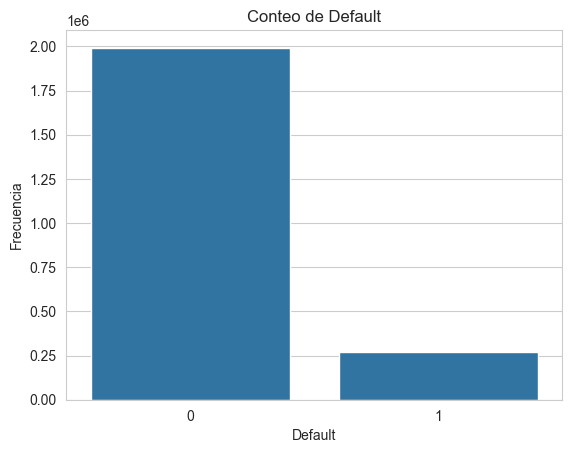

In [20]:
sns.set_style("whitegrid")
plt.title('Conteo de Default')
sns.countplot(x=df["default"])
plt.xlabel('Default')
plt.ylabel('Frecuencia')
plt.show()

Podemos observar que la distribucion de la variable default esta desbalanceada, esto se tomara en cuenta mas adelante

## Analisis y eliminacion de columnas con altos datos faltantes 

Se realiza la verificacion del procentaje de datos faltantes

In [21]:
missing_percentage = df.isna().mean() * 100
print(missing_percentage.to_string())

id                                              0.000000
member_id                                     100.000000
loan_amnt                                       0.001460
funded_amnt                                     0.001460
funded_amnt_inv                                 0.001460
term                                            0.000000
int_rate                                        0.001460
installment                                     0.001460
grade                                           0.000000
sub_grade                                       0.000000
emp_title                                       0.000000
emp_length                                      0.000000
home_ownership                                  0.000000
annual_inc                                      0.001637
verification_status                             0.000000
issue_d                                         0.001460
loan_status                                     0.000000
pymnt_plan                     

Se elimina la variable member_id porque tiene 100% de faltantes 

In [22]:
df=df.drop(columns="member_id")

En cuanto al resto de variables con datos faltantes a pesar de que tienen un porcentaje muy alto algunas de ellas tienen sus NA relacionados a otras variables por lo que no podemos hacer una eliminacion directa en cuanto a ellas. Entonces como se va a realizar un modelo se van a eliminar las variables con alto porcentaje que no sean de importancia para el analisis de la variable objetivo para facilitar la construccion del X final

Se van a eliminar las variables Hardship y settlement del dataset debido a que reflejan decisiones que se tomaron despues de la prediccion que se va a realizar en el modelo lo cual puede introducir data leakage 

In [23]:
cols_to_drop = [
    #variables tipo texto que no se pueden graficar o variables constantes 
    "url","desc","policy_code","emp_title",
    # Fechas post-origen
    "hardship_start_date", "hardship_end_date", "payment_plan_start_date",
    "debt_settlement_flag_date", "settlement_date",

    # Hardship
    "hardship_flag", "hardship_type", "hardship_reason", "hardship_status",
    "hardship_amount", "hardship_length", "hardship_dpd", "hardship_loan_status",
    "hardship_payoff_balance_amount", "hardship_last_payment_amount", "orig_projected_additional_accrued_interest","deferral_term",

    # Settlement
    "debt_settlement_flag", "settlement_status", "settlement_amount",
    "settlement_percentage", "settlement_term",
    # Variables del co-aplicante
    "annual_inc_joint", "dti_joint", "verification_status_joint",
    "revol_bal_joint", "sec_app_fico_range_low", "sec_app_fico_range_high",
    "sec_app_earliest_cr_line", "sec_app_inq_last_6mths", "sec_app_mort_acc",
    "sec_app_open_acc", "sec_app_revol_util", "sec_app_open_act_il",
    "sec_app_num_rev_accts", "sec_app_chargeoff_within_12_mths",
    "sec_app_collections_12_mths_ex_med", "sec_app_mths_since_last_major_derog",
    # Variables con informacion despues del prestamo
    "out_prncp","out_prncp_inv","total_pymnt","total_pymnt_inv",
    "total_rec_prncp","total_rec_int","total_rec_late_fee",
    "recoveries","collection_recovery_fee","last_pymnt_d",
    "last_pymnt_amnt","next_pymnt_d","last_credit_pull_d",
    "last_fico_range_high","last_fico_range_low"
]
df_actualizado=df.drop(columns=cols_to_drop)

In [24]:
df_actualizado.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,...,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,default
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,...,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,0
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,...,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,0
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,...,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash,0
3,66310712,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,10+ years,...,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,Cash,0
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,...,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,Cash,0


A partir de este dataset revisamos nuevamente los faltantes que tenemos y eliminamos los que tengan mas de 50%

In [25]:
Porcentaje_NA= df_actualizado.isna().mean() * 100
print(Porcentaje_NA.to_string())

id                                 0.000000
loan_amnt                          0.001460
funded_amnt                        0.001460
funded_amnt_inv                    0.001460
term                               0.000000
int_rate                           0.001460
installment                        0.001460
grade                              0.000000
sub_grade                          0.000000
emp_length                         0.000000
home_ownership                     0.000000
annual_inc                         0.001637
verification_status                0.000000
issue_d                            0.001460
loan_status                        0.000000
pymnt_plan                         0.000000
purpose                            0.000000
title                              0.000000
zip_code                           0.000000
addr_state                         0.000000
dti                                0.077144
delinq_2yrs                        0.002743
earliest_cr_line                

eliminamos las variables restantes con mas de 50% de NA 

In [26]:
umbral=50 

In [27]:
df_actualizado = df_actualizado.loc[:, Porcentaje_NA <= umbral]

In [28]:
df_actualizado.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,...,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,default
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,...,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,0
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,...,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,0
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,...,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash,0
3,66310712,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,10+ years,...,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,Cash,0
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,...,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,Cash,0


Con este dataset reducido haremos las visualizaciones de las variables 

## Analisis grafico de las variables 

Se realizan las visualizaciones de las variables del dataset reducido 

Se realizan visualizaciones de las variables categoricas 

In [29]:
cat=['term','grade','sub_grade','emp_length','purpose','home_ownership','verification_status','pymnt_plan','addr_state','initial_list_status','disbursement_method']

In [30]:
for col in cat:
    df_actualizado[col] = df_actualizado[col].astype(str).str.strip()          
    df_actualizado[col] = df_actualizado[col].replace("nan", np.nan)           
for col in cat:
    print(f"{col}: {df_actualizado[col].isna().sum()} NaN")

term: 33 NaN
grade: 33 NaN
sub_grade: 33 NaN
emp_length: 146940 NaN
purpose: 33 NaN
home_ownership: 33 NaN
verification_status: 33 NaN
pymnt_plan: 33 NaN
addr_state: 33 NaN
initial_list_status: 33 NaN
disbursement_method: 33 NaN


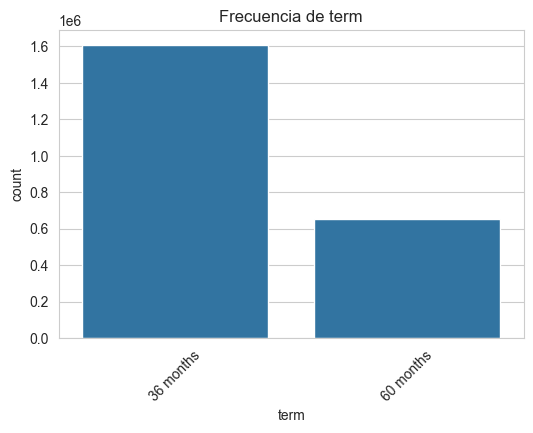

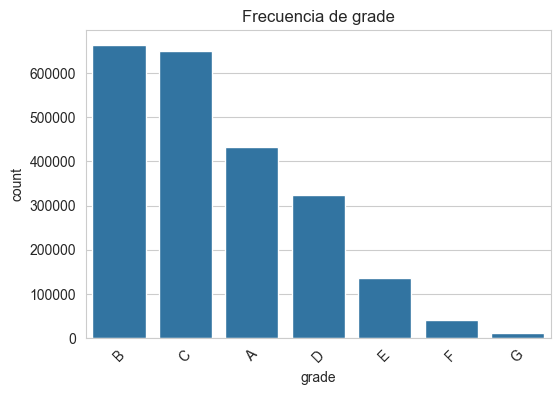

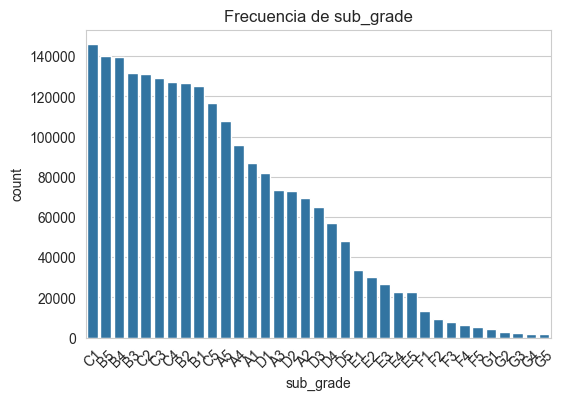

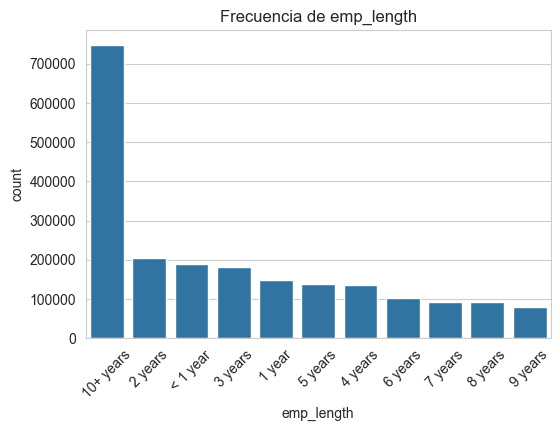

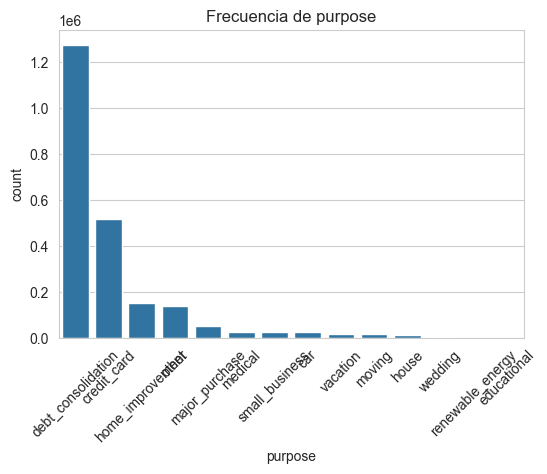

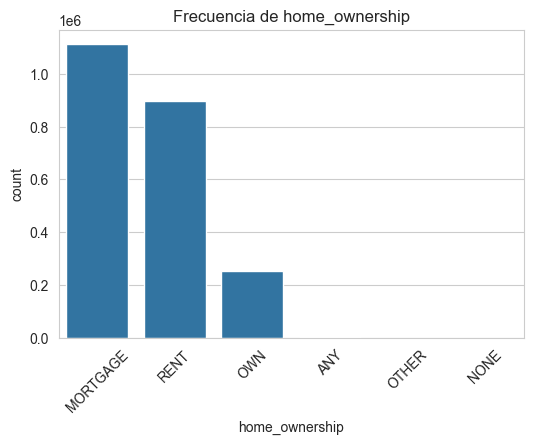

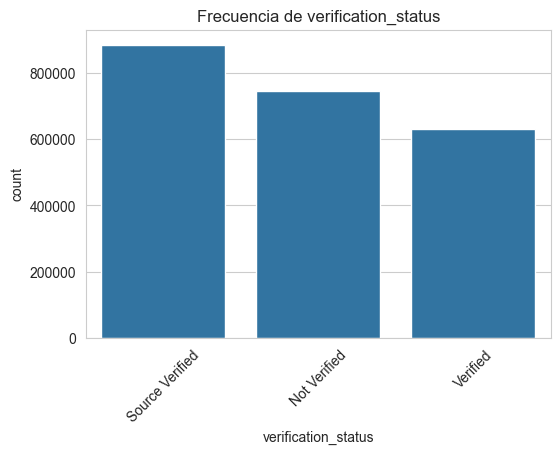

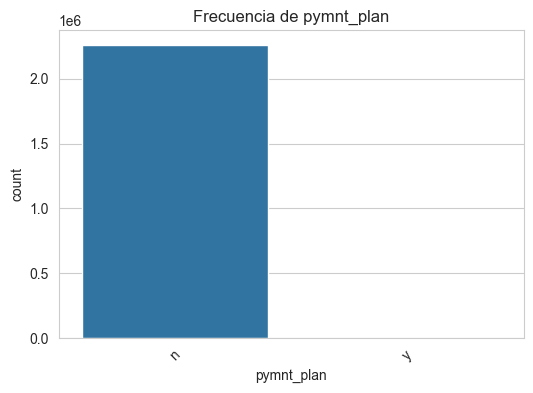

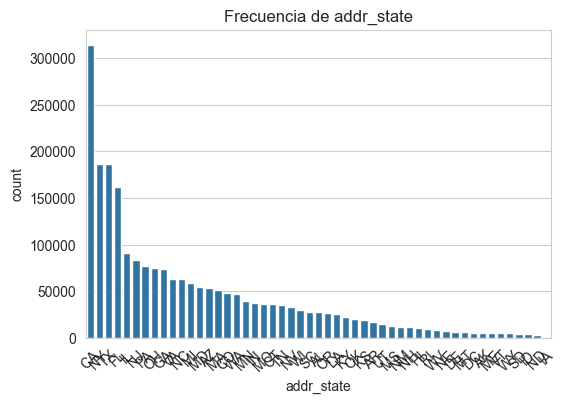

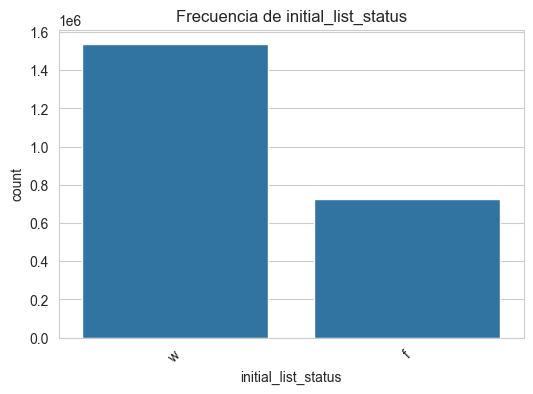

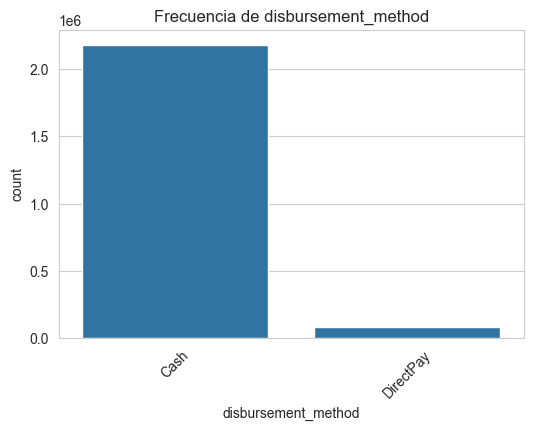

In [31]:
for col in cat:  
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_actualizado, x=col, order=df_actualizado[col].value_counts().index)  
    plt.title(f"Frecuencia de {col}")
    plt.xticks(rotation=45)
    plt.show()

Podemos observar que la mayoria de variables tienen una categoria para los NA que se imputara en la parte de preprocesamiento 

Realizamos los graficos de las variables numericas 

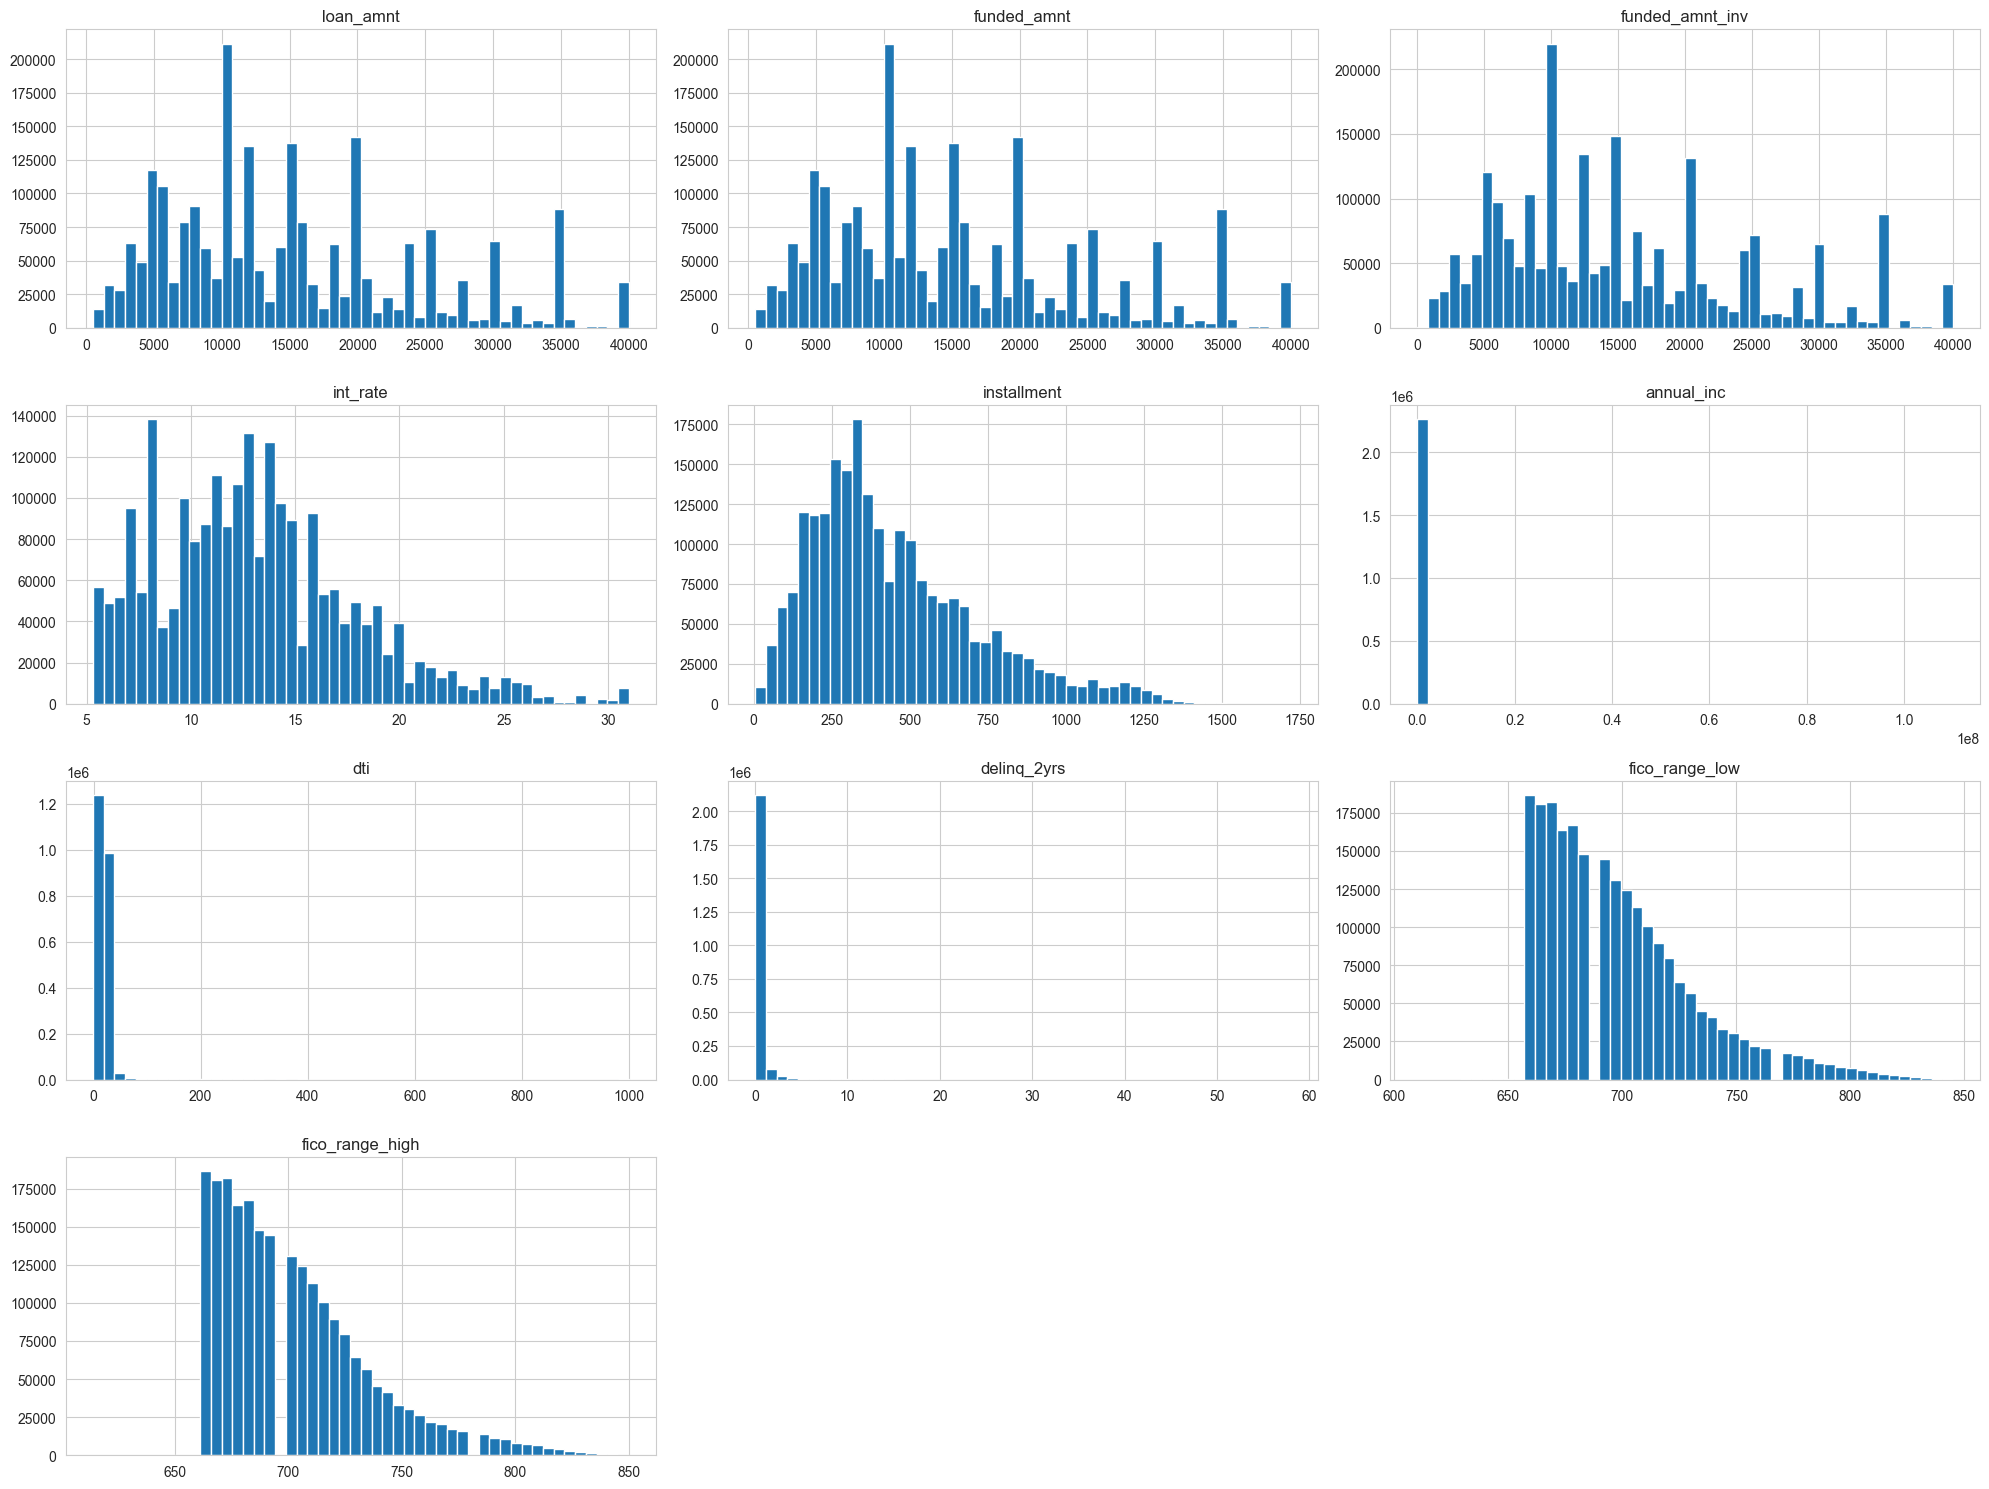

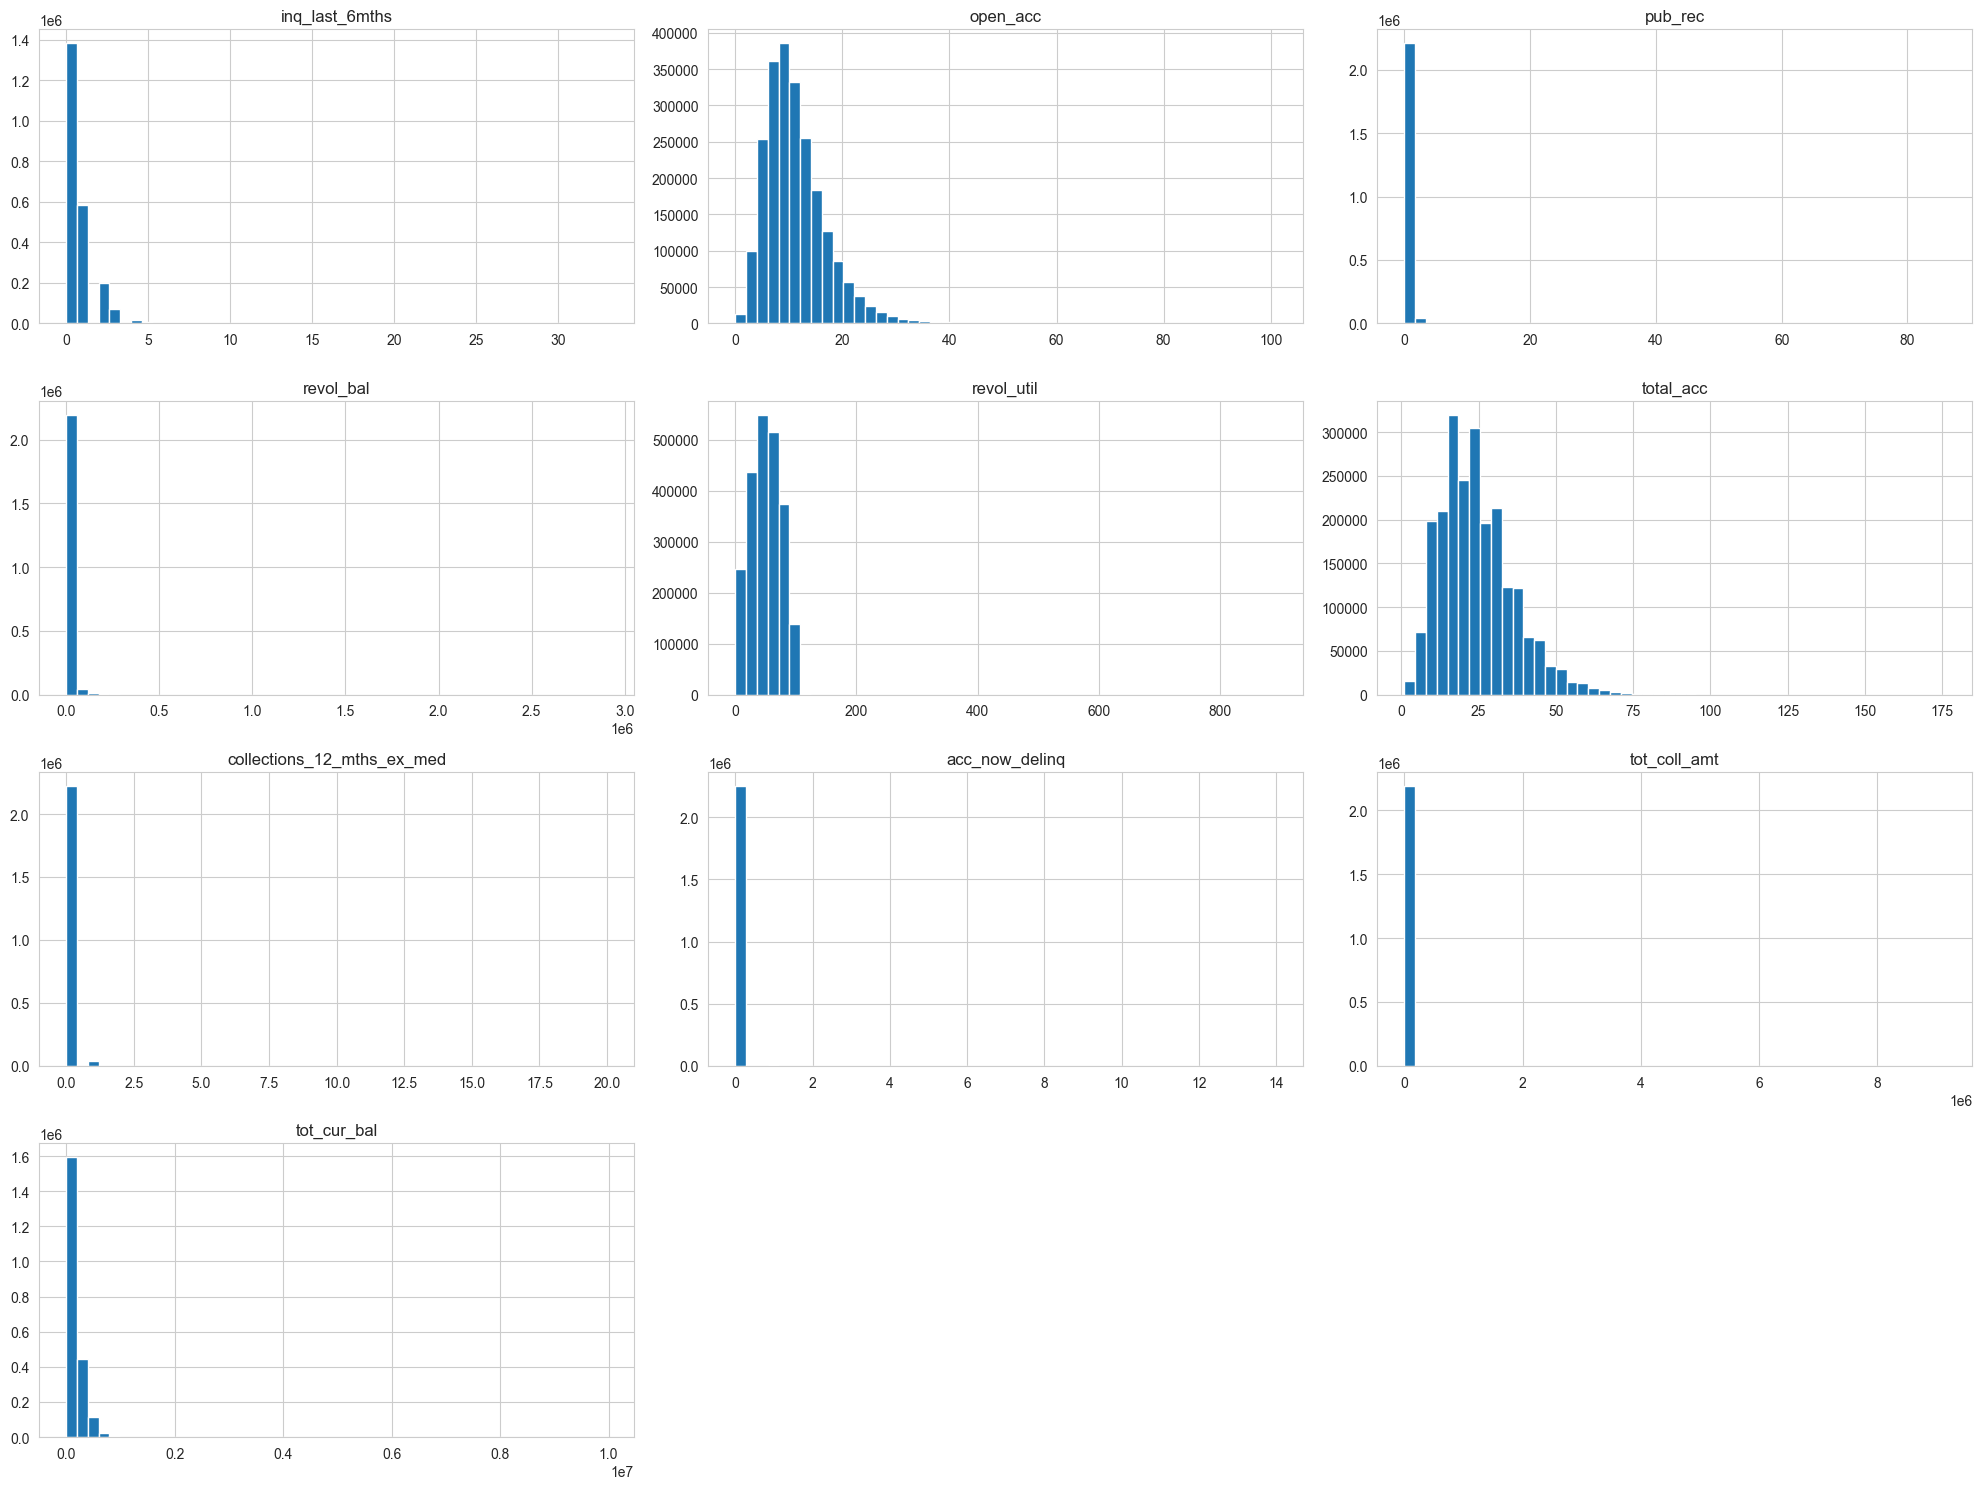

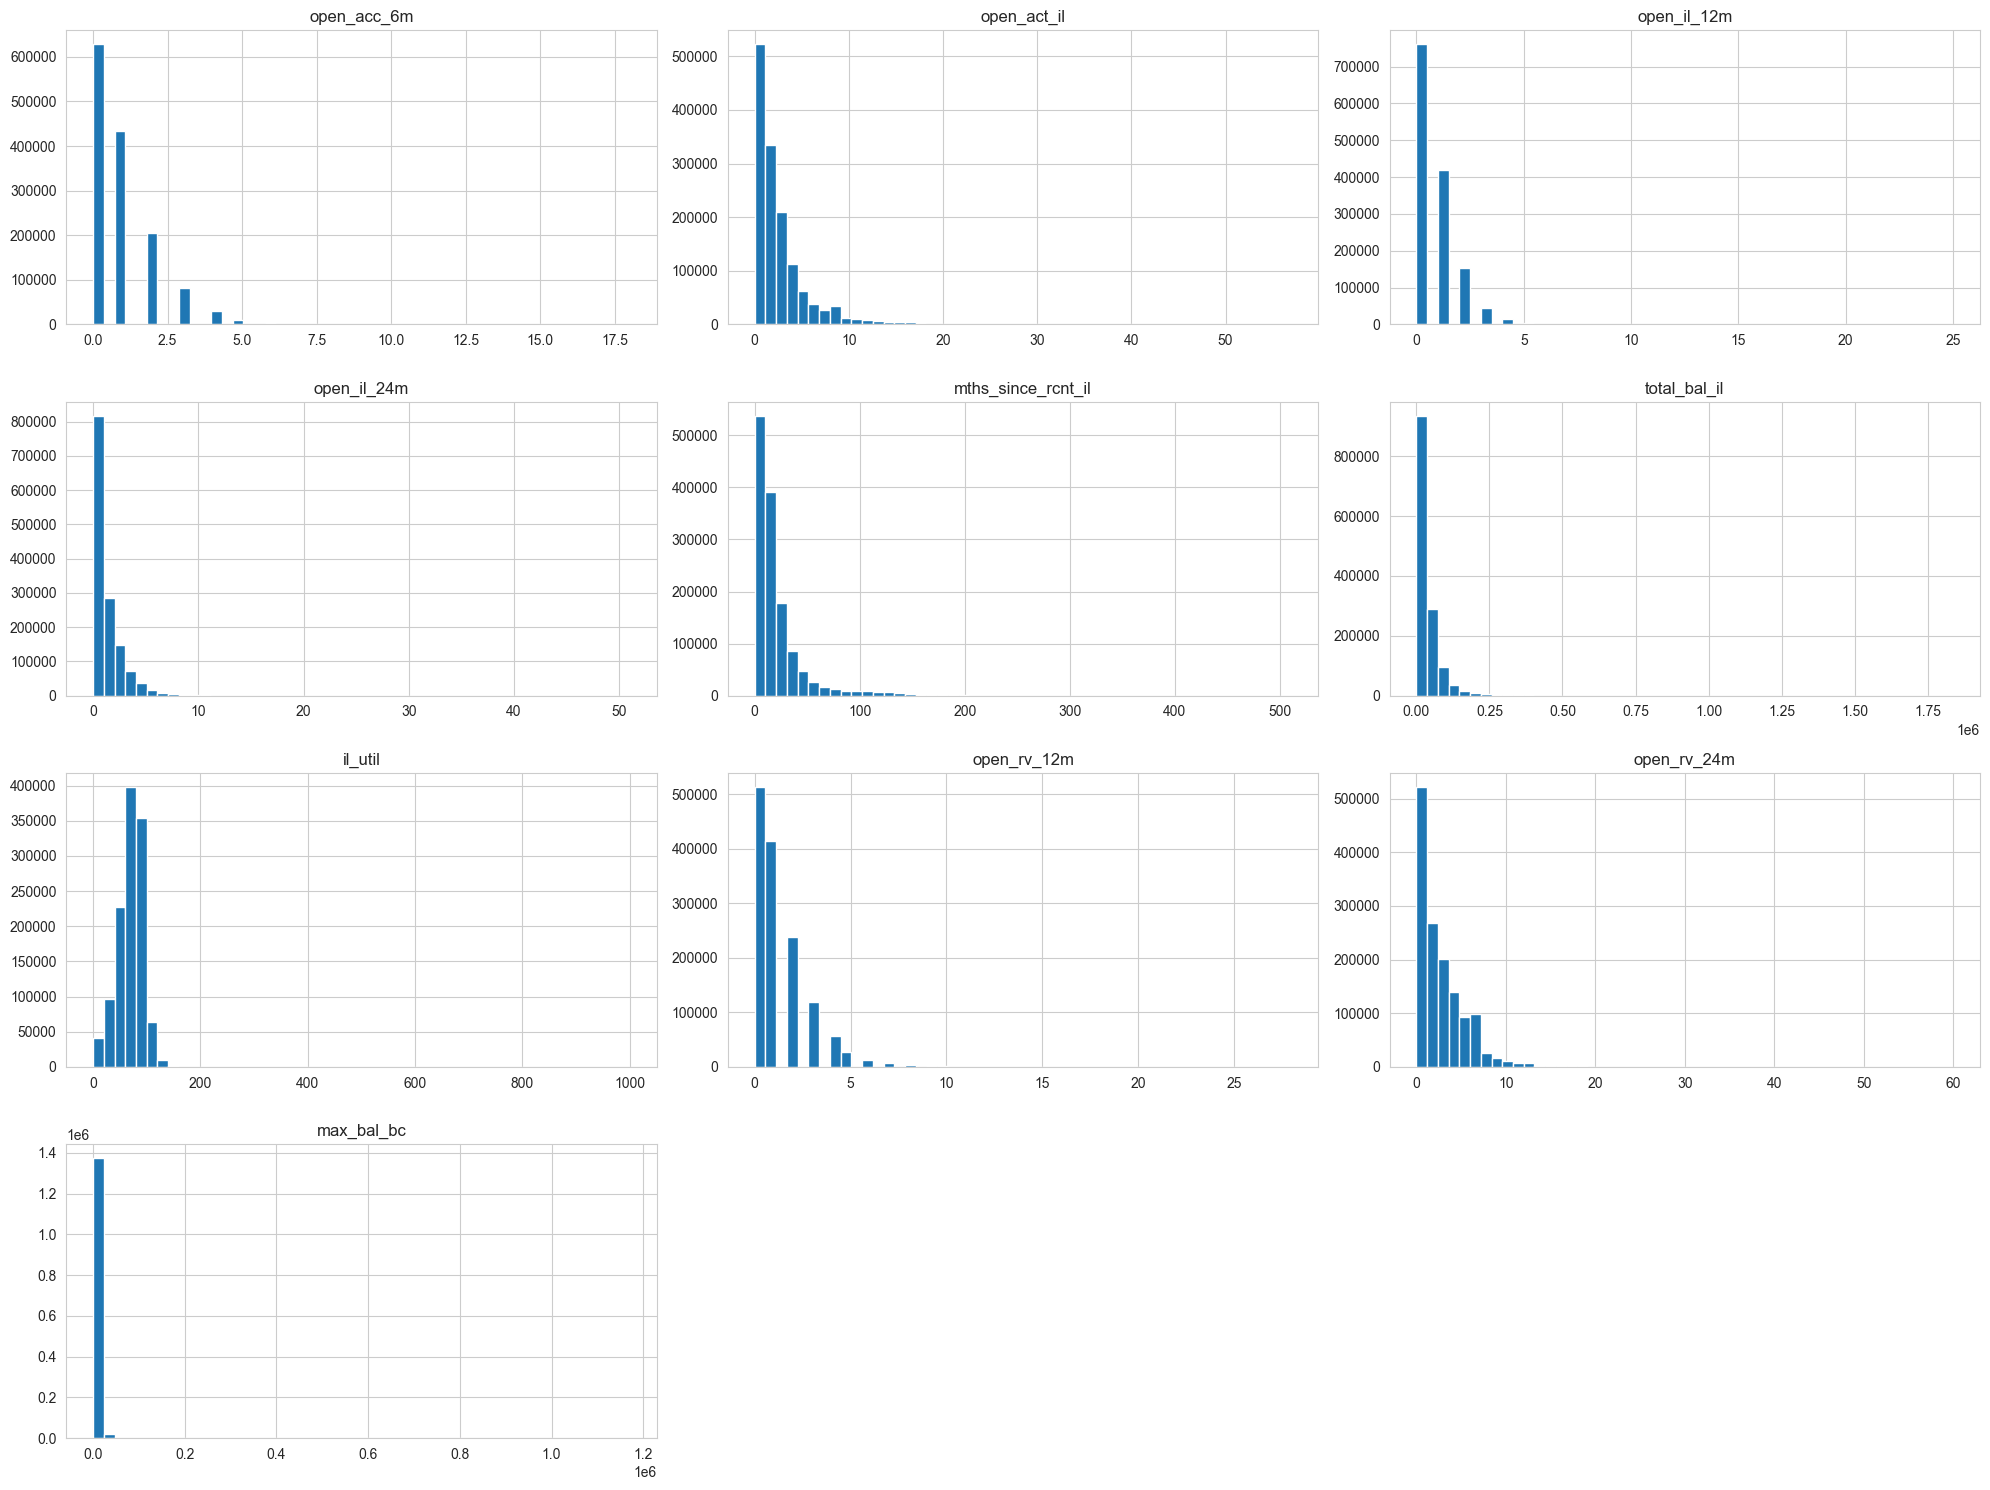

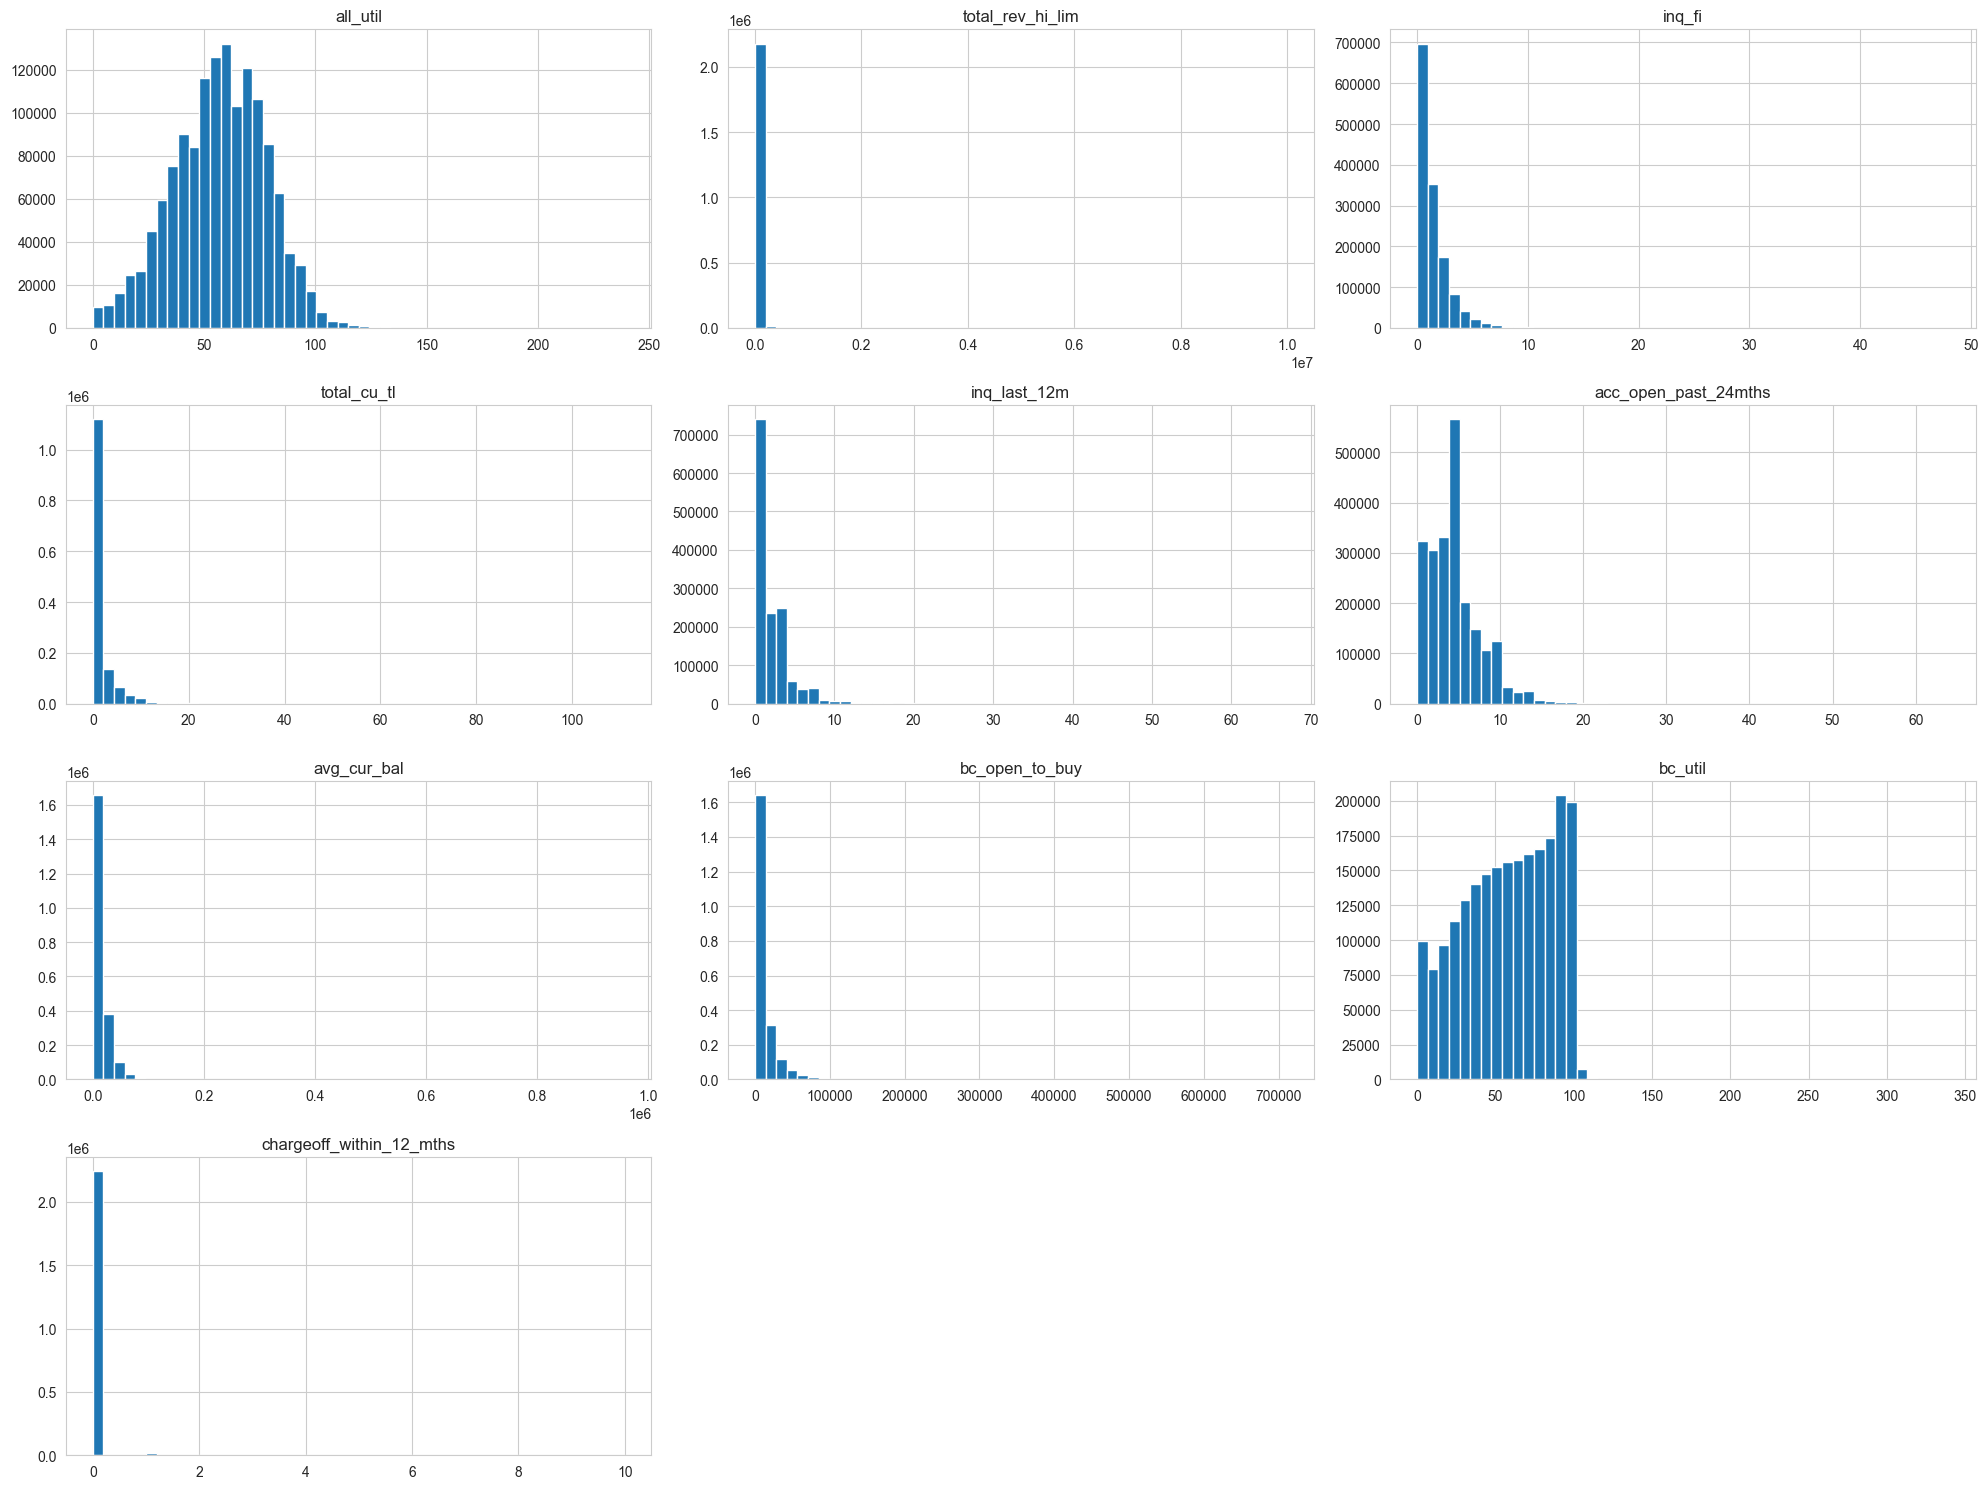

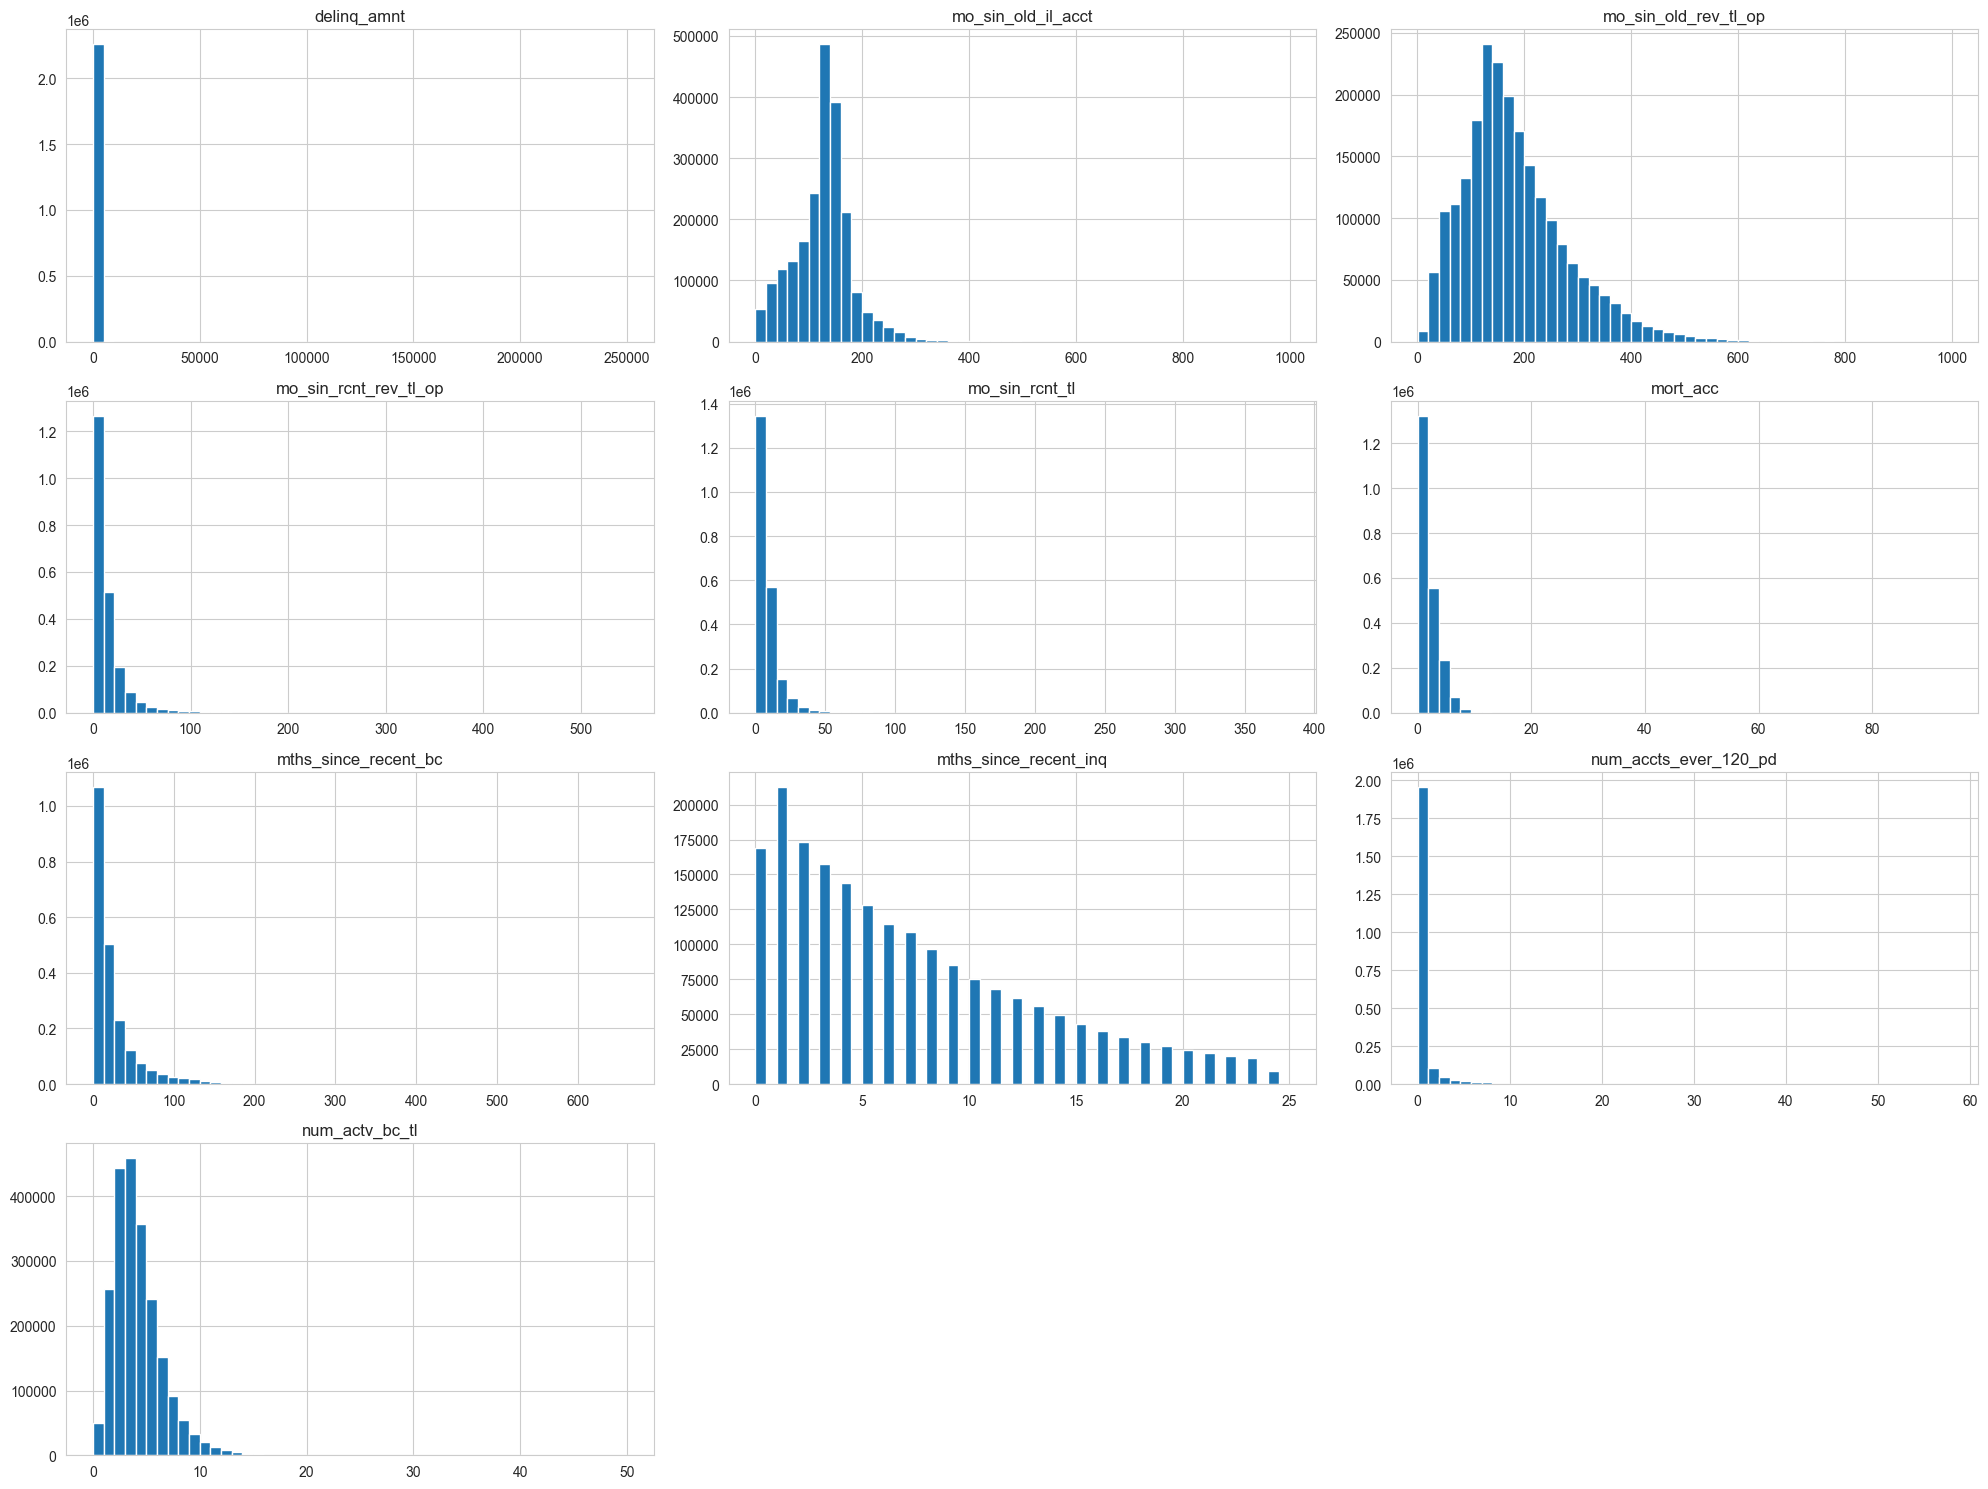

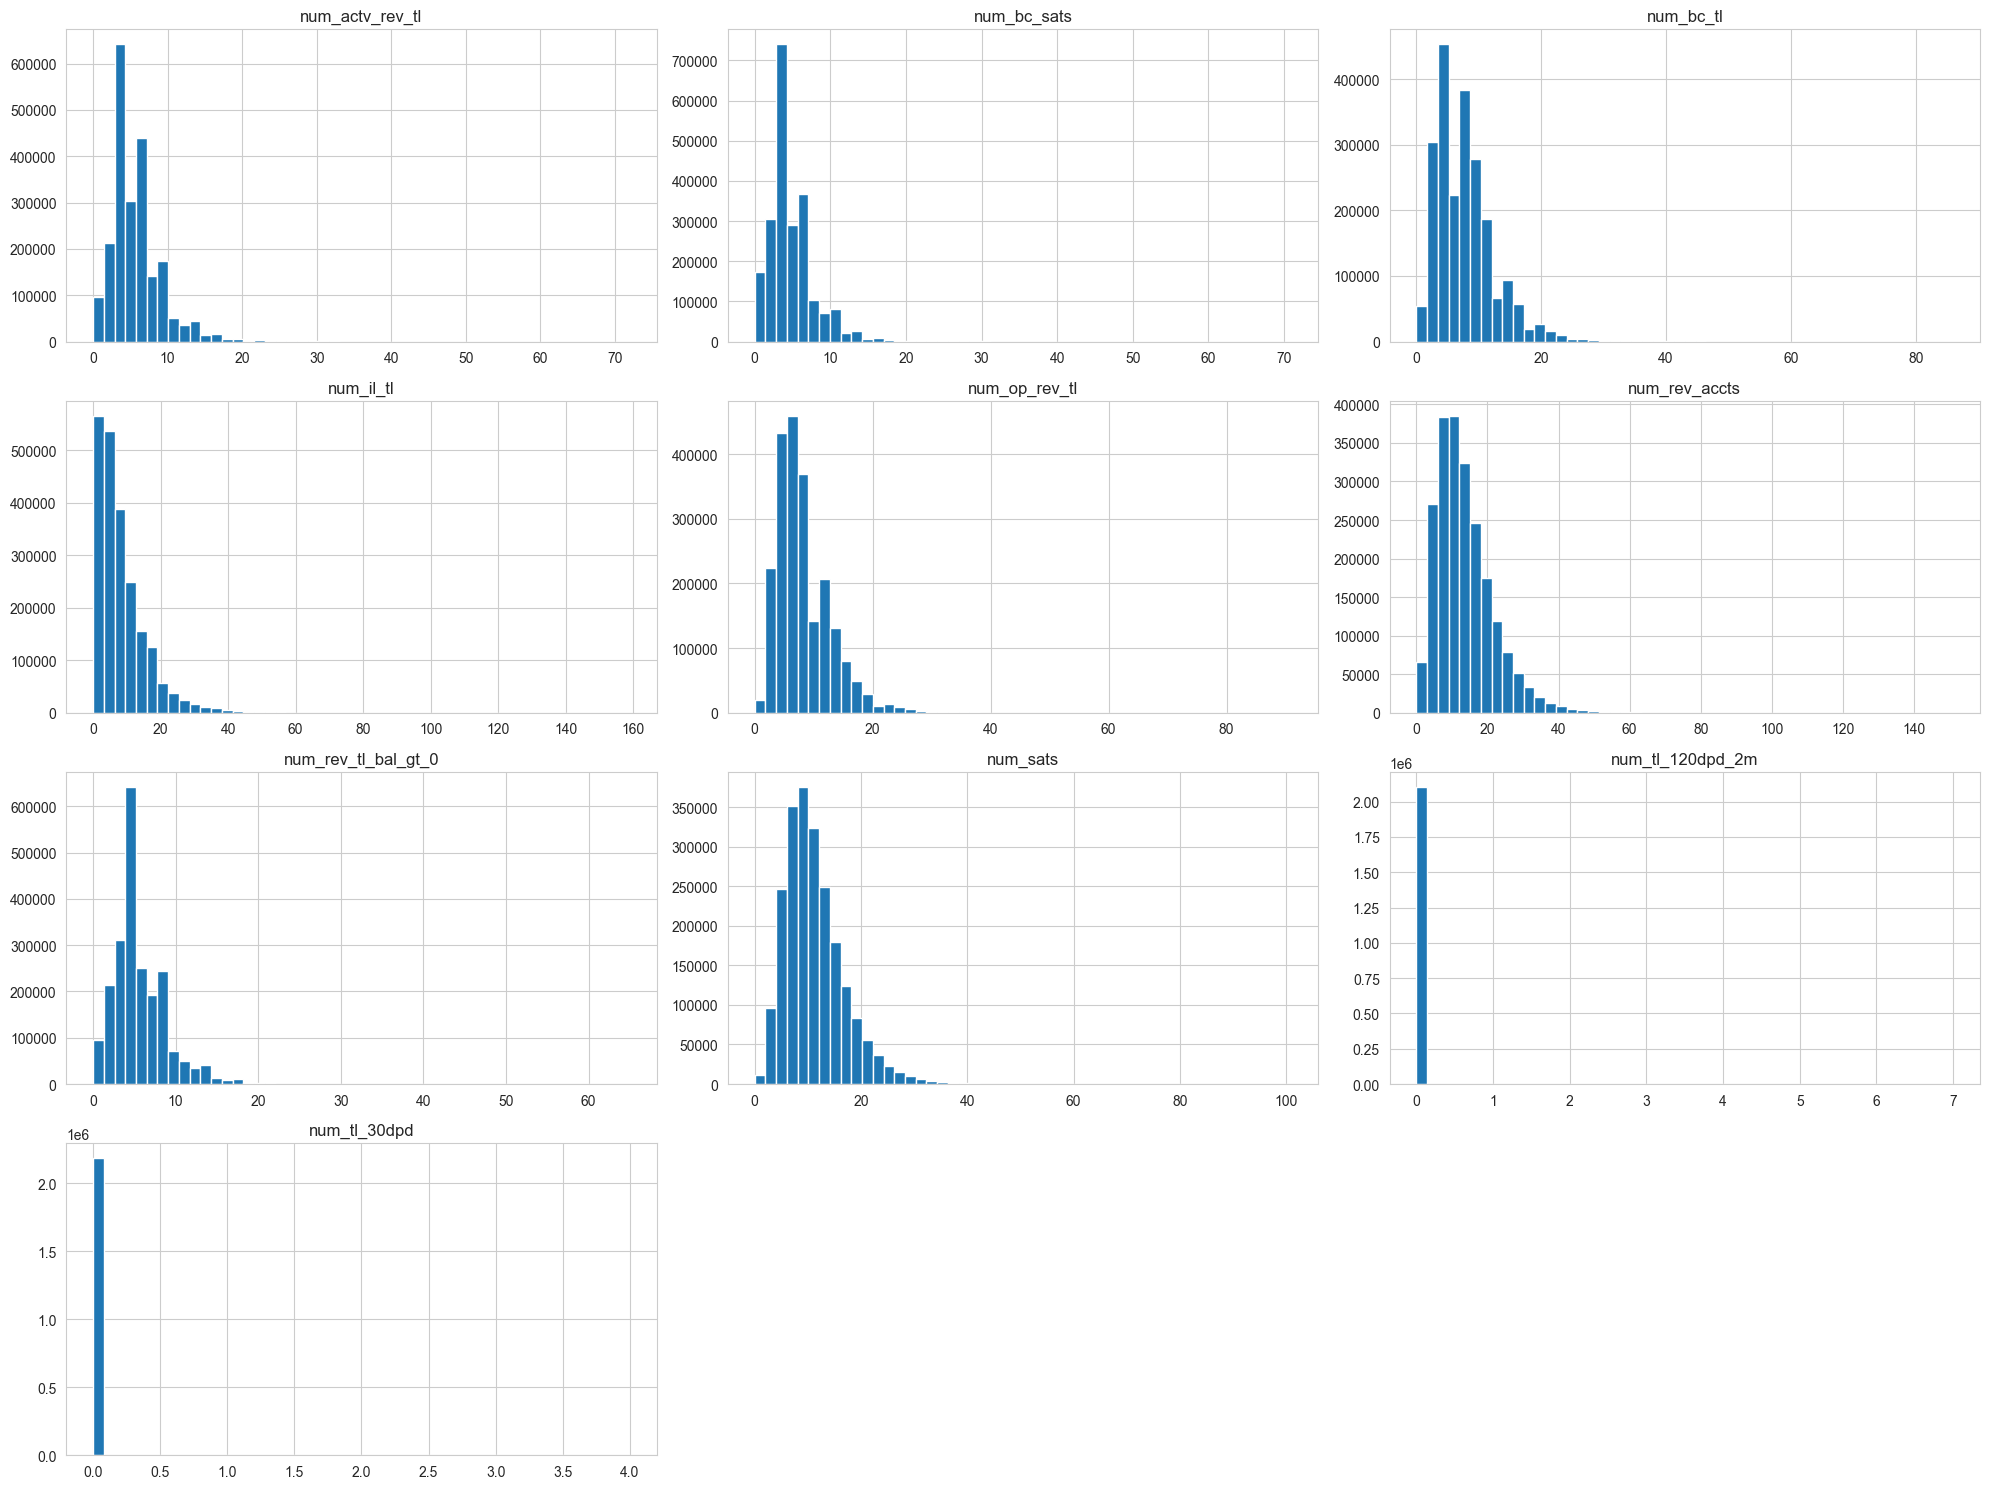

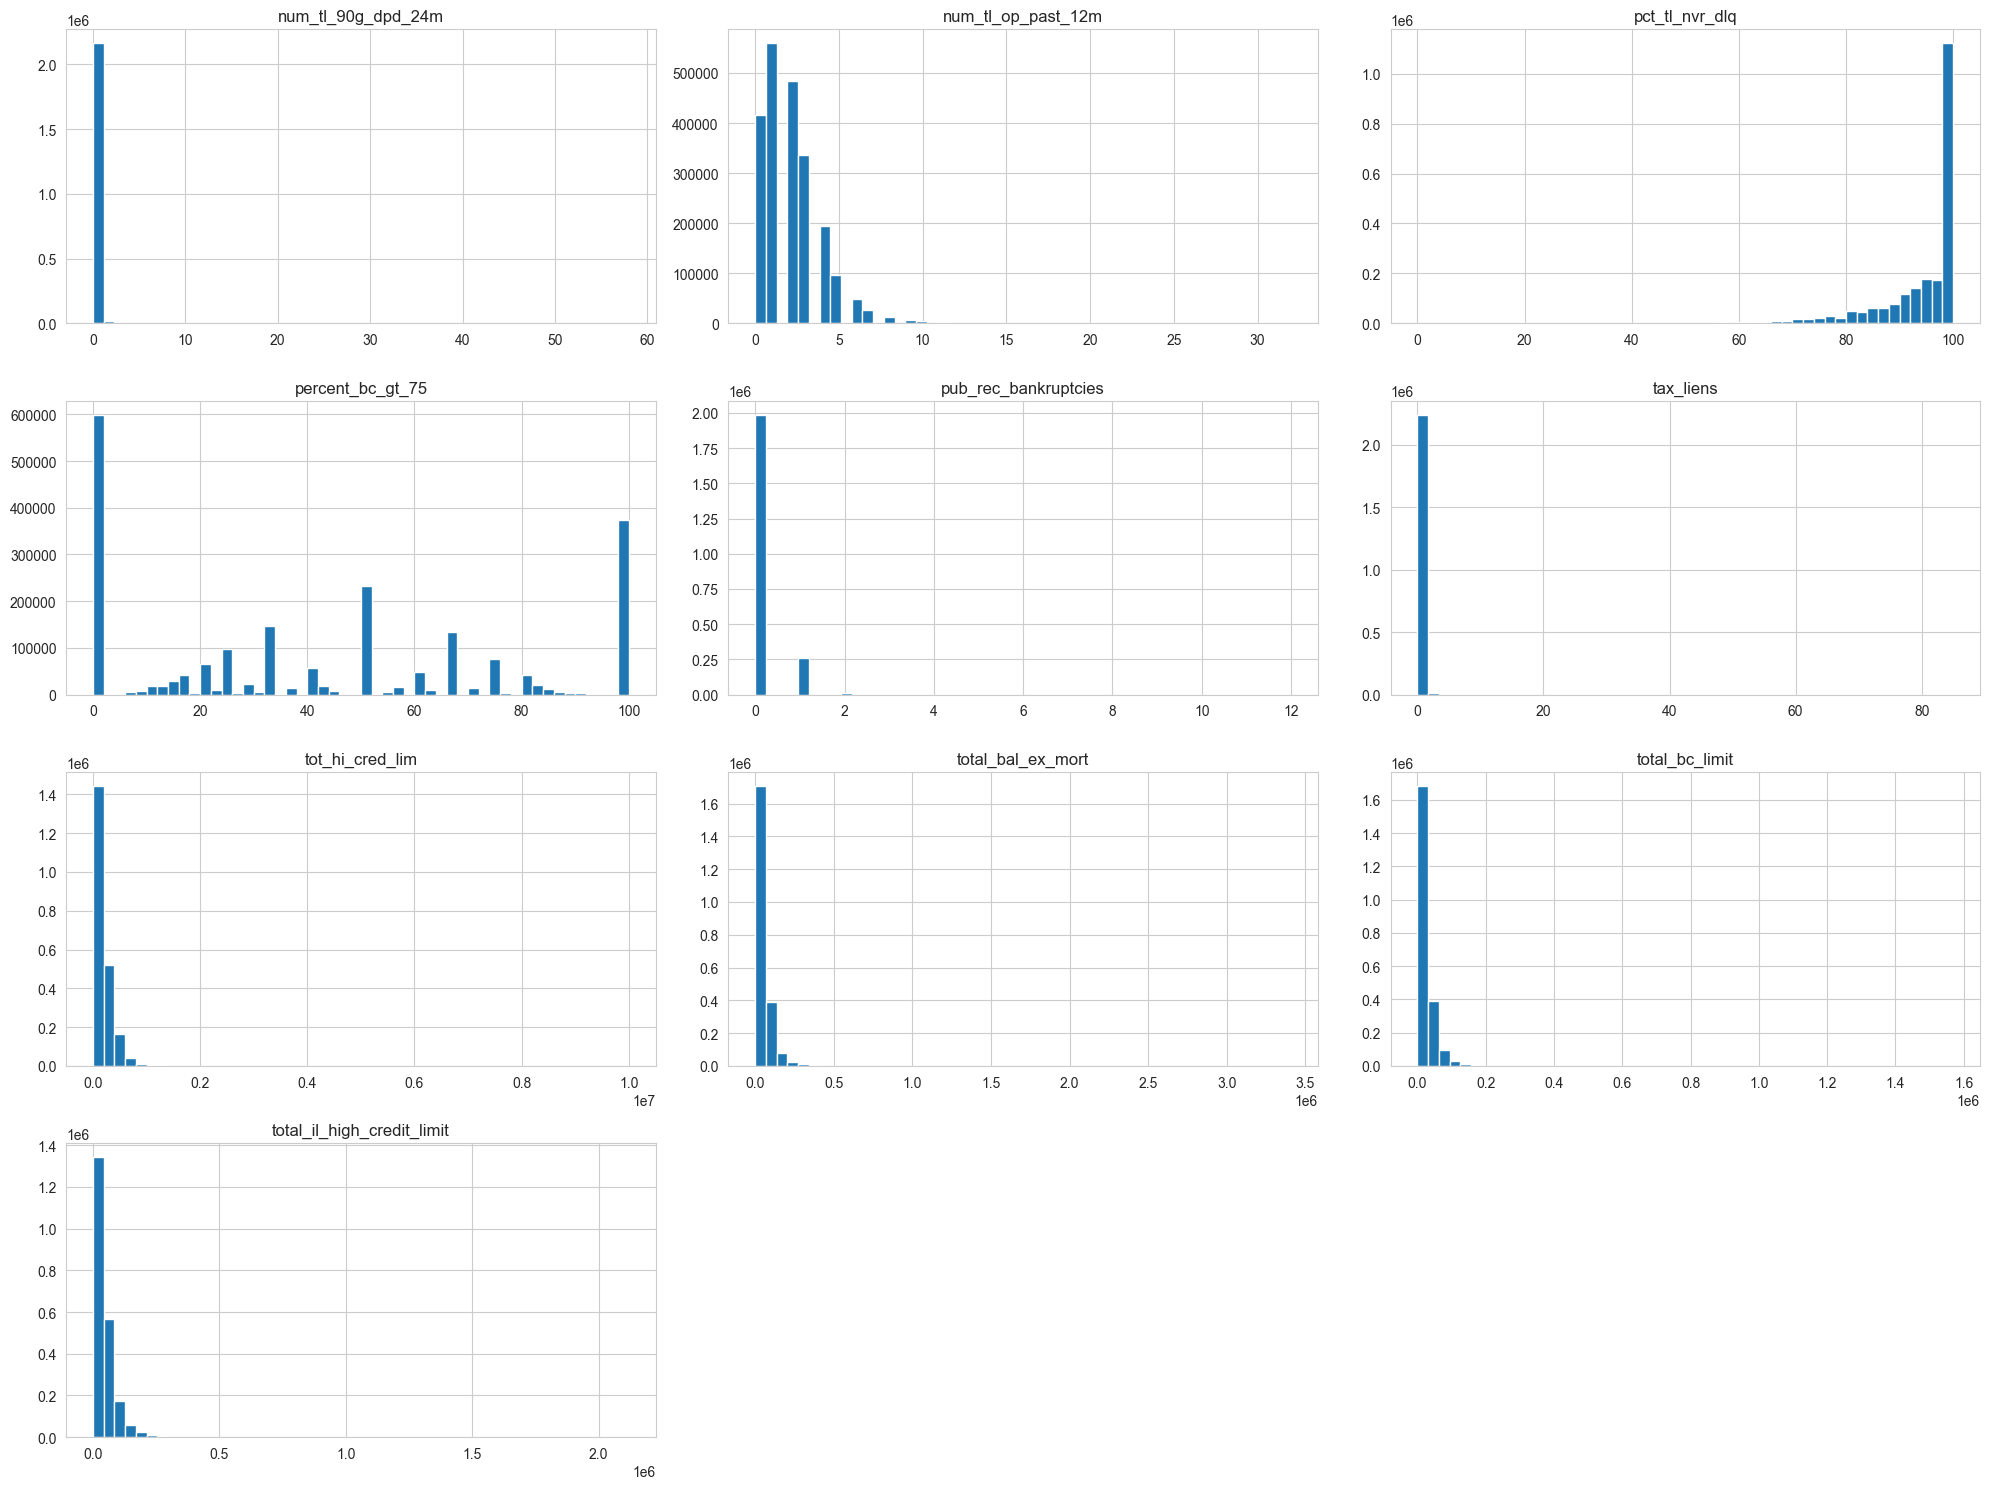

In [32]:
num_vars = df_actualizado.select_dtypes(include=["float64"]).columns
for i in range(0, len(num_vars), 10):
    df_actualizado[num_vars[i:i+10]].hist(figsize=(20,15), bins=50)
    plt.tight_layout()
    plt.show()

Podemos observar que algunas de las variables pueden tener presencia muy extrema de valores atipicos. debido a algunos de los limites en los que se encuentran y que tan lejos llegan los valores mas extremos de algunas de las variables.  

<Figure size 1000x600 with 0 Axes>

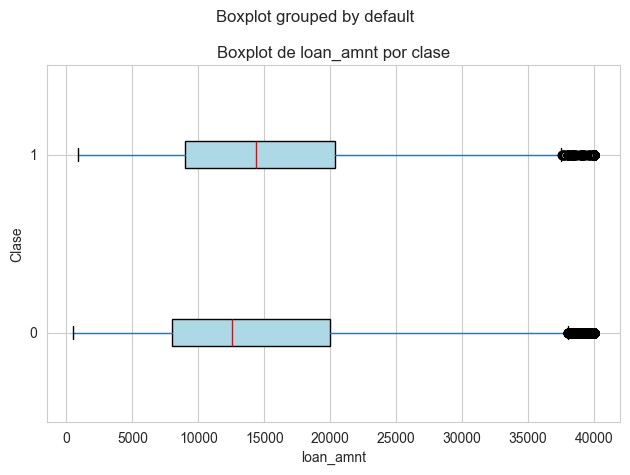

<Figure size 1000x600 with 0 Axes>

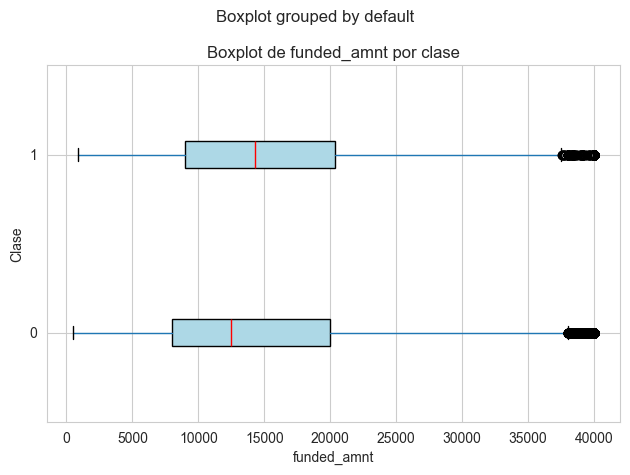

<Figure size 1000x600 with 0 Axes>

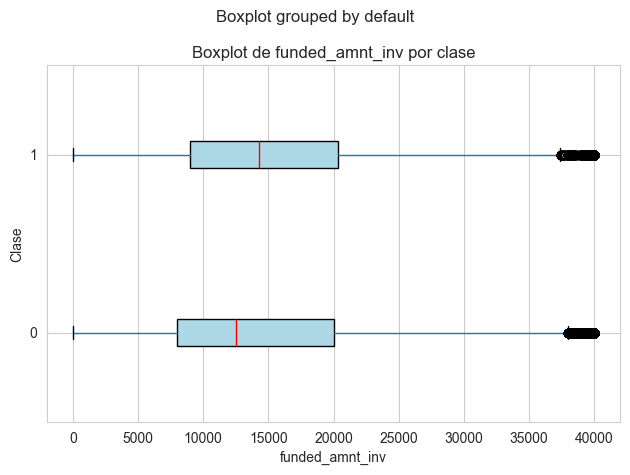

<Figure size 1000x600 with 0 Axes>

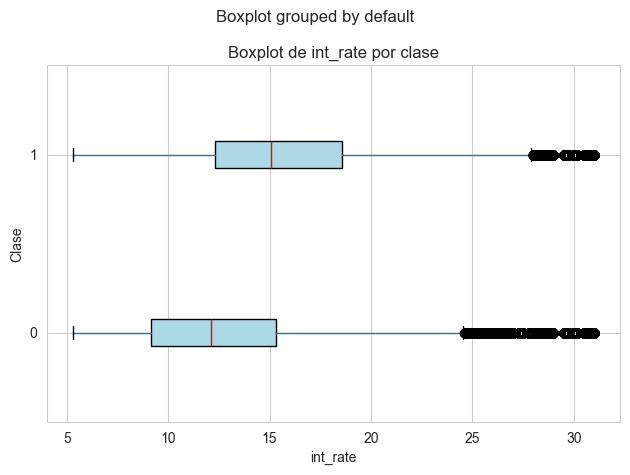

<Figure size 1000x600 with 0 Axes>

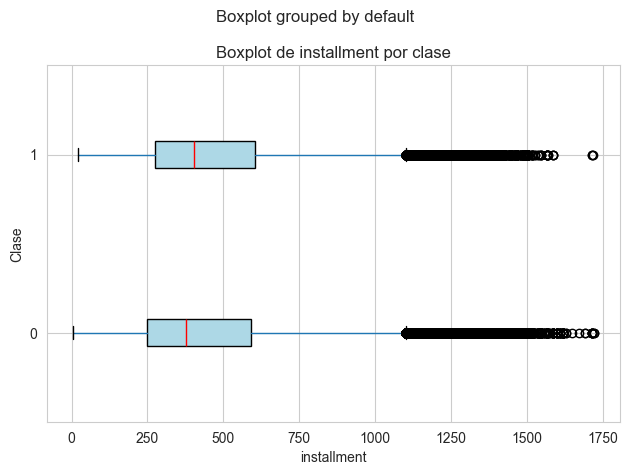

<Figure size 1000x600 with 0 Axes>

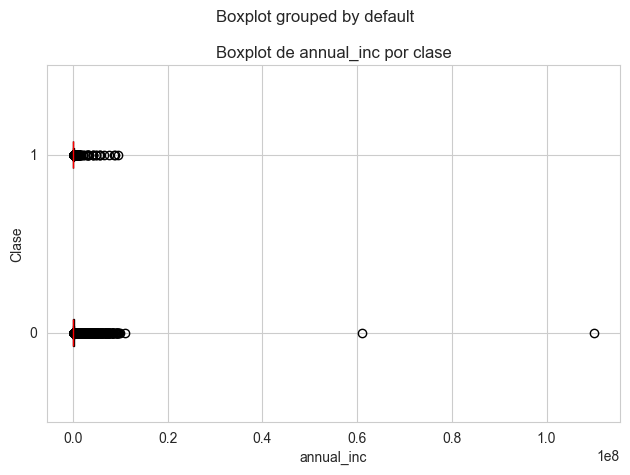

<Figure size 1000x600 with 0 Axes>

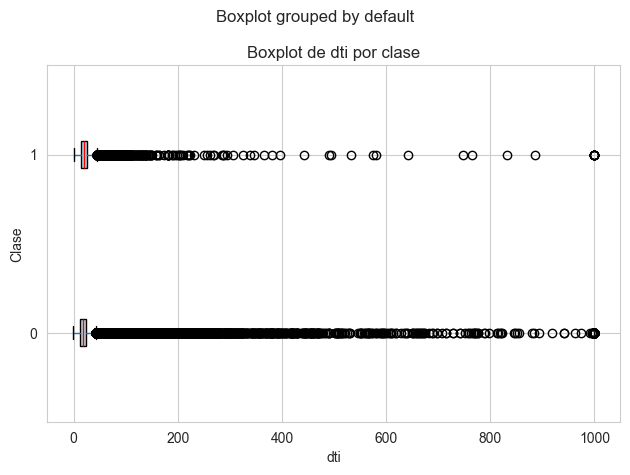

<Figure size 1000x600 with 0 Axes>

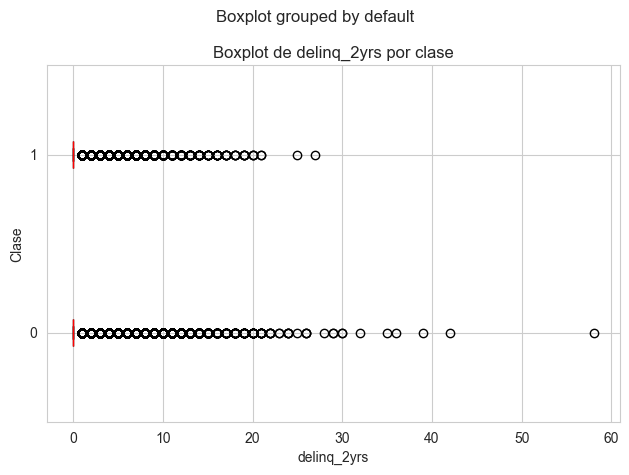

<Figure size 1000x600 with 0 Axes>

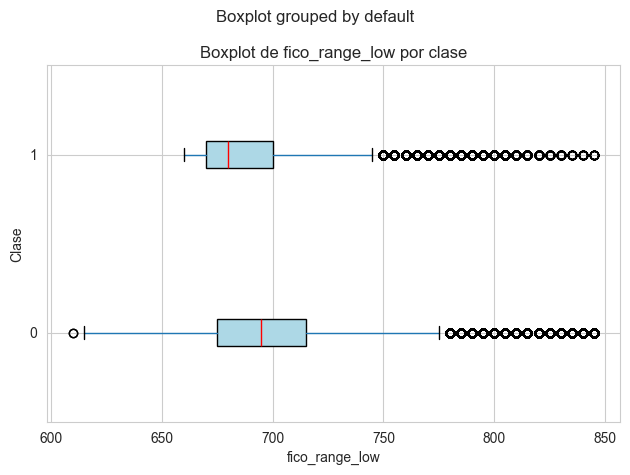

<Figure size 1000x600 with 0 Axes>

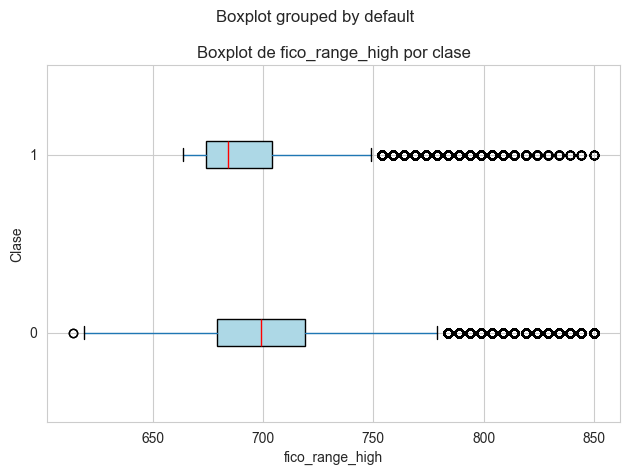

<Figure size 1000x600 with 0 Axes>

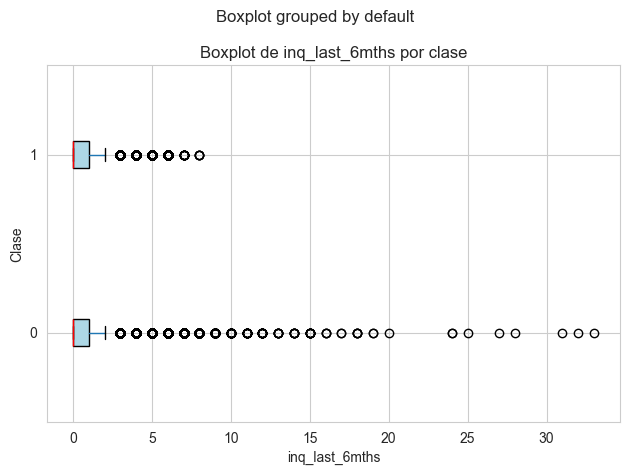

<Figure size 1000x600 with 0 Axes>

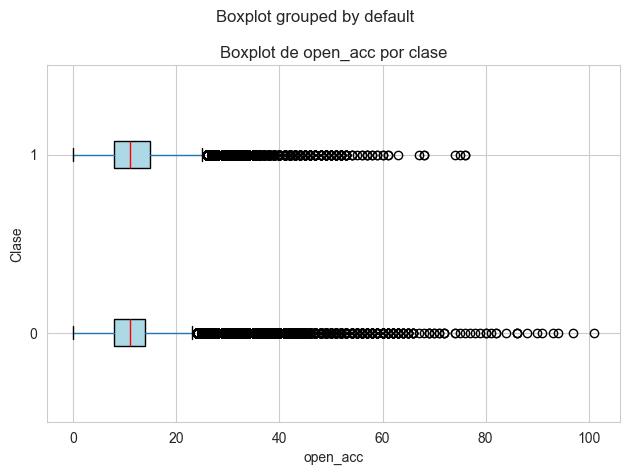

<Figure size 1000x600 with 0 Axes>

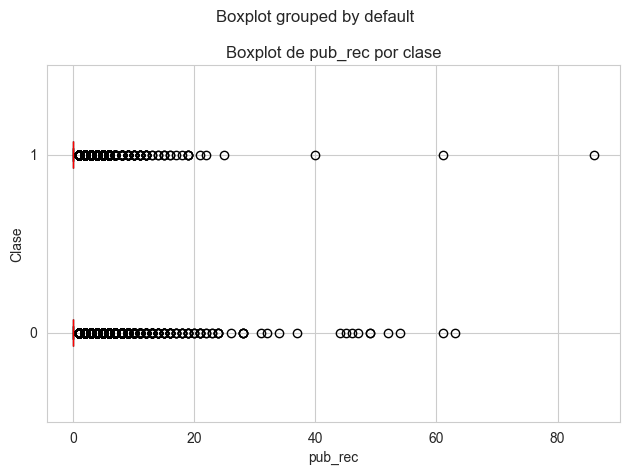

<Figure size 1000x600 with 0 Axes>

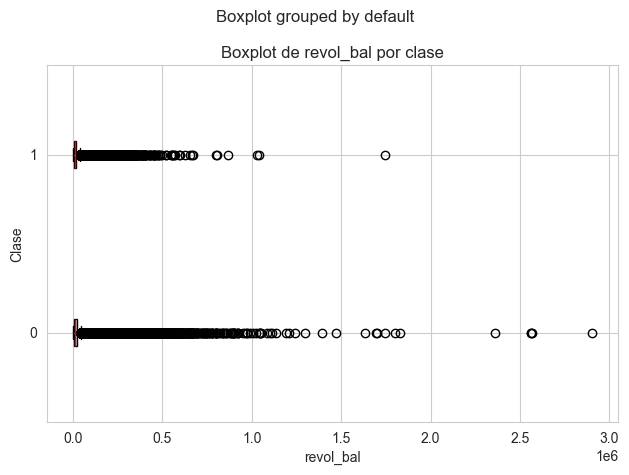

<Figure size 1000x600 with 0 Axes>

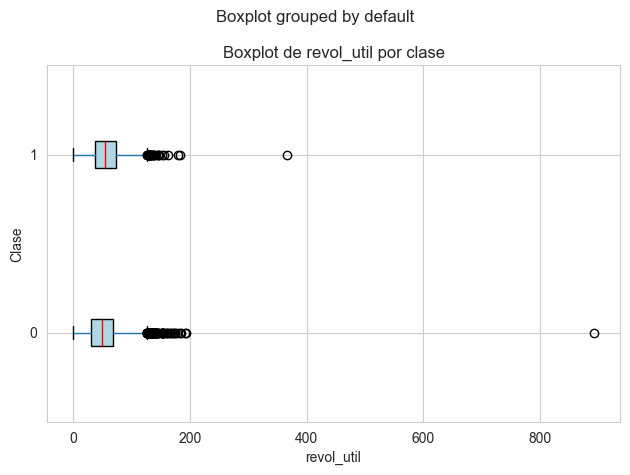

<Figure size 1000x600 with 0 Axes>

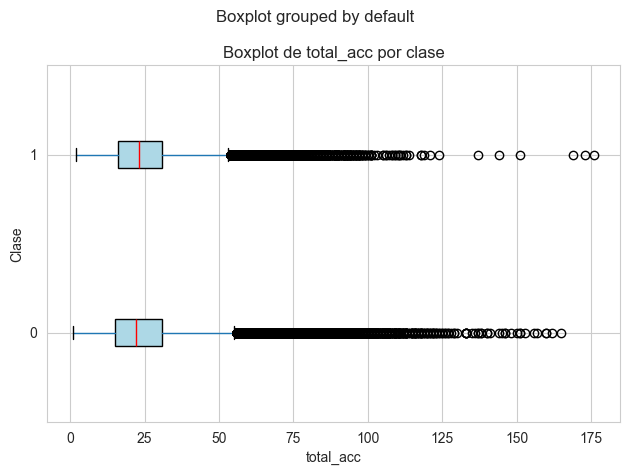

<Figure size 1000x600 with 0 Axes>

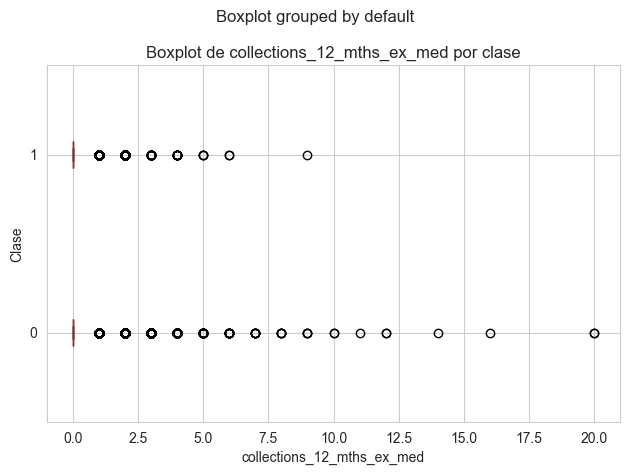

<Figure size 1000x600 with 0 Axes>

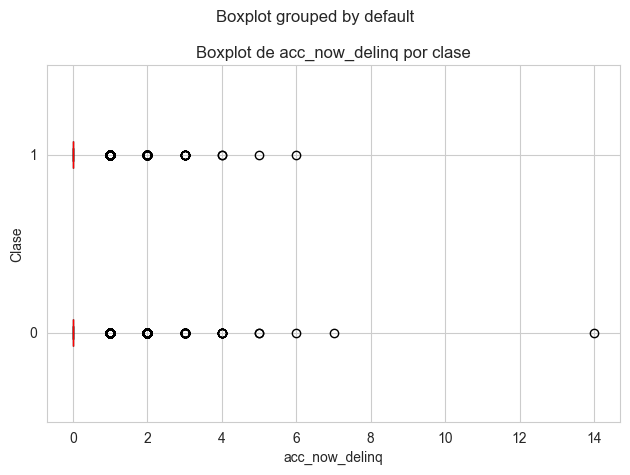

<Figure size 1000x600 with 0 Axes>

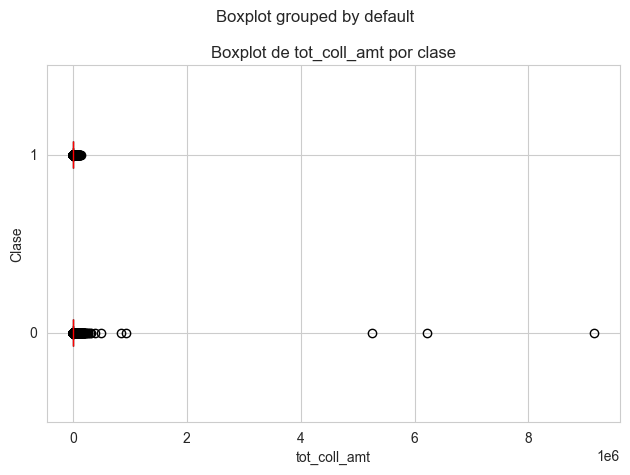

<Figure size 1000x600 with 0 Axes>

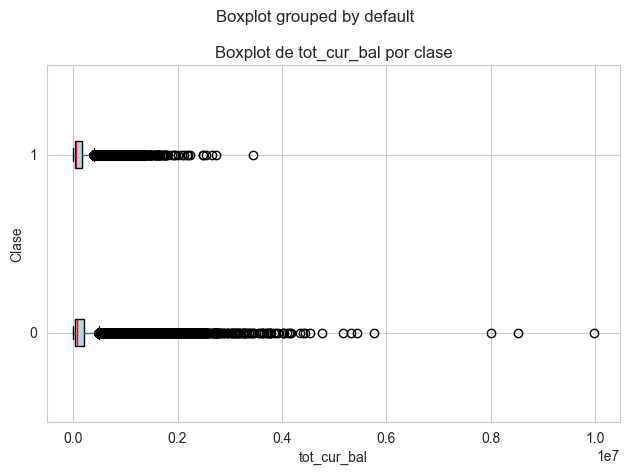

<Figure size 1000x600 with 0 Axes>

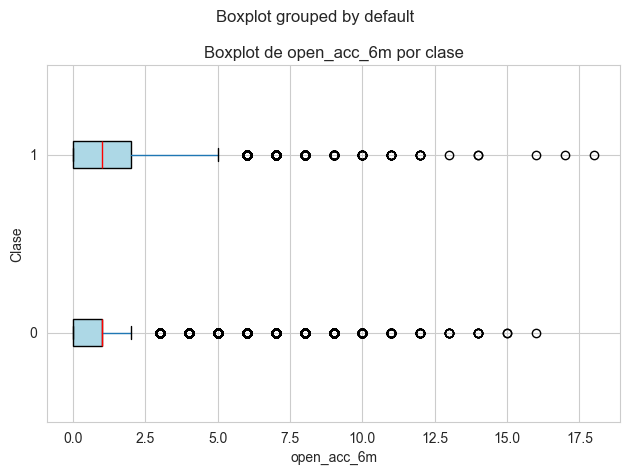

<Figure size 1000x600 with 0 Axes>

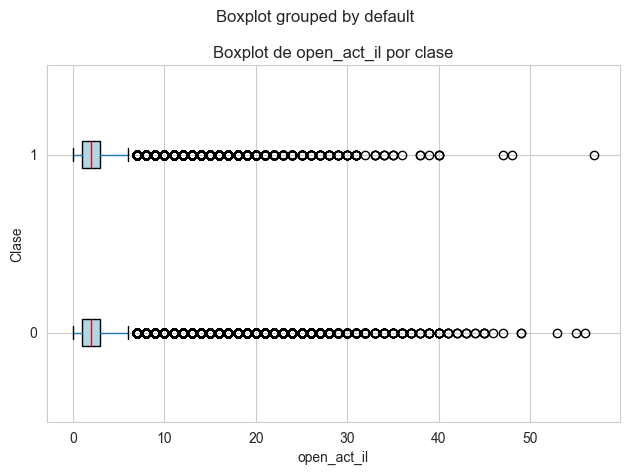

<Figure size 1000x600 with 0 Axes>

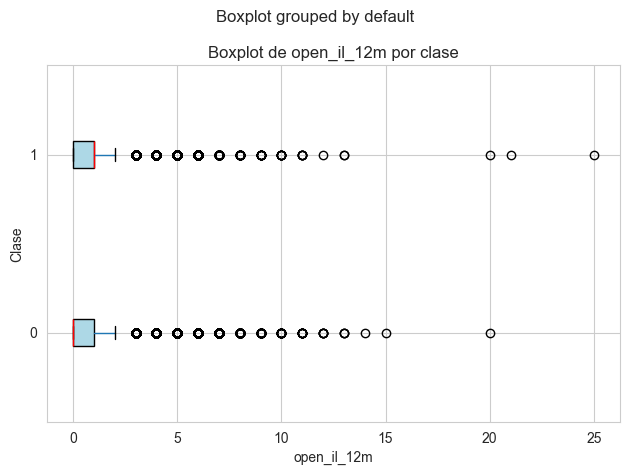

<Figure size 1000x600 with 0 Axes>

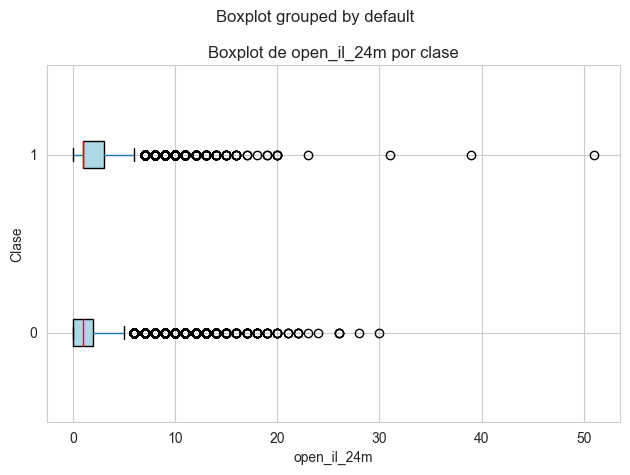

<Figure size 1000x600 with 0 Axes>

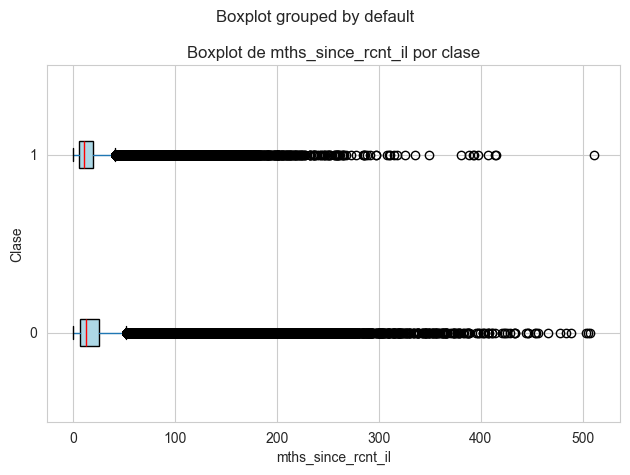

<Figure size 1000x600 with 0 Axes>

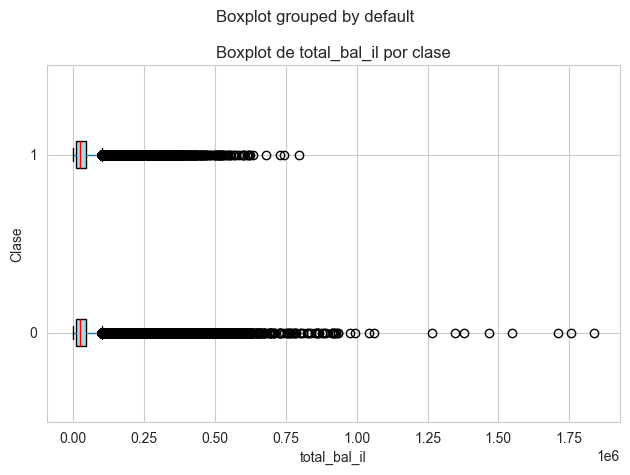

<Figure size 1000x600 with 0 Axes>

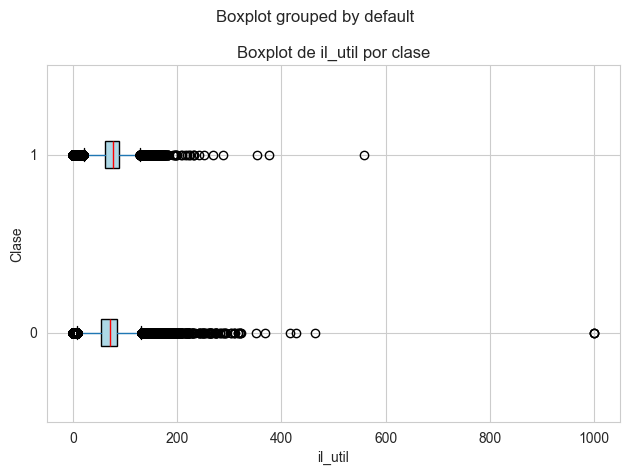

<Figure size 1000x600 with 0 Axes>

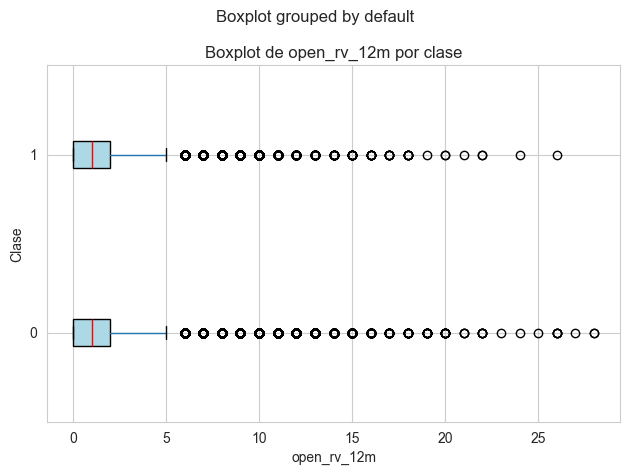

<Figure size 1000x600 with 0 Axes>

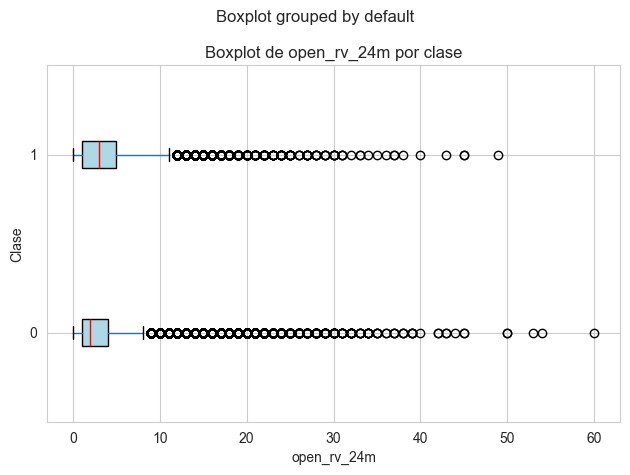

<Figure size 1000x600 with 0 Axes>

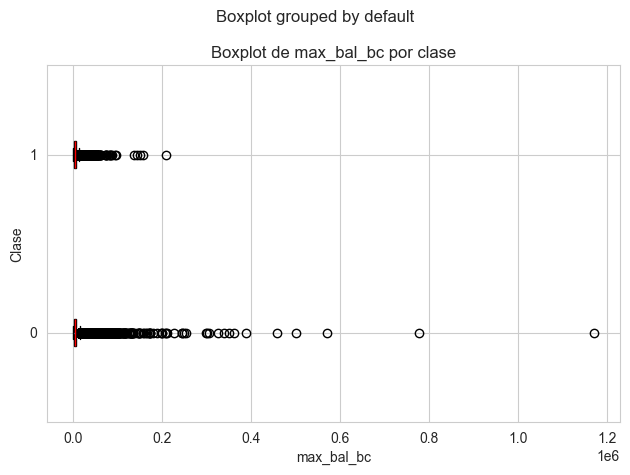

<Figure size 1000x600 with 0 Axes>

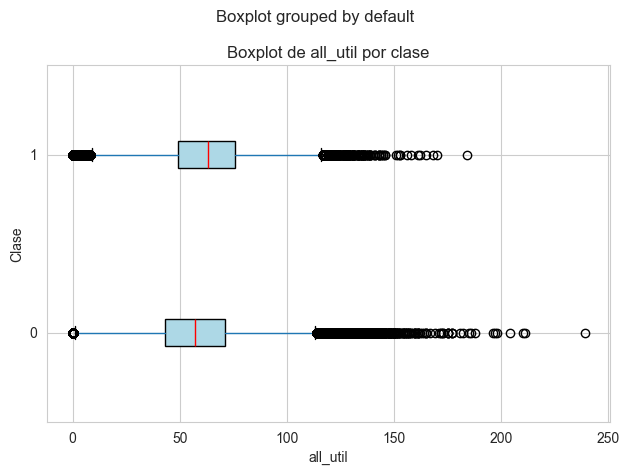

<Figure size 1000x600 with 0 Axes>

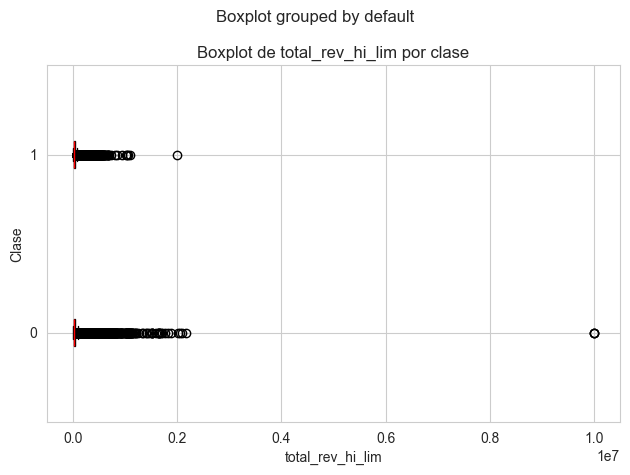

<Figure size 1000x600 with 0 Axes>

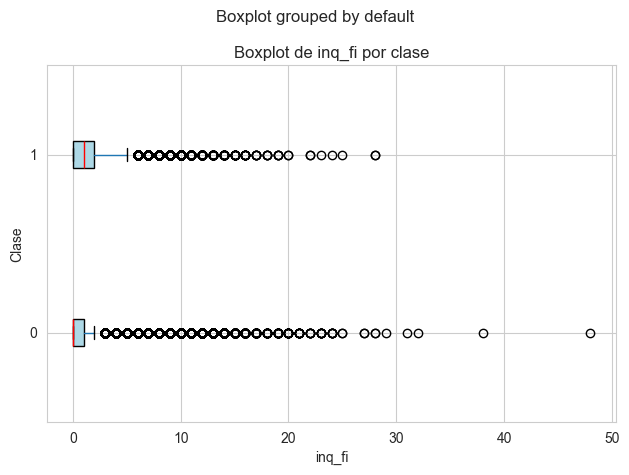

<Figure size 1000x600 with 0 Axes>

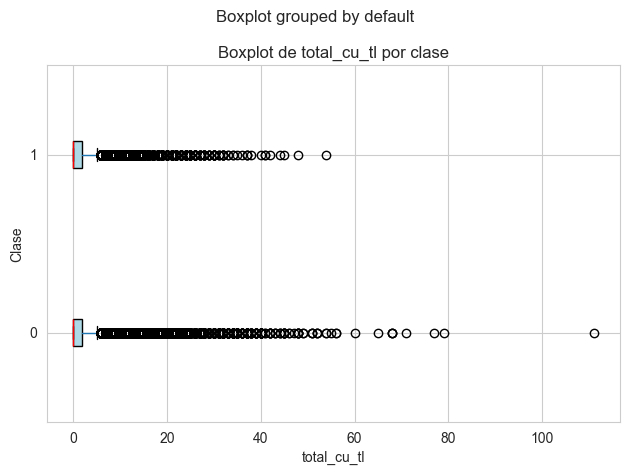

<Figure size 1000x600 with 0 Axes>

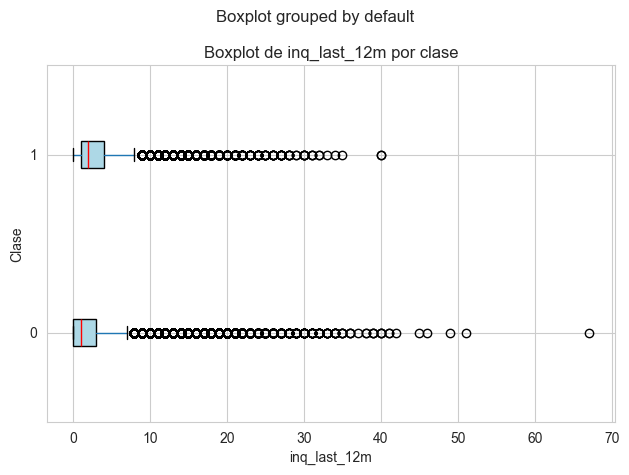

<Figure size 1000x600 with 0 Axes>

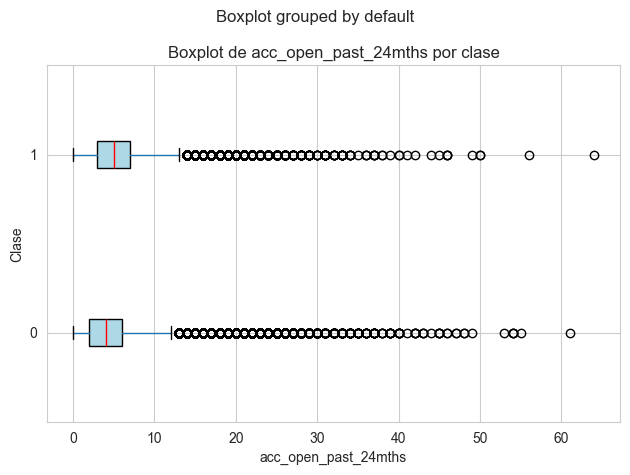

<Figure size 1000x600 with 0 Axes>

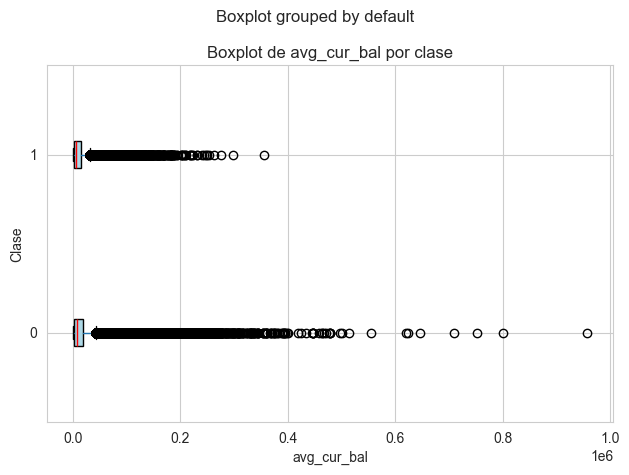

<Figure size 1000x600 with 0 Axes>

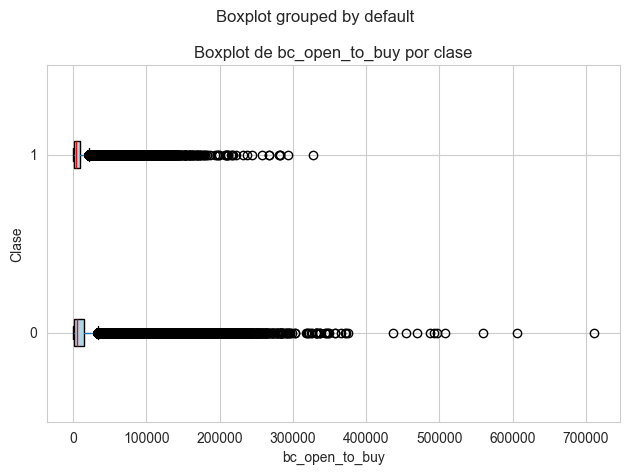

<Figure size 1000x600 with 0 Axes>

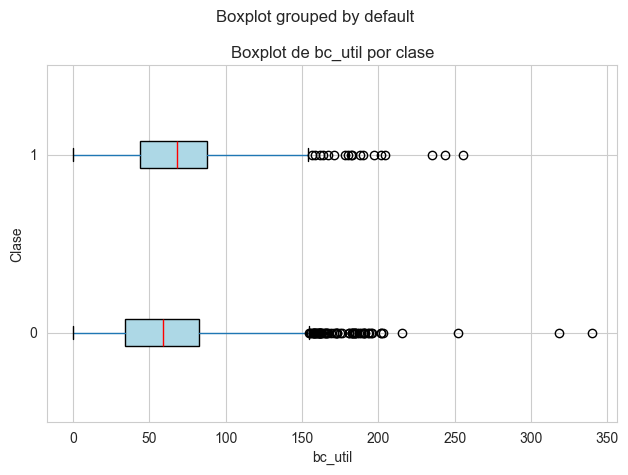

<Figure size 1000x600 with 0 Axes>

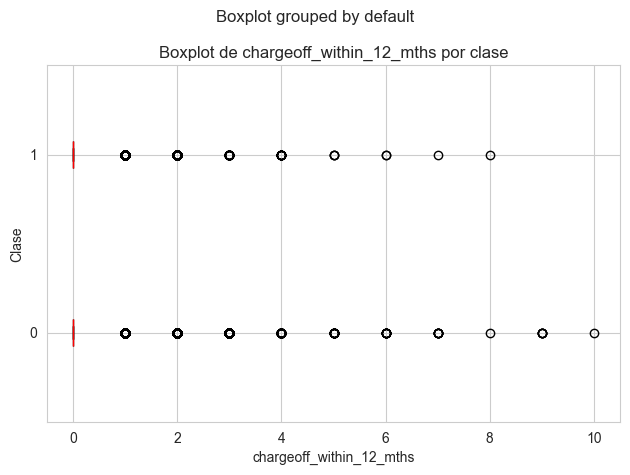

<Figure size 1000x600 with 0 Axes>

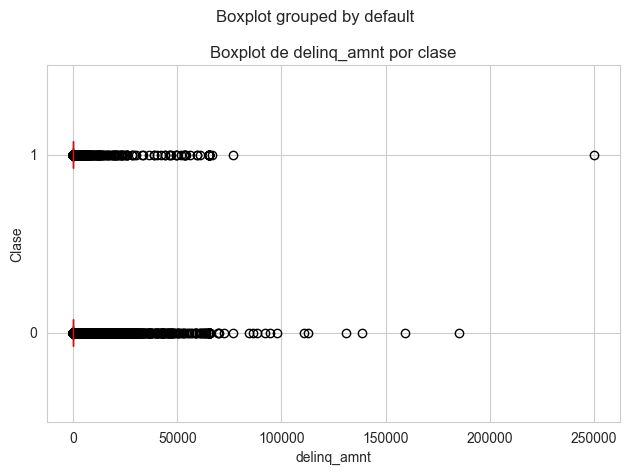

<Figure size 1000x600 with 0 Axes>

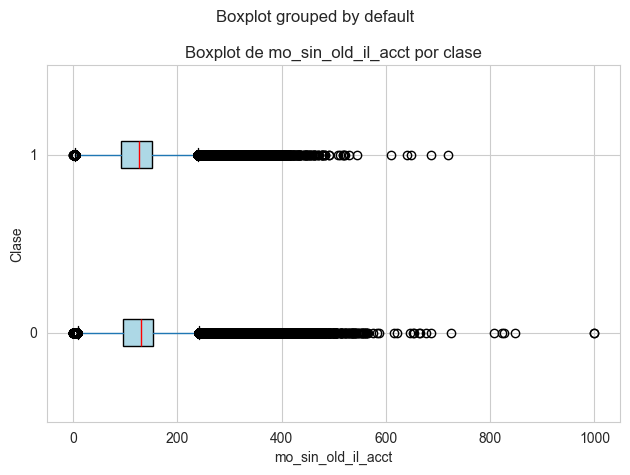

<Figure size 1000x600 with 0 Axes>

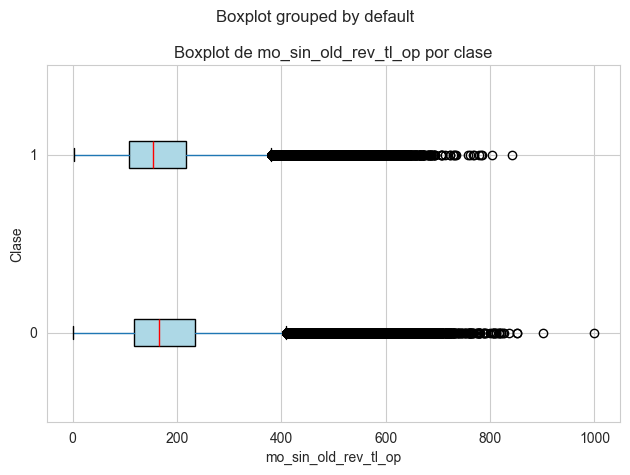

<Figure size 1000x600 with 0 Axes>

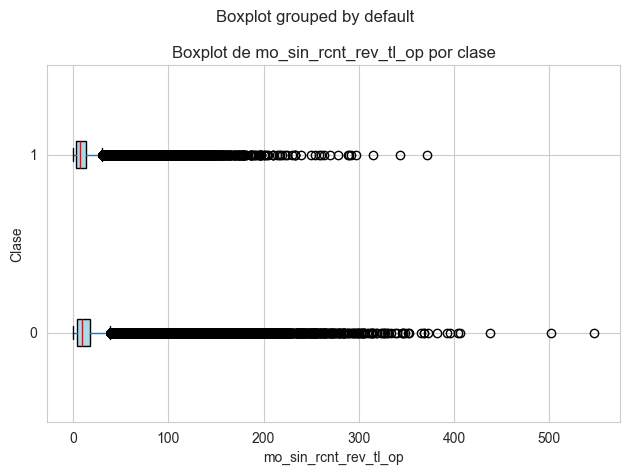

<Figure size 1000x600 with 0 Axes>

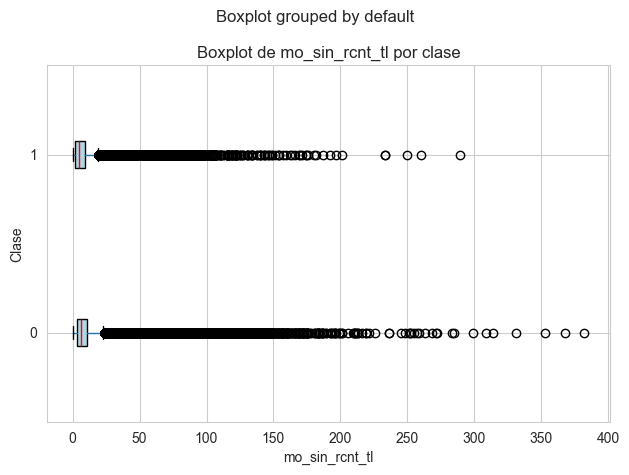

<Figure size 1000x600 with 0 Axes>

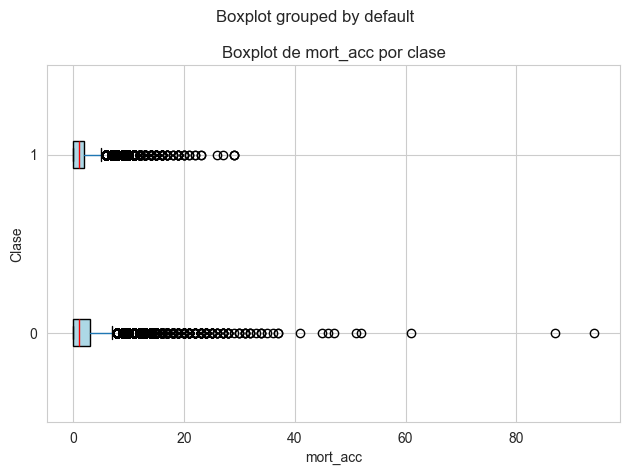

<Figure size 1000x600 with 0 Axes>

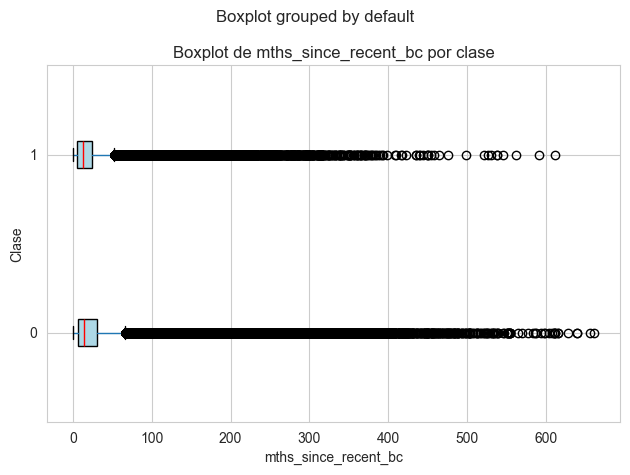

<Figure size 1000x600 with 0 Axes>

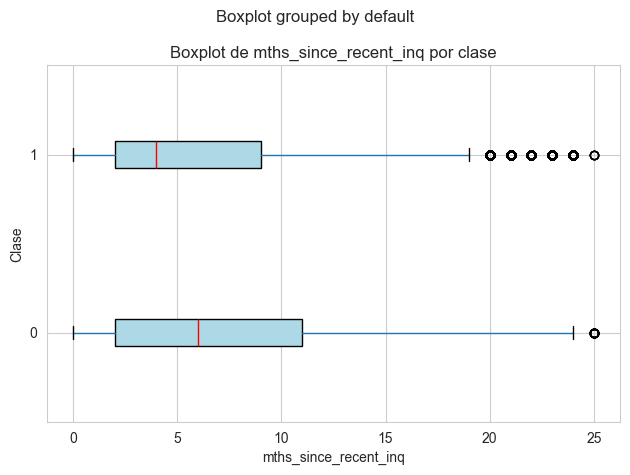

<Figure size 1000x600 with 0 Axes>

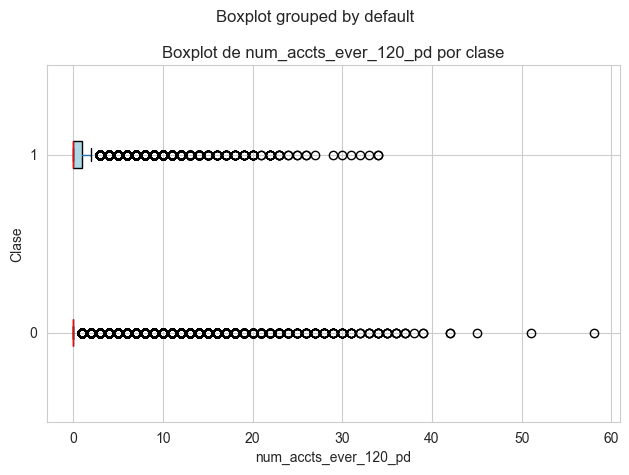

<Figure size 1000x600 with 0 Axes>

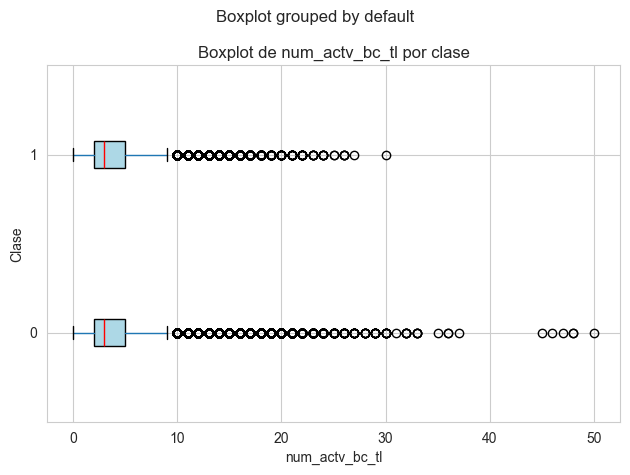

<Figure size 1000x600 with 0 Axes>

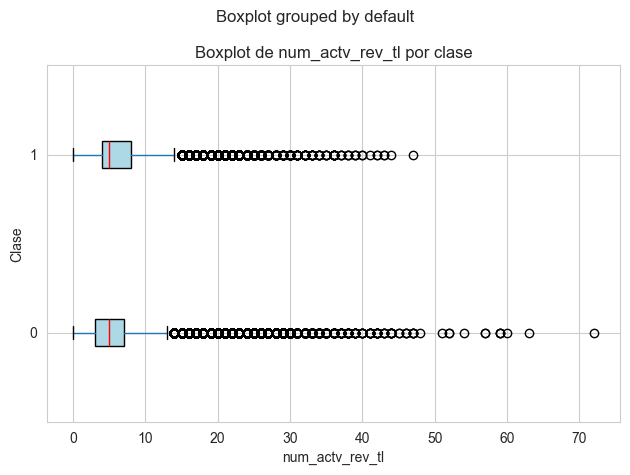

<Figure size 1000x600 with 0 Axes>

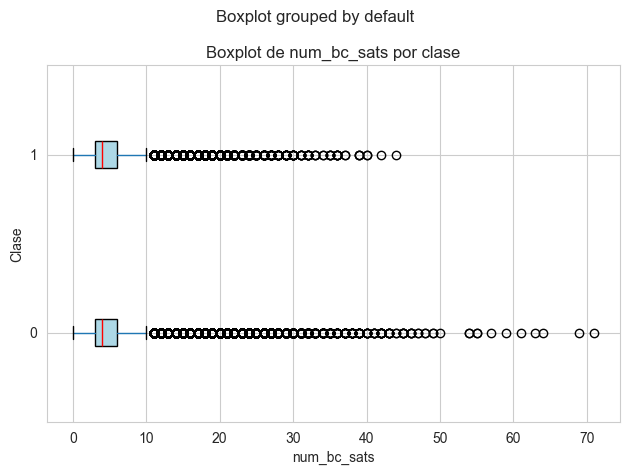

<Figure size 1000x600 with 0 Axes>

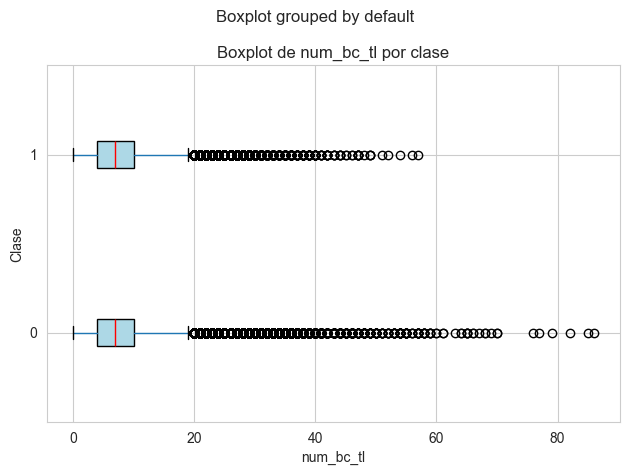

<Figure size 1000x600 with 0 Axes>

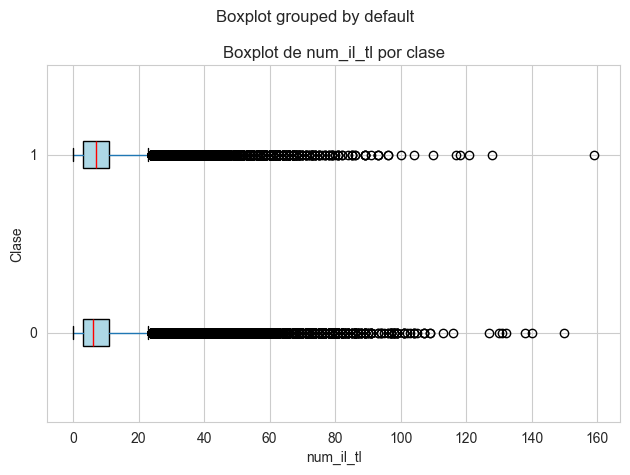

<Figure size 1000x600 with 0 Axes>

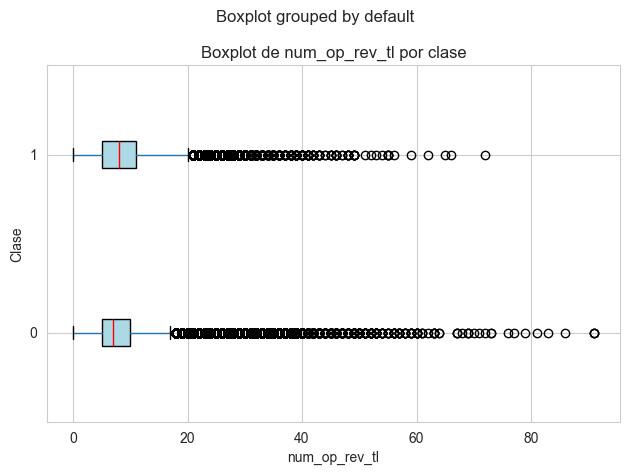

<Figure size 1000x600 with 0 Axes>

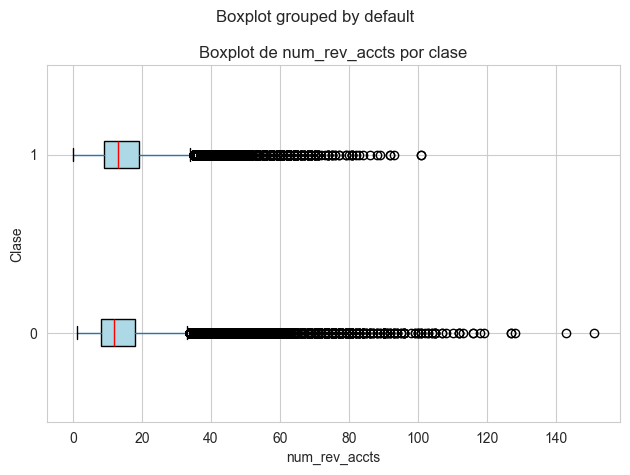

<Figure size 1000x600 with 0 Axes>

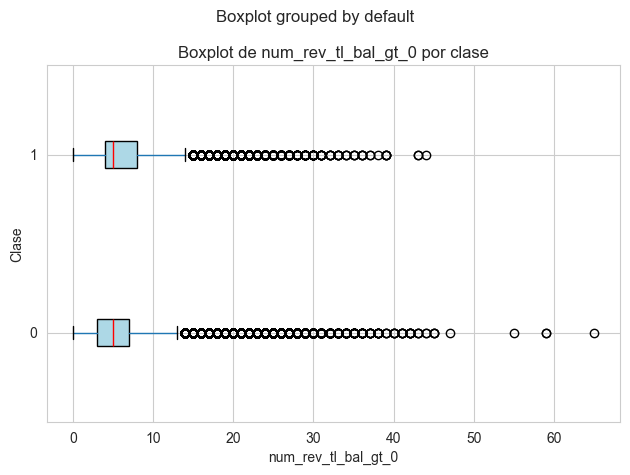

<Figure size 1000x600 with 0 Axes>

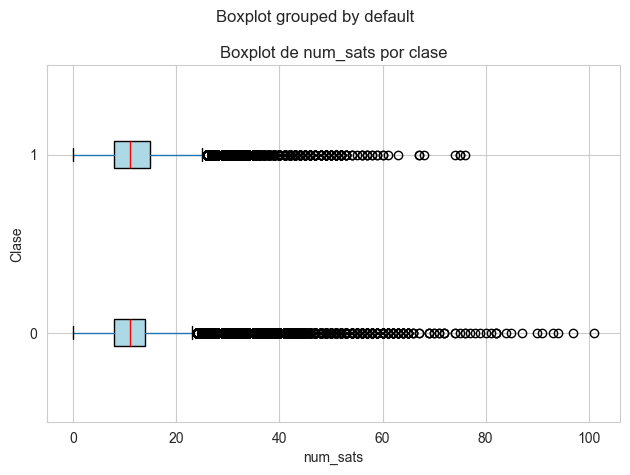

<Figure size 1000x600 with 0 Axes>

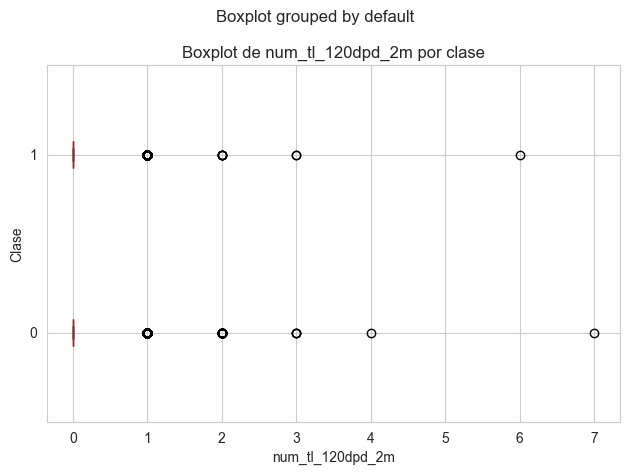

<Figure size 1000x600 with 0 Axes>

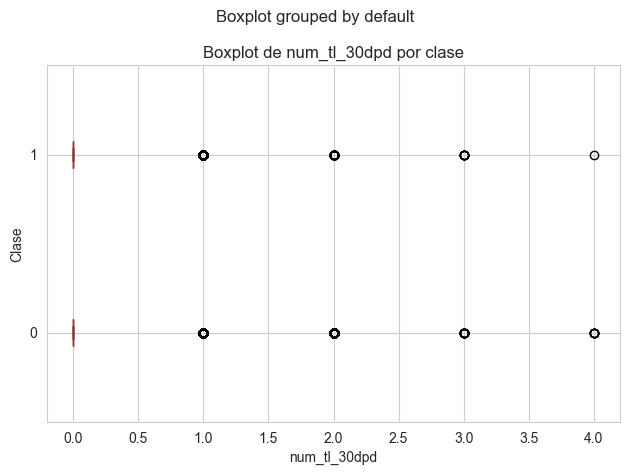

<Figure size 1000x600 with 0 Axes>

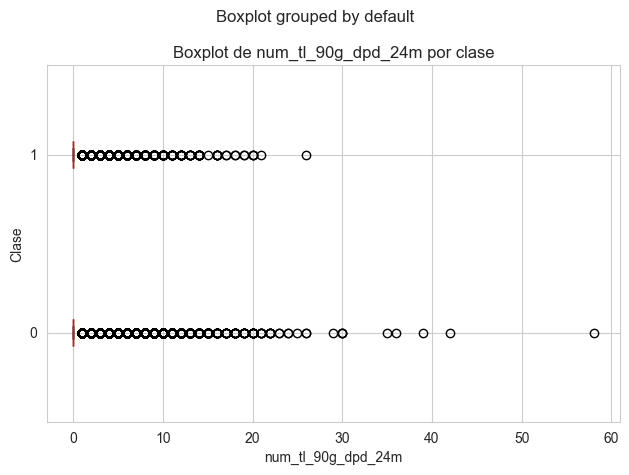

<Figure size 1000x600 with 0 Axes>

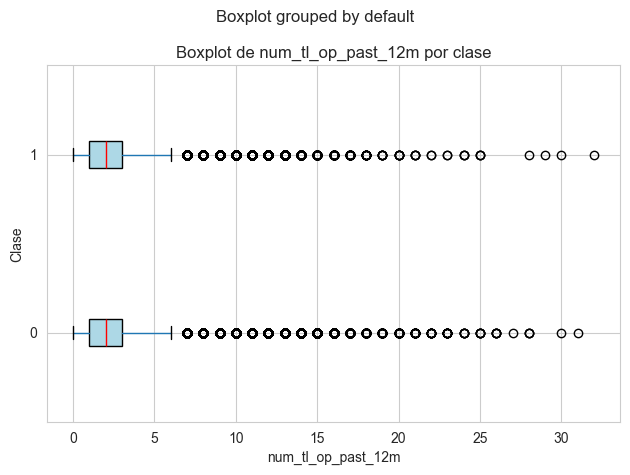

<Figure size 1000x600 with 0 Axes>

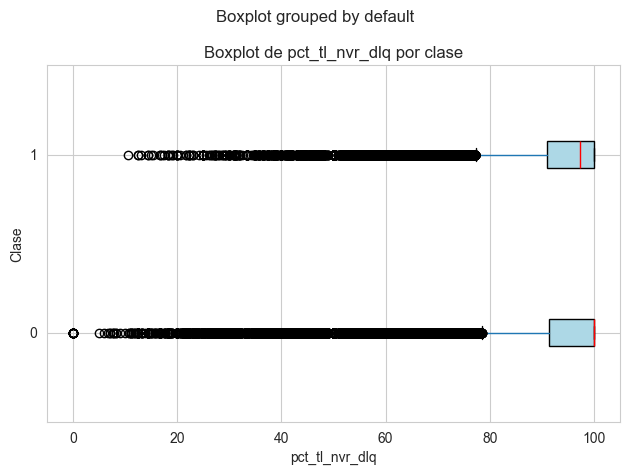

<Figure size 1000x600 with 0 Axes>

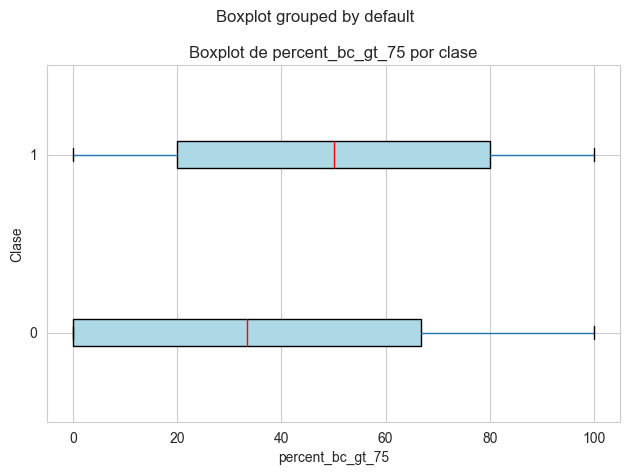

<Figure size 1000x600 with 0 Axes>

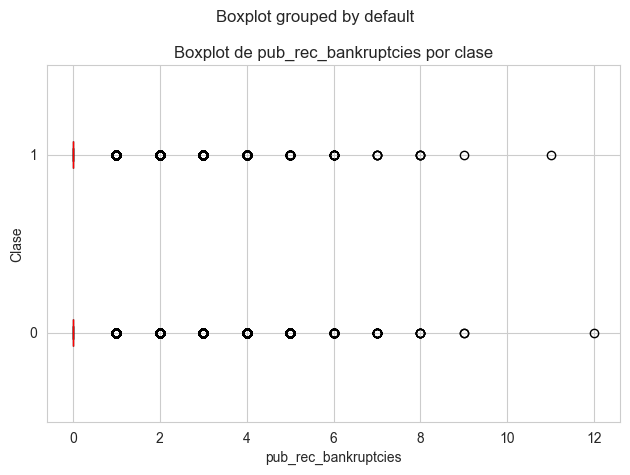

<Figure size 1000x600 with 0 Axes>

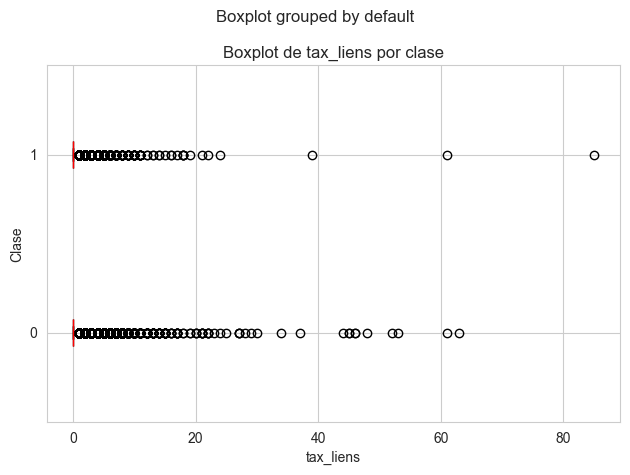

<Figure size 1000x600 with 0 Axes>

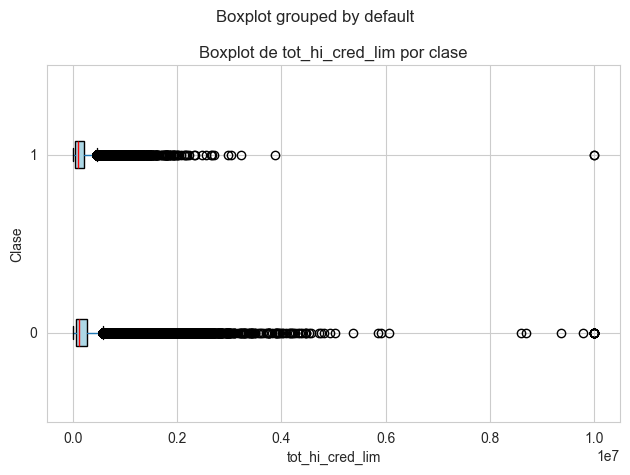

<Figure size 1000x600 with 0 Axes>

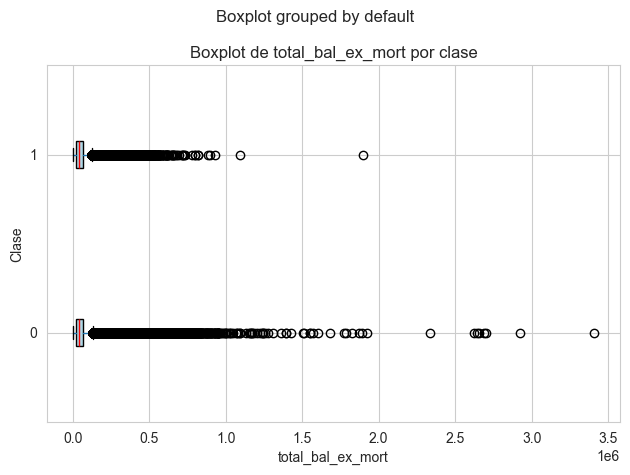

<Figure size 1000x600 with 0 Axes>

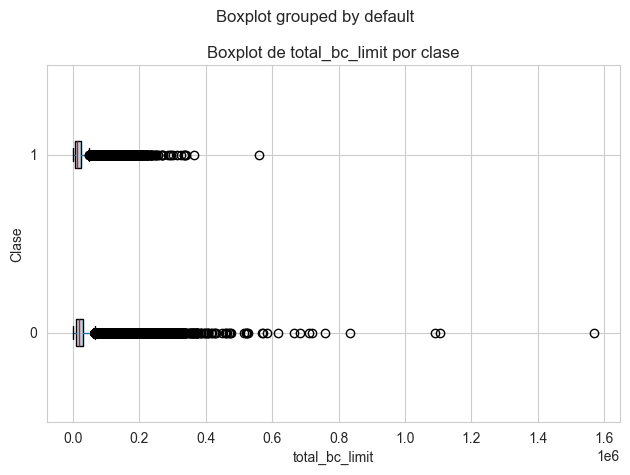

<Figure size 1000x600 with 0 Axes>

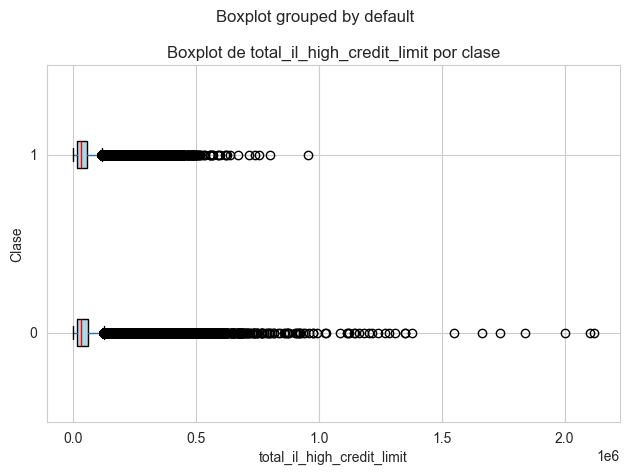

In [33]:
target_column = 'default'  

for i in range(0, len(num_vars), 10):
    vars_grupo = num_vars[i:i+10]
    
    for var in vars_grupo:
        plt.figure(figsize=(10, 6))
        
        # Crear boxplot por clase
        df_actualizado.boxplot(column=var, by=target_column, vert=False, 
                  patch_artist=True,
                  boxprops=dict(facecolor="lightblue", color="black"),
                  medianprops=dict(color="red"))
        
        plt.title(f'Boxplot de {var} por clase') 
        plt.xlabel(var)
        plt.ylabel('Clase')
        plt.tight_layout()
        plt.show()


Podemos observar que bastantes de las variables del dataset tienen outliers muy marcados al realizar los boxplots entre clases lo que se tomara en cuenta cuando se realiza la imputacion de las variables seleccionadas en el preprocesamiento 

realizamos una matriz de correlacion para variables numericas, como seria demasiado dificil de descifrar el heatmap convencional se utilizara una tabla con el top 20 de las mayores correlaciones entre las variables numericas para de esta manera elegir mas claramente las variables que se usaran en el modelo

In [34]:
num_df = df_actualizado[num_vars]

In [35]:
corr_matrix = num_df.corr()

In [36]:
corr_pairs=(
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)).stack().reset_index()
)

In [37]:
corr_pairs.columns=["variable1","variable2","correlacion"]

In [38]:
top_corr=corr_pairs.reindex(corr_pairs.correlacion.abs().sort_values(ascending=False).index)
print(top_corr.head(20))

              variable1                   variable2  correlacion
524      fico_range_low             fico_range_high     1.000000
0             loan_amnt                 funded_amnt     0.999755
69          funded_amnt             funded_amnt_inv     0.999341
1             loan_amnt             funded_amnt_inv     0.999038
749            open_acc                    num_sats     0.998966
2230    num_actv_rev_tl         num_rev_tl_bal_gt_0     0.983638
1186        tot_cur_bal             tot_hi_cred_lim     0.975582
1468       total_bal_il  total_il_high_credit_limit     0.952186
71          funded_amnt                 installment     0.945967
3             loan_amnt                 installment     0.945625
138     funded_amnt_inv                 installment     0.945118
1466       total_bal_il           total_bal_ex_mort     0.900038
2413  total_bal_ex_mort  total_il_high_credit_limit     0.877179
898          revol_util                     bc_util     0.868537
1560        open_rv_24m  

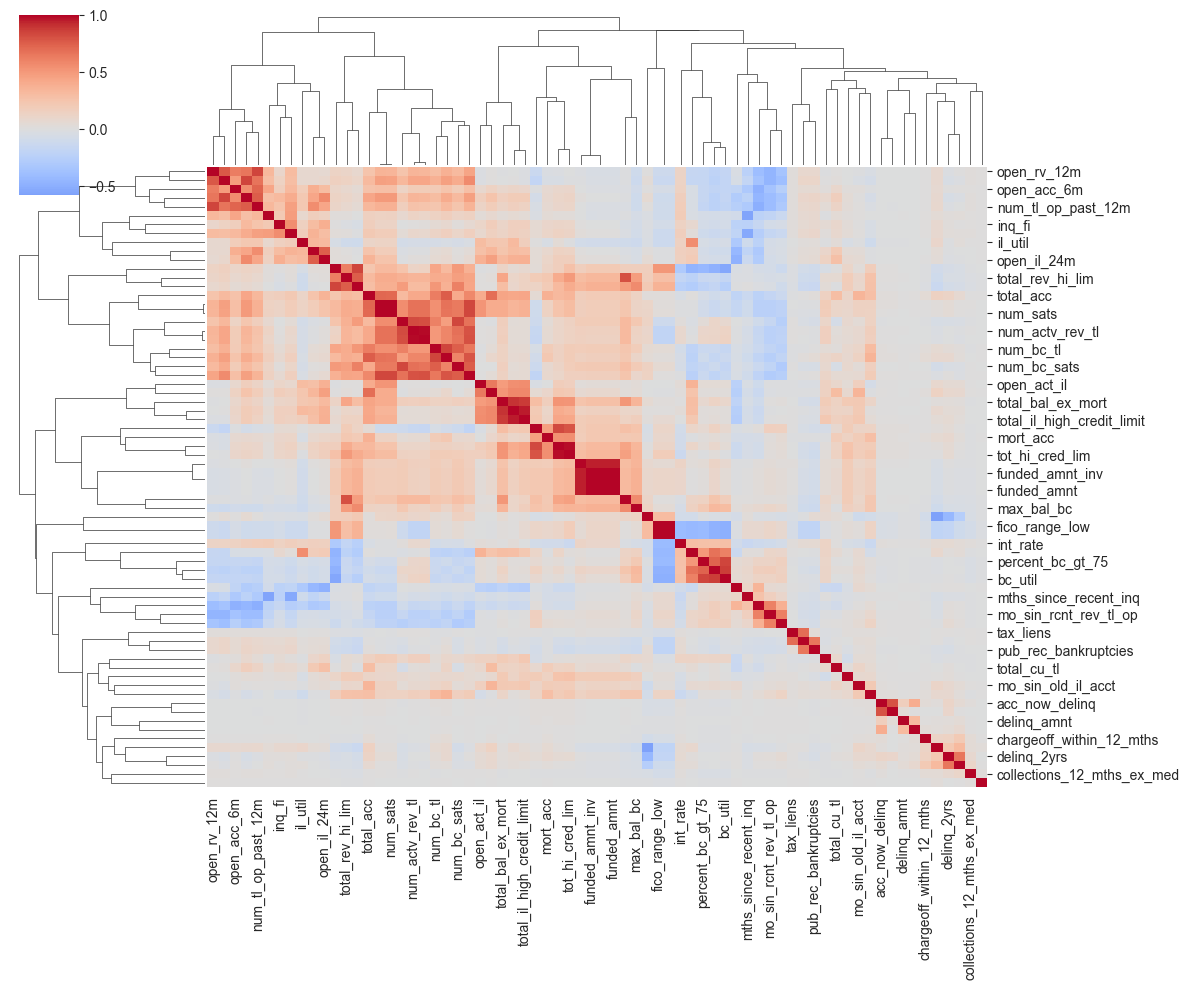

In [39]:
sns.clustermap(corr_matrix, cmap="coolwarm", center=0, figsize=(12, 10))
plt.show()

Podemos observar con la tabla y el grafico realizado que tenemos bastantes variables que estan altamente correlacionadas entre si y que pertenecen al mismo grupo con informacion similar, esto se tomara en cuenta a la hora de realizar el modelo 

realizamos una matriz de correlacion para categoricas usando cramer 

In [40]:
corr_cat = categorical_corr_matrix(df, cat)

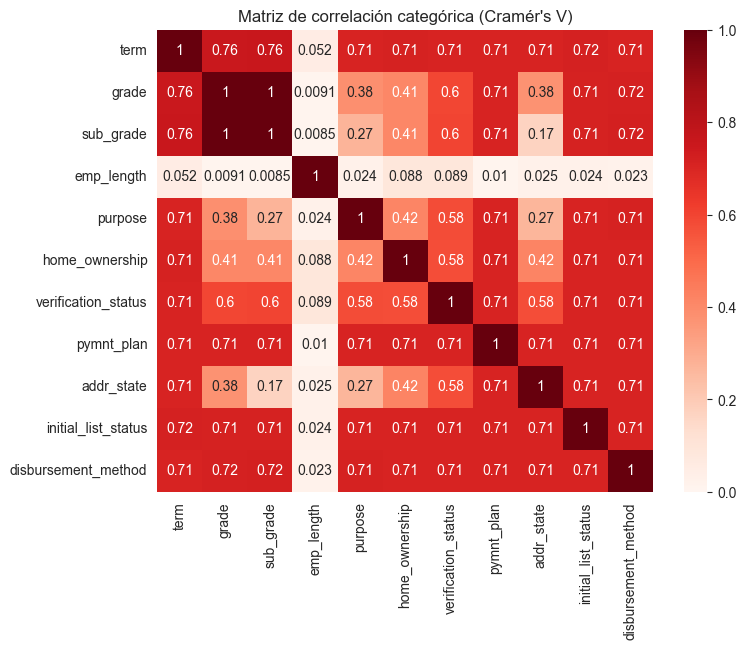

In [41]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_cat, annot=True, cmap="Reds", vmin=0, vmax=1)
plt.title("Matriz de correlación categórica (Cramér's V)")
plt.show()

Podemos observar que emp-lenght tiene muy baja correlacion a diferencia del resto de variables por lo que ofrece informacion mas unica y se puede usar para el modelo, del resto la mayoria tienen correlaciones cercanas a 0.7 por lo que solo se tomaran  las que se consideren mas importantes 

# Preprocesamiento de datos 

## Eleccion de variables del modelo

A partir de lo realizado en el EDA se eligen las variables que se van a usar en el modelo 

In [42]:
# Variables del modelo final
vars_modelo=["loan_amnt","int_rate","fico_range_high","emp_length","annual_inc","purpose","home_ownership","dti","addr_state","revol_util","open_acc","delinq_2yrs","acc_now_delinq","term","pub_rec_bankruptcies","mths_since_recent_inq","collections_12_mths_ex_med"]

In [43]:
df_final=df_actualizado[vars_modelo]

In [44]:
NA_porcentaje=df_final.isna().mean() * 100
print(NA_porcentaje.to_string())

loan_amnt                      0.001460
int_rate                       0.001460
fico_range_high                0.001460
emp_length                     6.499754
annual_inc                     0.001637
purpose                        0.001460
home_ownership                 0.001460
dti                            0.077144
addr_state                     0.001460
revol_util                     0.081170
open_acc                       0.002743
delinq_2yrs                    0.002743
acc_now_delinq                 0.002743
term                           0.001460
pub_rec_bankruptcies           0.061839
mths_since_recent_inq         13.069751
collections_12_mths_ex_med     0.007874


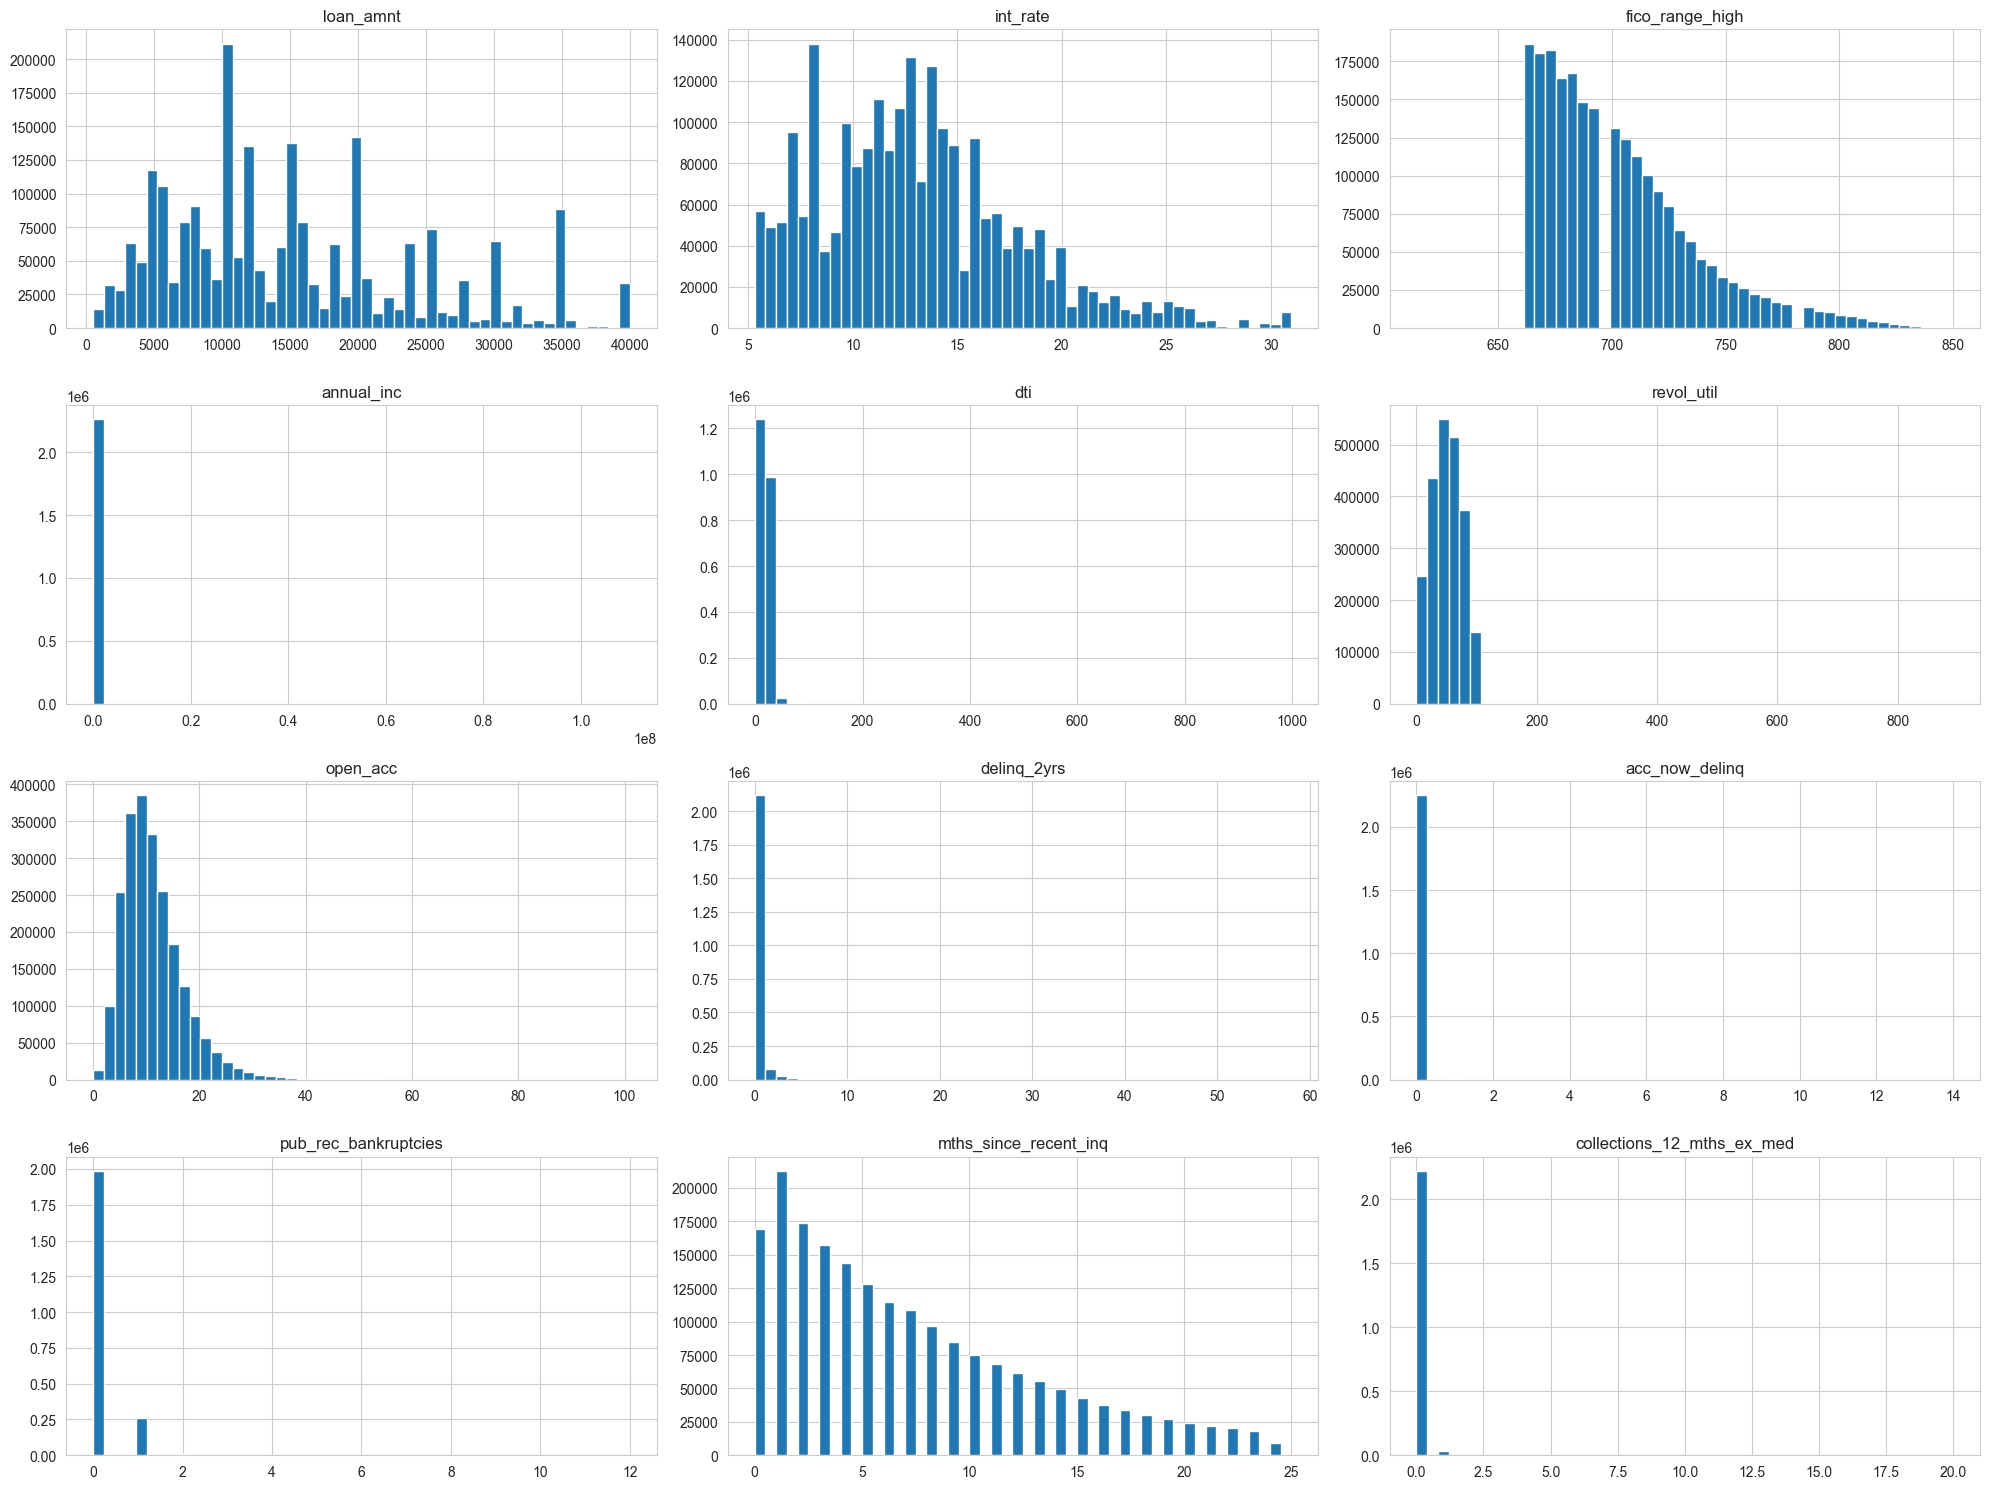

In [45]:
num=df_final.select_dtypes(include=["float64"]).columns
for i in range(0, len(num), 12):
    df_final[num[i:i+12]].hist(figsize=(20,15), bins=50)
    plt.tight_layout()
    plt.show()

In [46]:
low, high = 0.01, 0.99

In [47]:
percentiles = df_final[num].quantile([low, high])

In [48]:
var_filtro = [
    'annual_inc',
    'dti',
    'revol_util',
    'open_acc',
    'loan_amnt',
    'int_rate',
    'fico_range_high',
    'mths_since_recent_inq'
]

In [49]:
mask = pd.Series(True, index=df_final.index)  
for col in var_filtro:
    q_low, q_high = percentiles.loc[low, col], percentiles.loc[high, col]
    df_final[col] = df_final[col].clip(q_low, q_high)

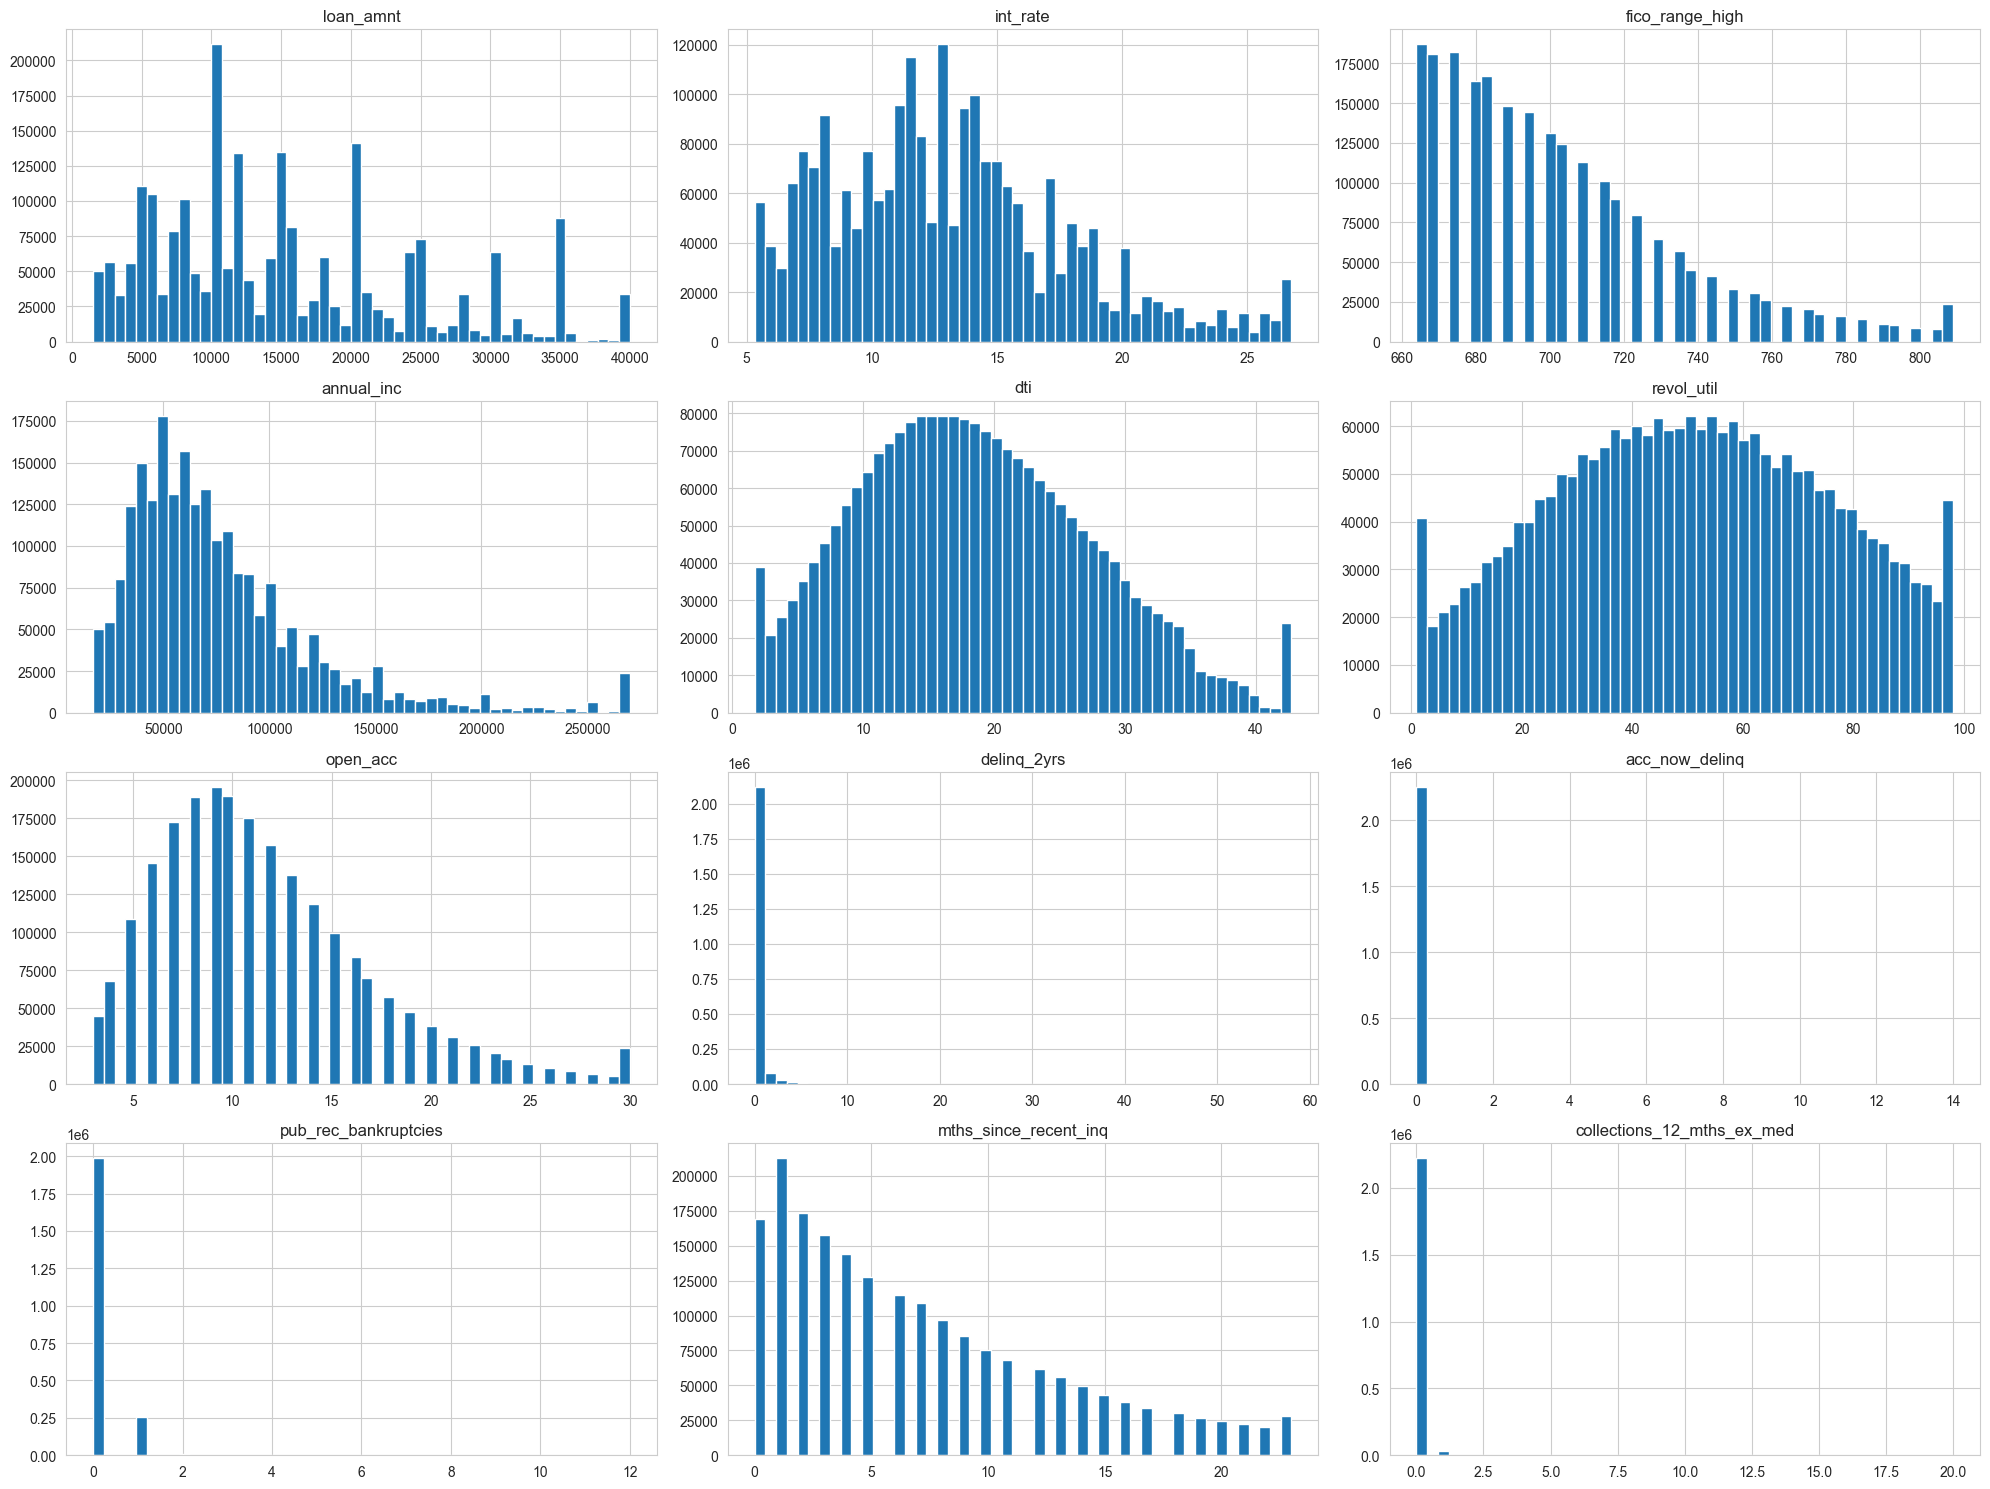

In [50]:
for i in range(0, len(num), 12):
    df_final[num[i:i+12]].hist(figsize=(20,15), bins=50)
    plt.tight_layout()
    plt.show()

## Split de los Datos 

In [51]:
X=df_final
Y=df_actualizado['default']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,      
    stratify=Y,        
    random_state=0    
)

## Imputacion de datos faltantes 

Las variables que tienen datos faltantes son las numericas de nuestro X por lo que realizaremos la siguiente imputacion de datos faltantes 

In [53]:
imp_simple= X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
imp_missing = ["mths_since_recent_inq", "delinq_2yrs", "pub_rec_bankruptcies"]
imp_simple = [col for col in imp_simple if col not in imp_missing]

In [54]:
before_train = X_train[imp_missing].copy()
before_test  = X_test[imp_missing].copy()

In [55]:
before_train_num = X_train[imp_simple].copy()
before_test_num  = X_test[imp_simple].copy()

In [56]:
imputer = SimpleImputer(strategy="median")
X_train[imp_simple]= imputer.fit_transform(X_train[imp_simple])
X_test[imp_simple] = imputer.transform(X_test[imp_simple])

In [57]:
imputer_special = SimpleImputer(strategy="constant", fill_value=-1)
X_train[imp_missing]=imputer_special.fit_transform(X_train[imp_missing])
X_test[imp_missing]=imputer_special.transform(X_test[imp_missing])

In [58]:
after_train = X_train[imp_missing].copy()
after_test  = X_test[imp_missing].copy()

In [59]:
after_train_num = X_train[imp_simple].copy()
after_test_num  = X_test[imp_simple].copy()

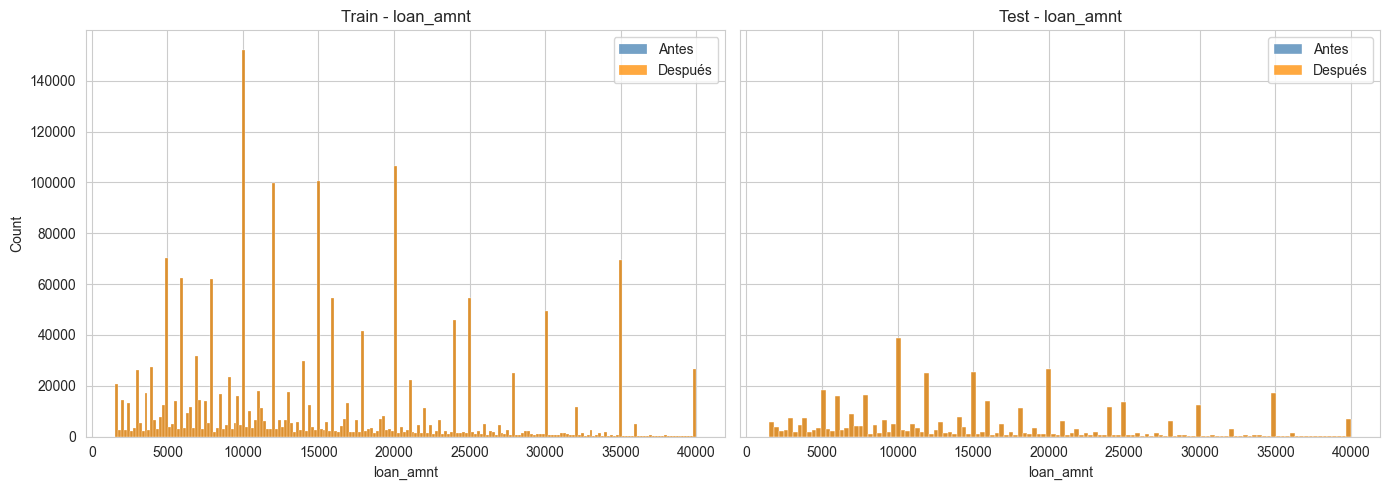

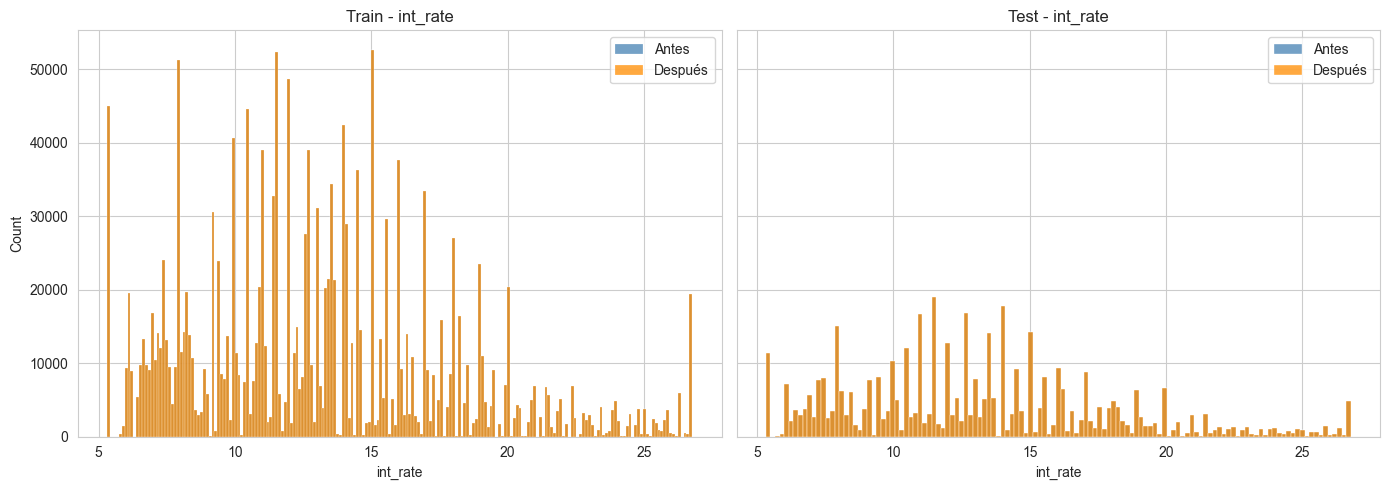

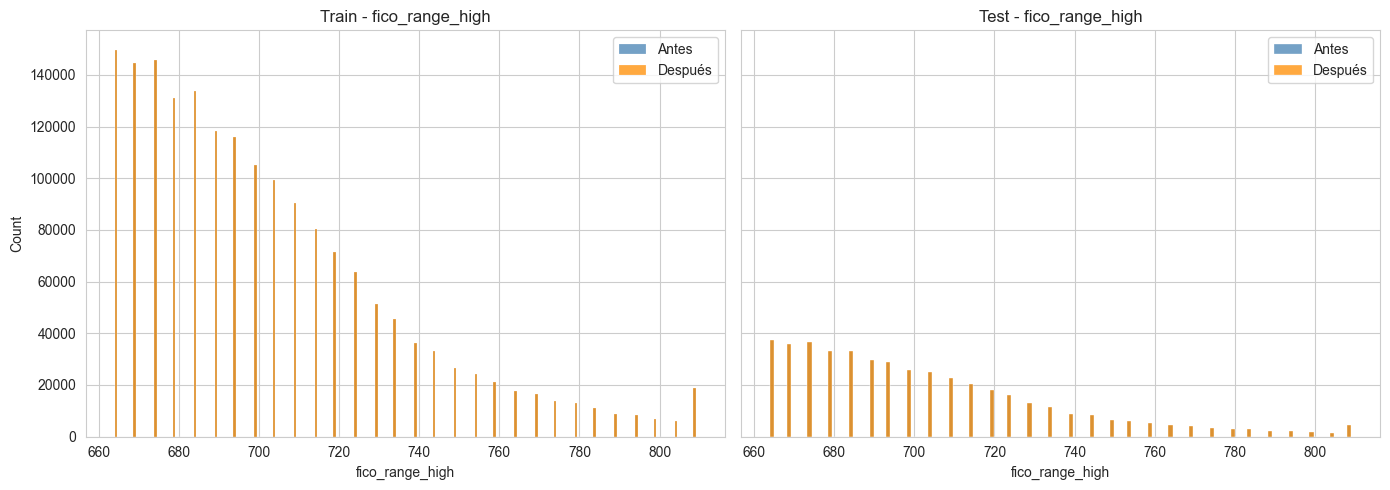

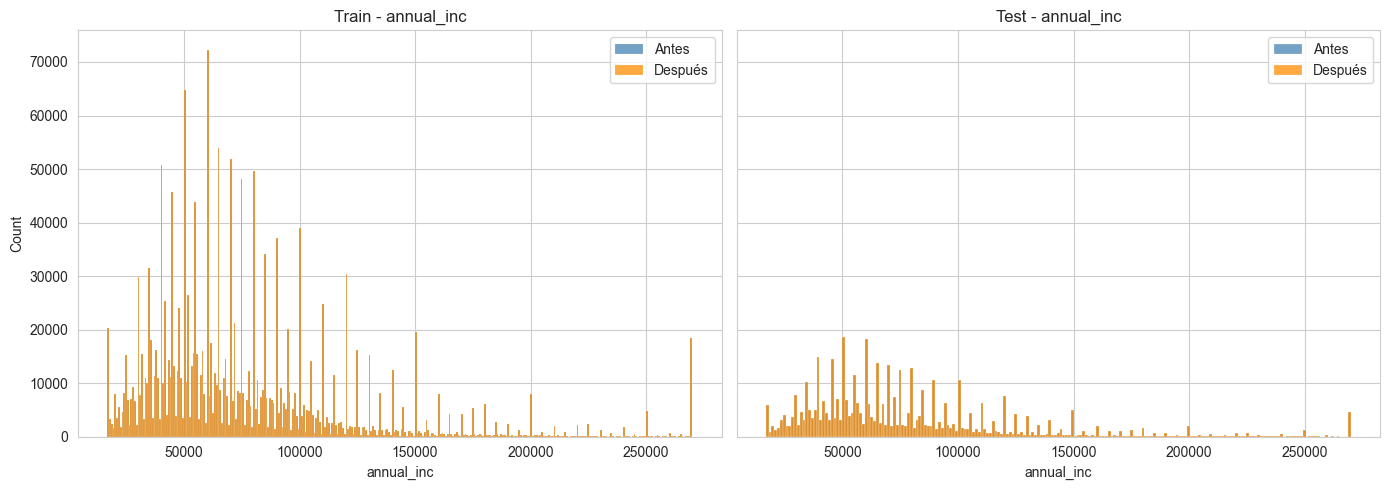

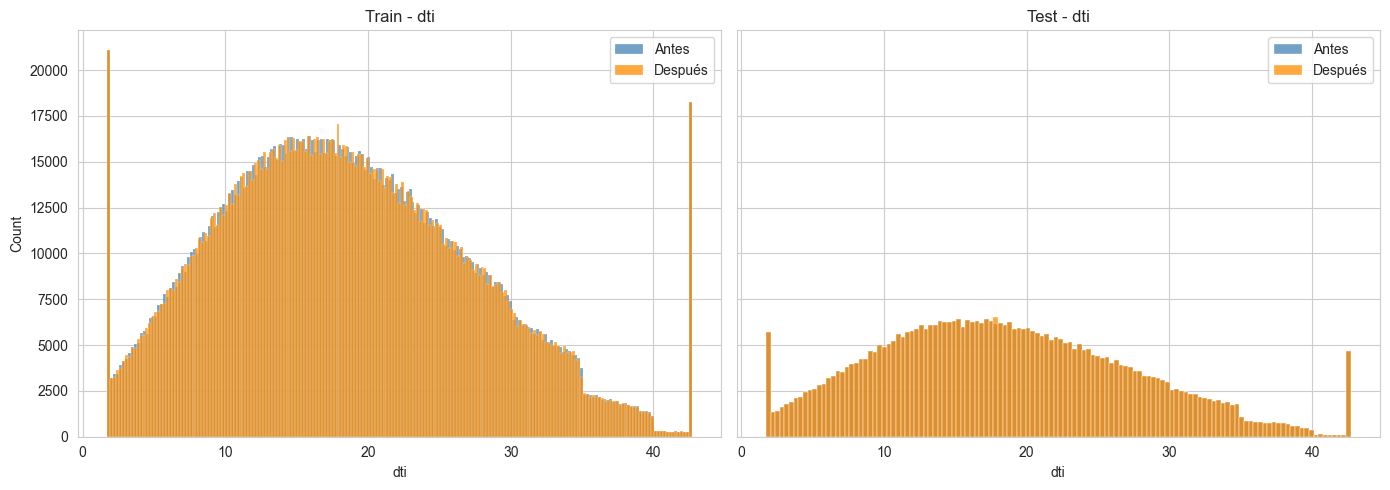

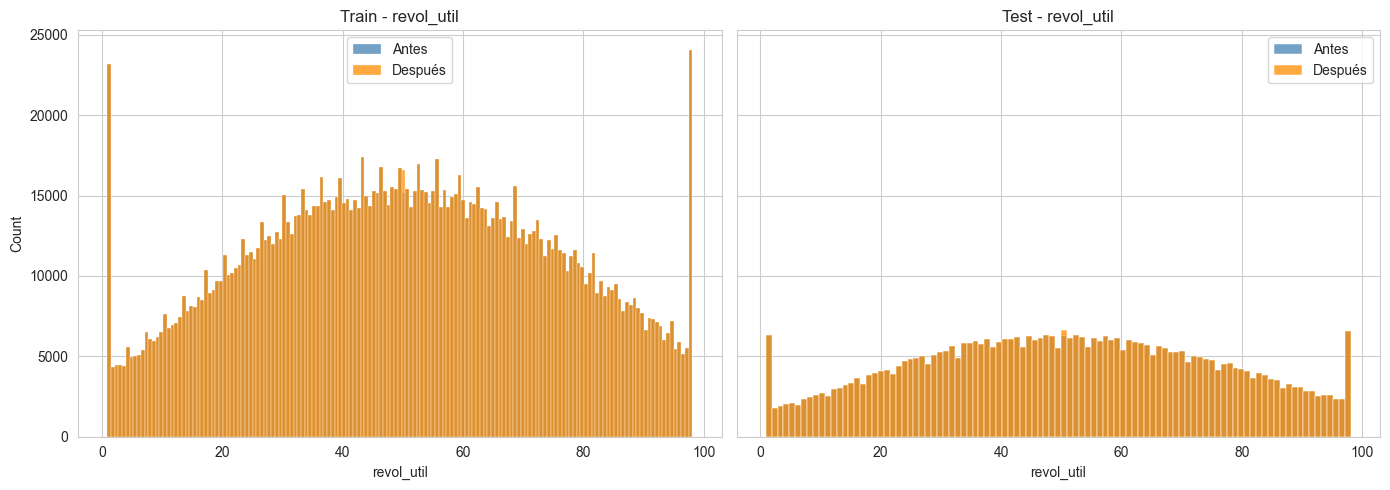

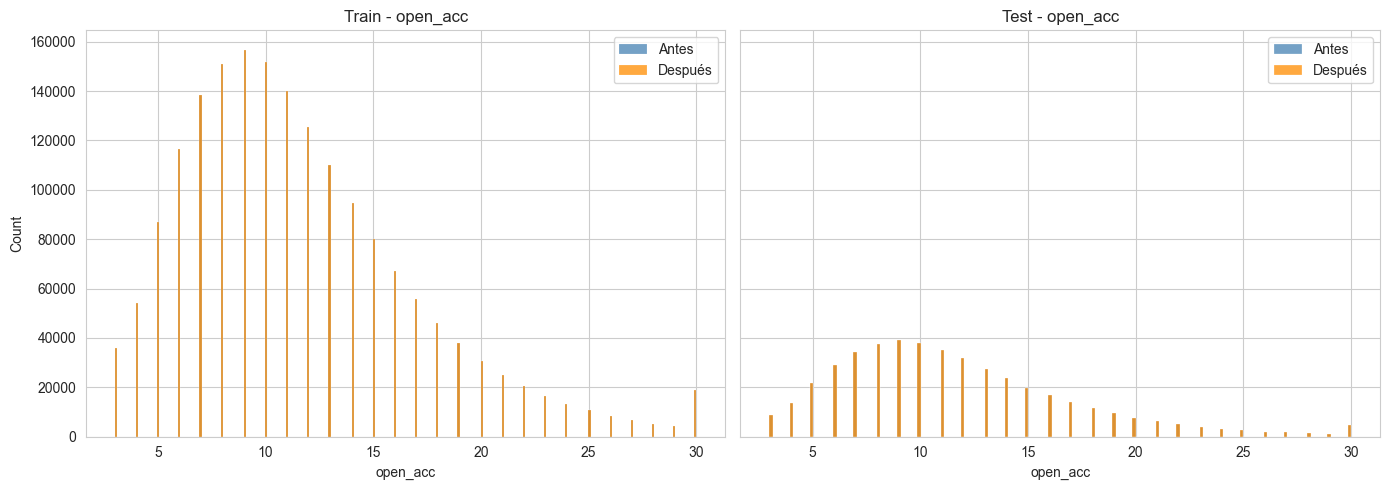

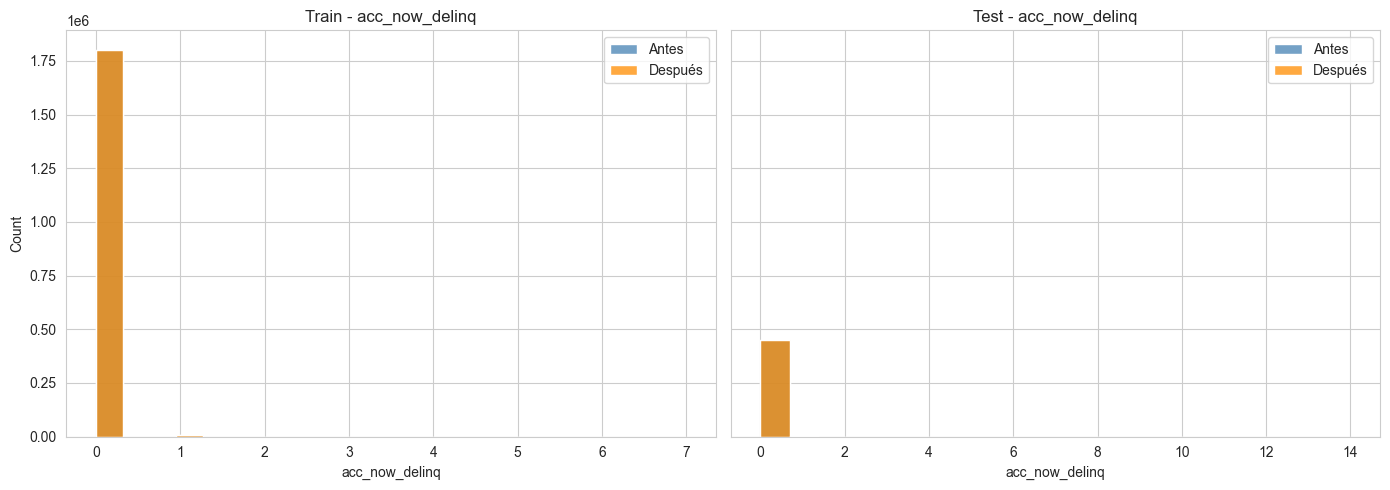

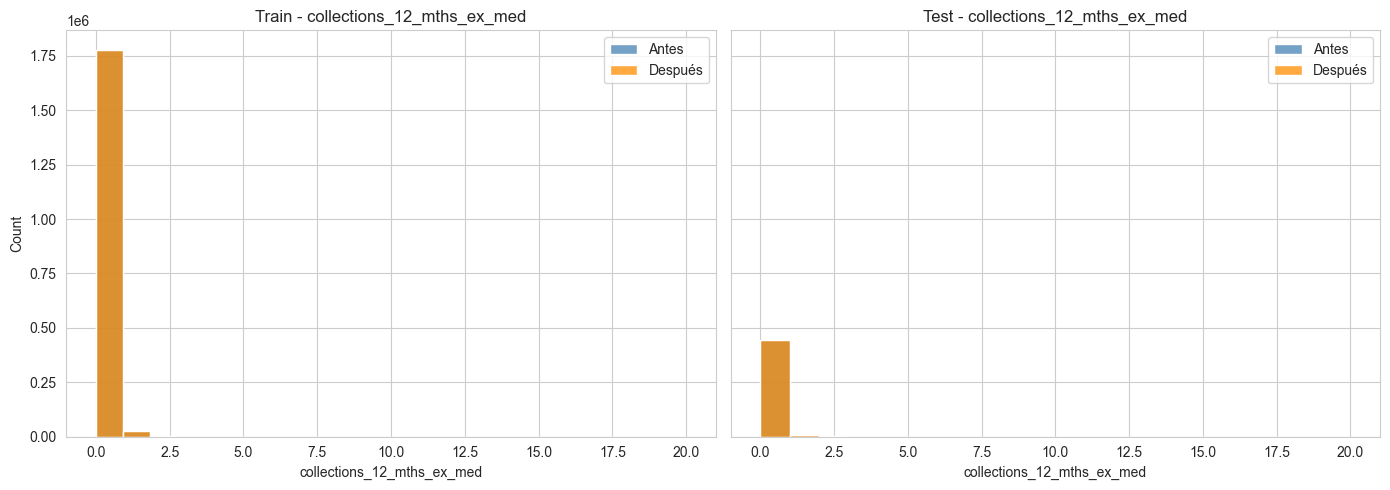

In [60]:
plot_distributions(before_train_num, after_train_num, before_test_num, after_test_num, imp_simple)

Podemos observar que ha simple vista no cambia la distribucion de las variables pero se va a probar con los test a ver si cambia la distribucion

In [61]:
df_results = evaluar_imputacion(before_train_num, after_train_num, imp_simple)
print(df_results)

                     variable  n_missing  ks_p     shapiro_p      test_usado  \
0                   loan_amnt         24   0.0  2.885942e-42  Mann-Whitney U   
1                    int_rate         24   0.0  2.157329e-33  Mann-Whitney U   
2             fico_range_high         24   0.0  9.087899e-49  Mann-Whitney U   
3                  annual_inc         25   0.0  5.283772e-55  Mann-Whitney U   
4                         dti       1398   0.0  6.330459e-23  Mann-Whitney U   
5                  revol_util       1459   0.0  3.392187e-25  Mann-Whitney U   
6                    open_acc         46   0.0  5.166079e-42  Mann-Whitney U   
7              acc_now_delinq         46   0.0  3.789117e-95  Mann-Whitney U   
8  collections_12_mths_ex_med        142   0.0  1.547970e-93  Mann-Whitney U   

    p_value  distribucion_cambiada  
0  0.999464                  False  
1  0.954652                  False  
2  0.828931                  False  
3  0.924762                  False  
4  0.985367   

Podemos observar que la distribucion no cambio a la hora de hacer imputacion por mediana y fue exitosa 

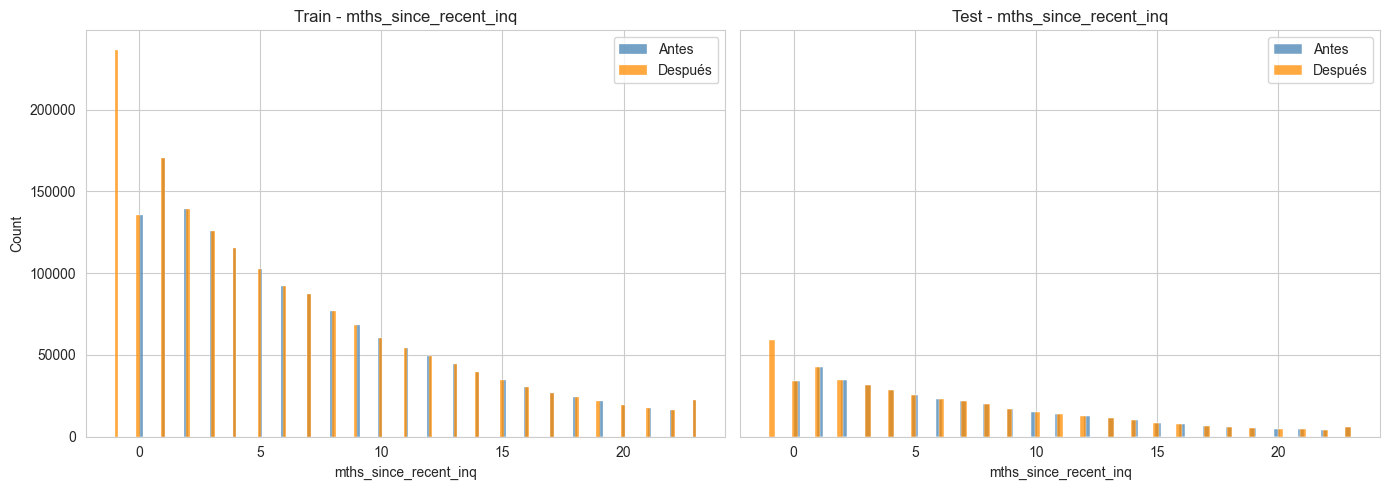

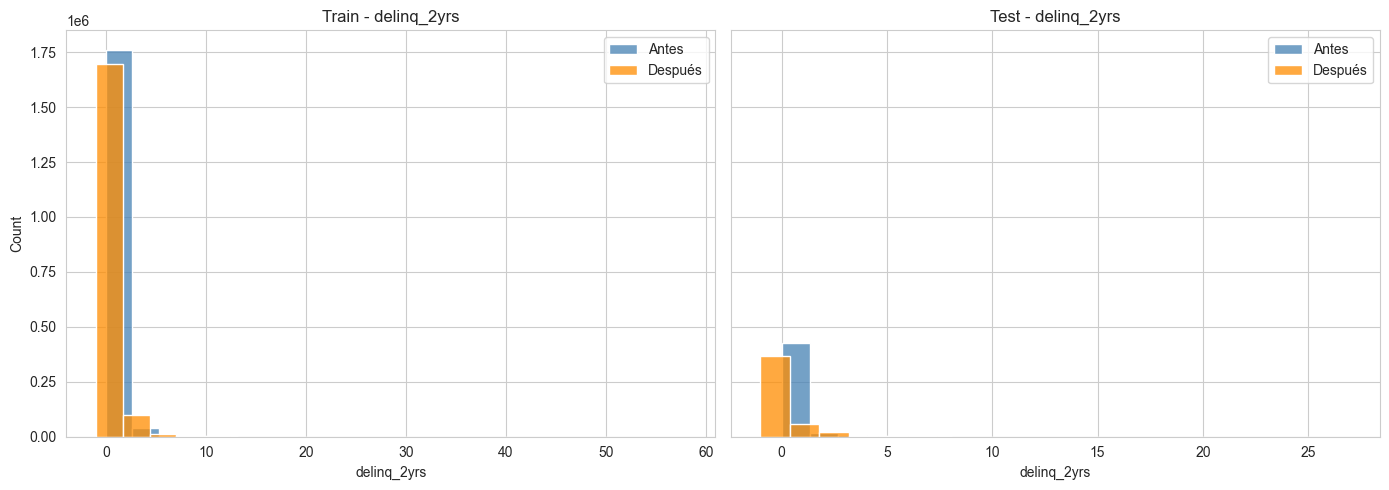

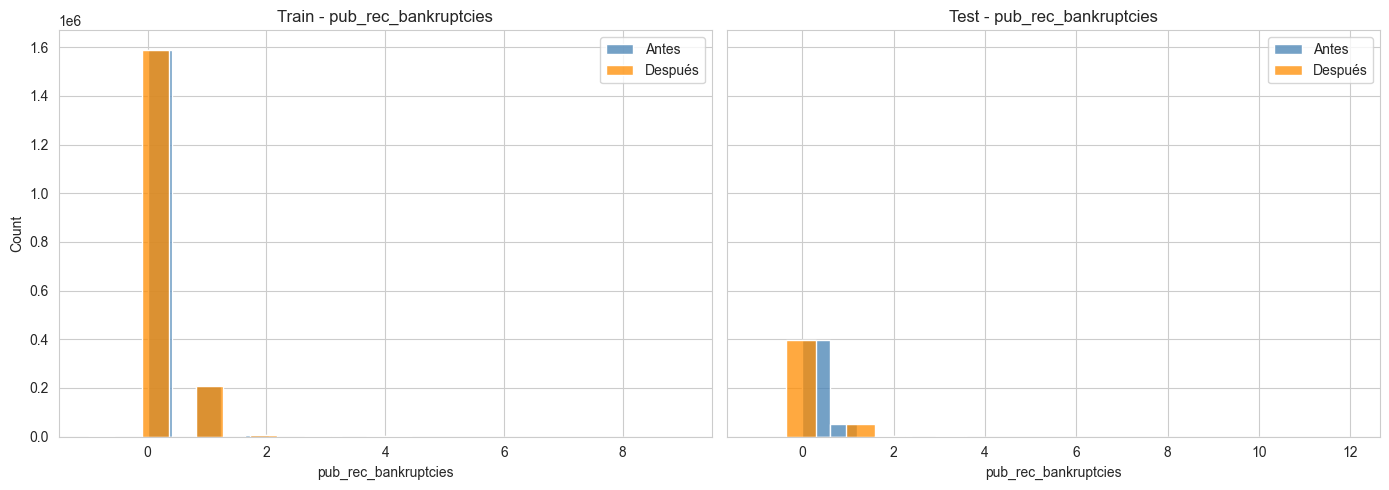

In [62]:
plot_distributions(before_train,after_train,before_test,after_test,imp_missing)

Podemos observar que la distribucion en su forma general no cambio mucho para la variables en cuestion, ahora distingue mejor cuales son valores reales y los que eran ausencia porque sus NA no eran aleatorios

In [63]:
# columnas categóricas a imputar con la moda
imp_moda = ["term", "addr_state", "purpose", "home_ownership", "emp_length"]
before_train_cat = X_train[imp_moda].copy()
before_test_cat  = X_test[imp_moda].copy()
imputer_moda = SimpleImputer(strategy="most_frequent")
X_train[imp_moda] = imputer_moda.fit_transform(X_train[imp_moda])
X_test[imp_moda]  = imputer_moda.transform(X_test[imp_moda])

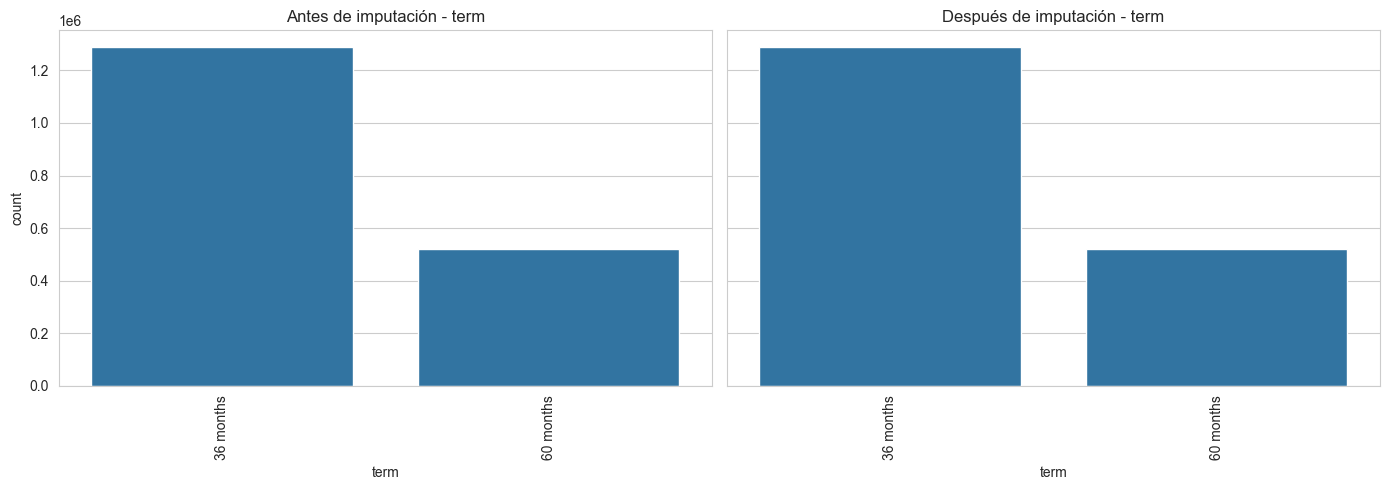

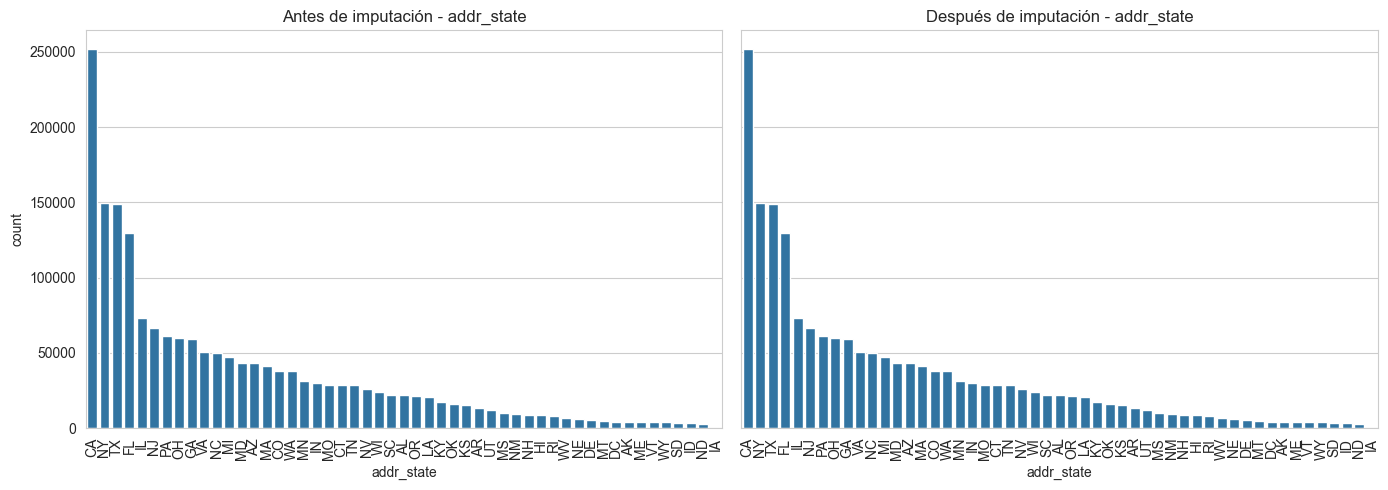

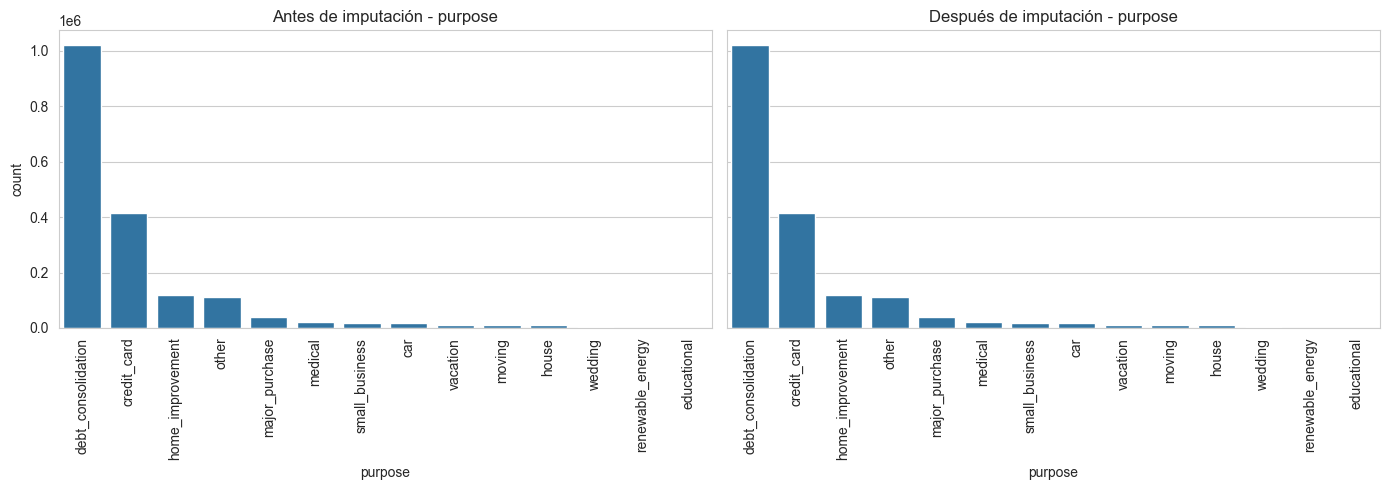

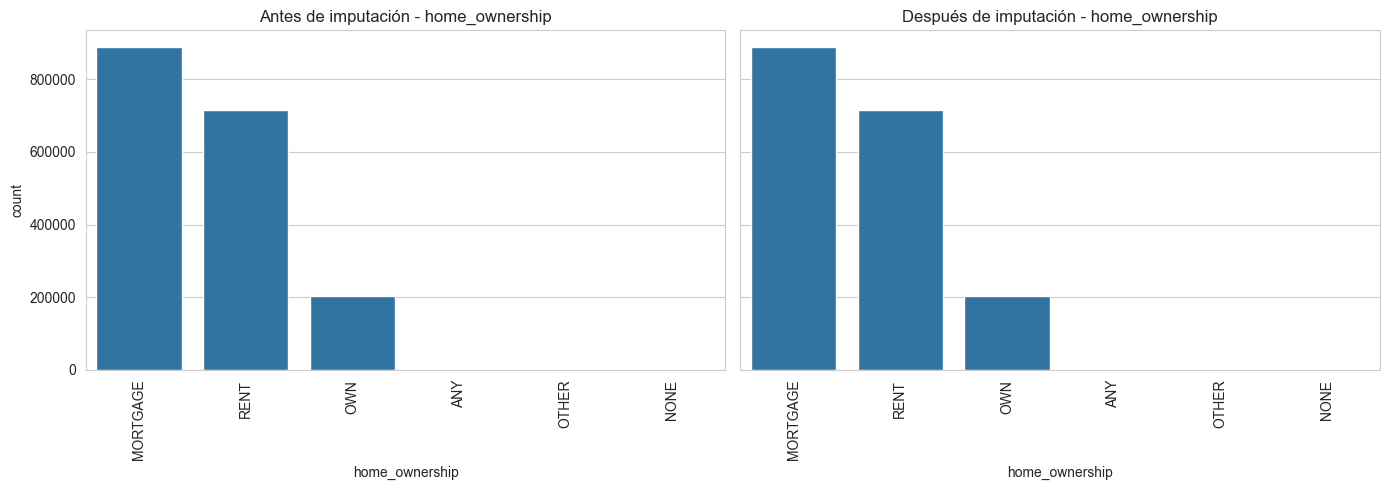

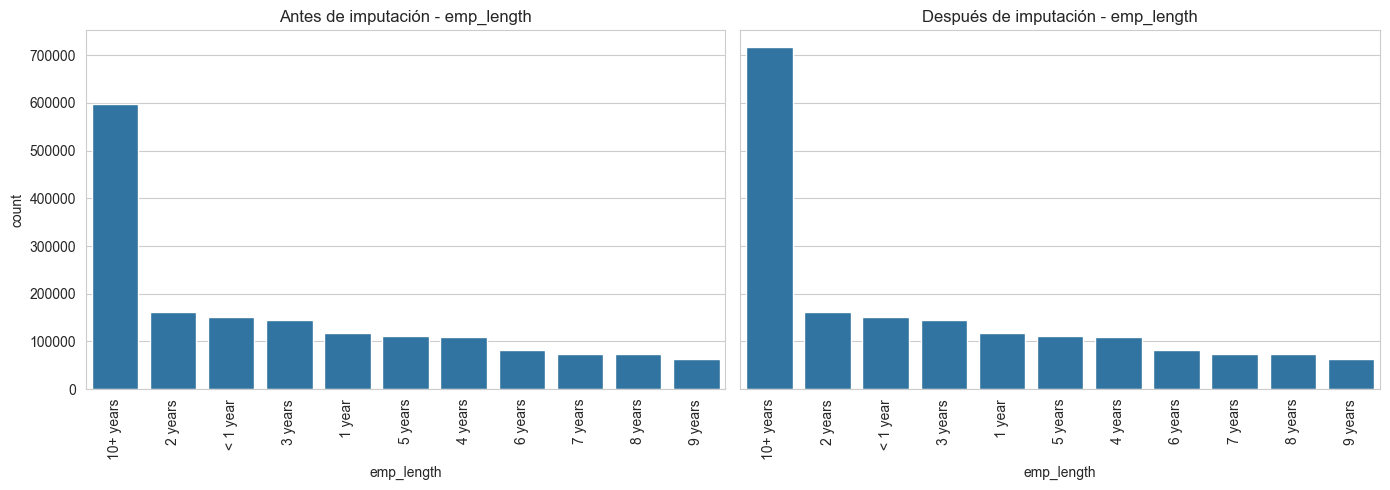

In [64]:
# Copia de las variables categóricas después de la imputación
after_train_cat = X_train[imp_moda].copy()
after_test_cat  = X_test[imp_moda].copy()

# Comparación antes vs después de imputar
for col in imp_moda:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # Antes de imputar
    sns.countplot(
        x=before_train_cat[col],
        ax=axes[0],
        order=before_train_cat[col].value_counts().index
    )
    axes[0].set_title(f"Antes de imputación - {col}")
    axes[0].tick_params(axis='x', rotation=90)

    # Después de imputar
    sns.countplot(
        x=after_train_cat[col],
        ax=axes[1],
        order=after_train_cat[col].value_counts().index
    )
    axes[1].set_title(f"Después de imputación - {col}")
    axes[1].tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()


## Codificacion de categoricas 

In [65]:
cat_oh=X_train.select_dtypes(include="object").columns.tolist()

In [66]:
encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
train_encoded = encoder.fit_transform(X_train[cat_oh])
test_encoded  = encoder.transform(X_test[cat_oh])

In [67]:
encoded_cols = encoder.get_feature_names_out(cat_oh)

train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_cols, index=X_train.index)
test_encoded_df  = pd.DataFrame(test_encoded,  columns=encoded_cols, index=X_test.index)

In [68]:
X_train = pd.concat([X_train.drop(columns=cat_oh), train_encoded_df], axis=1)
X_test  = pd.concat([X_test.drop(columns=cat_oh),  test_encoded_df],  axis=1)

## Escalado de numericas

Realizamos el escalado de numericas 

In [69]:
num_scale=X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [70]:
scaler = StandardScaler()
X_train[num_scale] = scaler.fit_transform(X_train[num_scale])
X_test[num_scale]  = scaler.transform(X_test[num_scale])

In [71]:
# Unir X con y antes de exportar
train_df = X_train.copy()
train_df["label"] = y_train

test_df = X_test.copy()
test_df["label"] = y_test

# Exportar en formato Parquet (recomendado)
train_df.to_parquet("train.parquet", index=False, engine="fastparquet")
test_df.to_parquet("test.parquet", index=False, engine="fastparquet")

# Modelo y evaluacion de tiempo de ejecucion

In [72]:
rf = RandomForestClassifier(random_state=0,class_weight='balanced')

In [73]:
param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [5, 10, 15]
}

In [74]:
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="roc_auc",  
    cv=5
)

In [75]:
start_train = time.time()
grid.fit(X_train, y_train)
end_train = time.time()

In [76]:
print("Tiempo de entrenamiento:", round(end_train - start_train, 3), "segundos")

Tiempo de entrenamiento: 4080.925 segundos


In [77]:
best_model = grid.best_estimator_

In [78]:
start_pred = time.time()
y_pred = best_model.predict(X_test)
end_pred = time.time()

In [79]:
print("Tiempo de predicción:", round(end_pred - start_pred, 6), "segundos")
print("\nMejores hiperparámetros:", grid.best_params_)

Tiempo de predicción: 7.301115 segundos

Mejores hiperparámetros: {'max_depth': 15, 'n_estimators': 100}


# Evaluacion de metricas 

In [80]:
y_proba = best_model.predict_proba(X_test)[:, 1]

In [81]:
metrics_dict = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_proba)
}
metrics_df = pd.DataFrame(metrics_dict, index=["RandomForest (Best GridSearch)"])
print("\nMétricas del modelo:\n")
print(metrics_df)


Métricas del modelo:

                                Accuracy  Precision    Recall  F1-score  \
RandomForest (Best GridSearch)  0.634676   0.196351  0.670967  0.303798   

                                 ROC AUC  
RandomForest (Best GridSearch)  0.706397  


In [82]:
cm = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusión:\n", cm)


Matriz de confusión:
 [[250924 147505]
 [ 17673  36039]]


In [83]:
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))


Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.93      0.63      0.75    398429
           1       0.20      0.67      0.30     53712

    accuracy                           0.63    452141
   macro avg       0.57      0.65      0.53    452141
weighted avg       0.85      0.63      0.70    452141



In [84]:
# Obtener importancias
importances = best_model.feature_importances_

# Crear DataFrame ordenado
feat_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_importances.head(20))

                       feature  importance
1                     int_rate    0.405824
2              fico_range_high    0.131321
4                          dti    0.054764
90              term_60 months    0.052853
3                   annual_inc    0.051689
5                   revol_util    0.048549
0                    loan_amnt    0.046459
10       mths_since_recent_inq    0.038639
6                     open_acc    0.023316
35     home_ownership_MORTGAGE    0.017767
39         home_ownership_RENT    0.015461
22         purpose_credit_card    0.010406
7                  delinq_2yrs    0.008178
23  purpose_debt_consolidation    0.006756
9         pub_rec_bankruptcies    0.005459
32      purpose_small_business    0.003934
12        emp_length_10+ years    0.003836
38          home_ownership_OWN    0.002528
21         emp_length_< 1 year    0.002296
43               addr_state_CA    0.002207


<Figure size 1000x600 with 0 Axes>

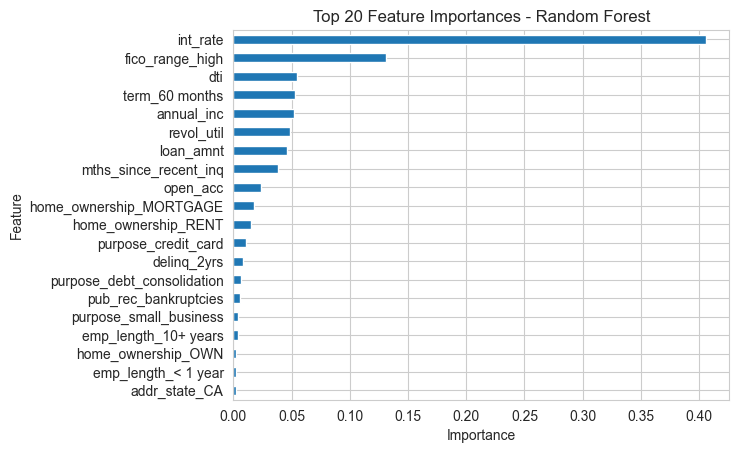

In [85]:
plt.figure(figsize=(10,6))
feat_importances.head(20).plot(kind="barh", x="feature", y="importance", legend=False)
plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()  # Para que el más importante quede arriba
plt.show()

# Spark

In [86]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
import time


In [87]:
import os
print(os.environ["JAVA_HOME"])

C:\Program Files\Java\jdk-21


In [88]:
import os
import sys

# Usar el Python actual de conda
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

In [89]:
import pyspark
print(pyspark.__version__)

4.0.1


In [90]:
import sys

print("Python:", sys.version)
print("PySpark:", pyspark.__version__)

Python: 3.9.23 (main, Jun  5 2025, 13:25:08) [MSC v.1929 64 bit (AMD64)]
PySpark: 4.0.1


In [91]:
spark = (
    SparkSession.builder
    .master("local[*]")   # usa todos los núcleos disponibles
    .appName("RandomForestGridSearch")
    .config("spark.driver.memory", "13g")
    .config("spark.executor.memory", "13g")
    .getOrCreate()
)

In [92]:
train_spark = spark.read.parquet("train.parquet")
test_spark = spark.read.parquet("test.parquet")

In [93]:
feature_cols = [col for col in train_spark.columns if col != "label"]
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="final_features"
)

# Transformar los datasets
train_spark = assembler.transform(train_spark)
test_spark = assembler.transform(test_spark)

In [94]:
rf = RandomForestClassifier(labelCol="label", featuresCol="final_features", seed = 0)

In [95]:
paramGrid = (ParamGridBuilder()
             .addGrid(rf.numTrees, [10, 50, 100])
             .addGrid(rf.maxDepth, [5, 10, 15])
             .build())

In [96]:
evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"   # equivalente a roc_auc_score
)

In [97]:
crossval = CrossValidator(estimator=rf,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=5)

In [98]:
start_train = time.time()
cvModel = crossval.fit(train_spark)
end_train = time.time()
print("Tiempo de entrenamiento:", round(end_train - start_train, 3), "segundos")

Tiempo de entrenamiento: 22136.507 segundos


In [99]:
best_model = cvModel.bestModel
print("\nMejores hiperparámetros:")
print("  numTrees:", best_model.getNumTrees)
print("  maxDepth:", best_model.getOrDefault("maxDepth"))


Mejores hiperparámetros:
  numTrees: 100
  maxDepth: 15


In [100]:
start_pred = time.time()
predictions = best_model.transform(test_spark)
end_pred = time.time()
print("Tiempo de predicción:", round(end_pred - start_pred, 6), "segundos")

Tiempo de predicción: 0.06073 segundos


In [101]:
# ROC AUC
roc_auc = evaluator.evaluate(predictions)
print("ROC AUC:", roc_auc)

ROC AUC: 0.7008690724410455


In [102]:
# Otras métricas
multi_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

In [103]:
accuracy = multi_eval.evaluate(predictions, {multi_eval.metricName: "accuracy"})
f1 = multi_eval.evaluate(predictions, {multi_eval.metricName: "f1"})
precision = multi_eval.evaluate(predictions, {multi_eval.metricName: "precisionByLabel"})
recall = multi_eval.evaluate(predictions, {multi_eval.metricName: "recallByLabel"})

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8812051992630617
Precision: 0.8812051992630617
Recall: 1.0
F1-score: 0.825558640293409


In [104]:
print("\nMatriz de confusión:")
predictions.groupBy("label", "prediction").count().show()


Matriz de confusión:
+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|    1|       0.0| 53712|
|    0|       0.0|398429|
+-----+----------+------+

